# Adaptive Kernel Feature Learning for Tabular Data

**Author:** Zhihao Wu

### xRFM · Tabular Model Comparison · Interpretability · Scaling · Residual-Weighted AGOP

> **Project focus:** supervised learning on tabular data  
> **Main method:** xRFM, an adaptive kernel-based model with tree-structured feature learning  
> **Baselines:** XGBoost and Random Forest  
> **Main analysis:** prediction performance, runtime cost, interpretability behaviour, scaling behaviour, and an AGOP-based method extension

---

## Project Overview

In this project, I build a complete tabular machine learning workflow to evaluate **xRFM** across different supervised learning settings.

I use xRFM to study adaptive kernel feature learning on tabular data, where different regions of a dataset may benefit from different learned feature patterns.

Tabular data is still a challenging setting for machine learning. A single workflow often needs to handle:

- numerical and categorical features
- missing values
- different feature scales
- regression and classification targets
- dataset-specific structure

Because strong tree-based models are highly competitive on tabular data, I compare xRFM with **XGBoost** and **Random Forest** as practical baselines.

The project focuses on more than prediction accuracy. I also study:

- **runtime cost**
- **feature interpretability**
- **scaling behaviour**
- **local feature-learning patterns**
- **residual-weighted AGOP as an exploratory method extension**

---

## Project Objectives

I designed this notebook as an end-to-end model comparison and analysis pipeline.

The main objectives are:

1. Load and preprocess multiple tabular datasets with different task types and feature structures.
2. Train and tune **xRFM**, **XGBoost**, and **Random Forest** under the same train-validation-test setup.
3. Select model configurations using validation performance and reserve the test set for final reporting.
4. Compare predictive performance and runtime cost using task-specific metrics.
5. Analyse xRFM feature behaviour through leaf-level diagonal feature scores.
6. Compare xRFM diagonal rankings with PCA loading-based importance, mutual information, and permutation importance.
7. Study scaling behaviour by changing the training size on a large classification dataset.
8. Implement a residual-weighted AGOP extension to check whether high-error samples can guide a more targeted feature-importance signal.

---

## Dataset Coverage

I use **5 tabular datasets** in the main comparison:

| Dataset | Task Type | Main Role |
|---|---:|---|
| **Adult Income** | Classification | Large mixed-feature dataset for scaling analysis |
| **Bank Marketing** | Classification | Binary classification dataset with class imbalance |
| **Ames Housing** | Regression | High-dimensional mixed-feature dataset for interpretability analysis |
| **Superconductivity** | Regression | Large high-dimensional numerical regression dataset |
| **Bike Sharing** | Regression | Medium-large mixed-feature regression dataset |

Together, these datasets cover:

- **2 classification datasets**
- **3 regression datasets**
- large-sample settings
- high-dimensional feature settings
- mixed numerical-categorical feature types

---

## Models and Methods

### xRFM

xRFM is the main model studied in this project. I use it to examine adaptive kernel feature learning on tabular data and to inspect feature-importance behaviour through diagonal matrix-based scores.

### XGBoost

XGBoost is used as a strong tree-based baseline. It is a useful comparison point because gradient-boosted trees often perform well on tabular datasets.

### Random Forest

Random Forest is used as an additional tree-based baseline. It gives a second comparison method with a different training style from XGBoost.

---

## Evaluation Strategy

Each dataset is split into:

- training set
- validation set
- test set

The evaluation rule is:

> **Validation set → model selection**  
> **Test set → final reporting**

For regression tasks, I record:

- **RMSE**
- **training time**
- **inference time per sample**

For classification tasks, I record:

- **Accuracy**
- **AUC-ROC**
- **training time**
- **inference time per sample**

The main comparison covers **5 datasets × 3 model families**, producing **15 selected-model result rows**.

---

## Interpretability Analysis

I use **Ames Housing** as the interpretability dataset because it contains rich and meaningful tabular features.

The interpretability workflow is:

1. Retrieve the validation-selected xRFM model.
2. Inspect the fitted model for usable leaf-level feature matrices.
3. Use fallback M diagonal vectors when direct AGOP matrices are not available.
4. Convert diagonal values into feature-level activity scores.
5. Keep local leaf-level rankings for closer inspection.
6. Aggregate scores across detected leaves into a global xRFM diagonal feature-activity ranking.

I compare the xRFM diagonal ranking with **3 baseline importance methods**:

- PCA loading-based importance
- mutual information
- permutation importance

Together with the xRFM diagonal ranking, this gives **4 interpretability views** for cross-method comparison.

I compare these methods using:

- feature ranks
- top-k overlap
- consensus features
- high-disagreement features

---

## Scaling Analysis

I use **Adult Income** as the large classification dataset for the scaling analysis.

The scaling setup keeps the same raw validation and test splits while increasing the training size. For each sampled training subset, I fit a fresh preprocessor on the sampled training data and apply the fitted transformation to the validation and test splits.

I compare the same **3 model families**:

- xRFM
- XGBoost
- Random Forest

For each model, I reuse the validation-selected best parameters from the main comparison instead of tuning again at every subset size. This keeps the scaling analysis focused on the effect of training size.

I plot:

- test Accuracy vs training size
- test AUC-ROC vs training size
- training time vs training size

These outputs show how model quality and runtime cost change as more training data becomes available.

---

## Verification Checks

I add verification checks to make sure the final notebook still matches the intended project setup.

The checks cover:

- dataset catalog coverage
- dataset loader status
- preprocessed data availability
- in-memory and saved result sources
- removal of earlier draft dataset keys
- interpretability dataset choice
- scaling dataset choice

The two special analysis choices are:

| Analysis | Dataset |
|---|---|
| Interpretability analysis | **Ames Housing** |
| Scaling analysis | **Adult Income** |

---

## Residual-Weighted AGOP Extension

I also implement a residual-weighted AGOP method extension on synthetic regression data.

The synthetic setup has **2 feature roles**:

- `X0` captures the main global trend
- `X1` becomes important mainly in a local high-error region

I compute **2 AGOP variants**:

- standard AGOP
- residual-weighted AGOP

The residual-weighted version gives more influence to high-error samples. As a practical check, I focus on high-residual samples and compare the RMSE reduction from a one-split regression tree using the top feature selected by each AGOP variant.

This extension gives me a small exploratory check of whether AGOP-style information can be adjusted toward regions where the model still makes larger errors.

---

## Notebook Structure

This notebook follows a complete project workflow:

1. **Environment setup**
2. **Global configuration**
3. **Data loading**
4. **Preprocessing**
5. **Model training and tuning**
6. **Evaluation and result tables**
7. **Interpretability analysis**
8. **Scaling analysis**
9. **Verification checks**
10. **Residual-weighted AGOP extension**
11. **Project packaging**

---

## Key Outputs

The project produces:

- cleaned model comparison result tables
- regression and classification comparison tables
- selected model-parameter records
- dataset-level best-model summaries
- runtime comparison records
- xRFM interpretability tables
- cross-method feature-importance comparison tables
- scaling summary tables and curves
- residual-weighted AGOP extension outputs
- verification checks for dataset and result consistency
- packaged project files for later review

---

## Project Value

This project shows a complete tabular machine learning workflow from data preparation to model analysis.

It connects:

- **prediction performance**
- **runtime efficiency**
- **feature interpretation**
- **scaling behaviour**
- **method-level experimentation**

I keep the main outputs as tables, figures, and saved files so I can inspect the results, rerun key steps, and extend the workflow later.

## Part 1. Environment Setup

### Mount Google Drive and Set the Project Folder

I start by mounting Google Drive and setting one project folder for the notebook.

This gives me a consistent place to keep:

- datasets
- intermediate files
- generated outputs

For this run, I keep the folder path explicit so the later cells can reuse the same project root.

In [ ]:
from google.colab import drive
import os

# I mount Google Drive so the project files can be reused across Colab sessions.
drive.mount('/content/drive')

# I keep one main folder for the project files.
project_root = '/content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data'

# I create the folder if it has not been created yet.
os.makedirs(project_root, exist_ok=True)

# I confirm that the project folder is available before moving on.
print("Google Drive mounted successfully.")
print(f"Project folder: {project_root}")
print("Folder exists:", os.path.exists(project_root))

Mounted at /content/drive
Google Drive mounted successfully.
Project folder: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data
Folder exists: True


### Install Required Packages

I install the core libraries needed for the modelling workflow:

- data loading and preprocessing
- model training
- evaluation
- visualisation

This keeps the environment ready before I start building and comparing the tabular models.

In [ ]:
# I install the libraries used across the tabular modelling pipeline.
!pip -q install xrfm xgboost lightgbm "scikit-learn>=1.2,<1.9" pandas numpy matplotlib seaborn ucimlrepo

# I check that the installation step has finished.
print("Package installation finished successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 5.5 MB/s eta 0:00:00
Package installation finished successfully.


### Check Scikit-learn Version

I check the scikit-learn version in the current runtime before importing the main machine learning tools.

This is a small sanity check for the environment, especially because some preprocessing and modelling APIs can behave slightly differently across versions.

In [ ]:
# I inspect the scikit-learn version available in the current runtime.
import sklearn

# I print the version as a quick environment check.
print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.6.1


### Import Core Libraries

I import the core libraries used across the notebook.

The setup covers:

- data handling
- preprocessing
- model training
- evaluation
- feature analysis
- basic runtime checks

I also print the active Python and platform information so I can quickly confirm the runtime environment for the current run.

In [ ]:
# I import utilities for file paths, timing, randomness control, and environment checks.
import os
import sys
import time
import random
import warnings
import platform

# I import the main packages for data handling and plotting.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# I import the preprocessing, modelling, evaluation, and feature analysis tools used later.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# I import boosted-tree libraries for baseline comparisons.
import xgboost as xgb
import lightgbm as lgb

# I keep non-critical warnings out of the notebook output.
warnings.filterwarnings("ignore")

# I check that the core imports and runtime information are available.
print("All core packages imported successfully.")
print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())

All core packages imported successfully.
Python version: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35


### Set Reproducibility and Folder Paths

I set a shared random seed and prepare the main folders used by the notebook.

The folder structure keeps the workflow tidy:

- `data` → raw or prepared datasets
- `results` → evaluation tables and saved outputs
- `figures` → generated plots
- `saved_models` → fitted model files

The seed helps make repeated runs more stable, while the folder paths keep later cells easier to manage.

In [ ]:
# I use one shared seed to make random operations more consistent across runs.
SEED = 42

# I apply the seed to Python's random module and NumPy.
random.seed(SEED)
np.random.seed(SEED)

# I define the main folders used throughout the project.
DATA_DIR = os.path.join(project_root, "data")
RESULTS_DIR = os.path.join(project_root, "results")
FIGURES_DIR = os.path.join(project_root, "figures")
MODELS_DIR = os.path.join(project_root, "saved_models")

# I create the folders if they are not already available.
for folder in [DATA_DIR, RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    os.makedirs(folder, exist_ok=True)

# I print the paths so I can quickly check the current workspace.
print("Random seed set:", SEED)
print("Project subfolders are ready:")
print("DATA_DIR   =", DATA_DIR)
print("RESULTS_DIR=", RESULTS_DIR)
print("FIGURES_DIR=", FIGURES_DIR)
print("MODELS_DIR =", MODELS_DIR)

Random seed set: 42
Project subfolders are ready:
DATA_DIR   = /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/data
RESULTS_DIR= /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/results
FIGURES_DIR= /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/figures
MODELS_DIR = /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/saved_models


### Check Environment Details

I collect the main runtime settings in one compact table before moving into the modelling workflow.

The table records:

- project and output paths
- the shared random seed
- key package versions used in the current runtime

This gives me a lightweight environment snapshot without hard-coding version details into the notebook text.

In [ ]:
# I import these namespaces so I can record their active versions.
import sklearn
import xgboost
import lightgbm

# I collect the main runtime settings and package versions in one table.
env_info = pd.DataFrame({
    "Item": [
        "Project Root",
        "Data Folder",
        "Results Folder",
        "Figures Folder",
        "Seed",
        "NumPy Version",
        "Pandas Version",
        "Scikit-learn Version",
        "XGBoost Version",
        "LightGBM Version"
    ],
    "Value": [
        project_root,
        DATA_DIR,
        RESULTS_DIR,
        FIGURES_DIR,
        SEED,
        np.__version__,
        pd.__version__,
        sklearn.__version__,
        xgboost.__version__,
        lightgbm.__version__
    ]
})

# I display the setup table as a quick runtime check.
display(env_info)

# I mark the environment setup step as complete.
print("Environment setup is complete.")

,Item,Value
0,Project Root,/content/drive/MyDrive/Adaptive_Kernel_Feature...
1,Data Folder,/content/drive/MyDrive/Adaptive_Kernel_Feature...
2,Results Folder,/content/drive/MyDrive/Adaptive_Kernel_Feature...
3,Figures Folder,/content/drive/MyDrive/Adaptive_Kernel_Feature...
4,Seed,42
5,NumPy Version,2.0.2
6,Pandas Version,2.2.2
7,Scikit-learn Version,1.6.1
8,XGBoost Version,3.2.0
9,LightGBM Version,4.6.0


Environment setup is complete.


### Part 1 Summary: Environment Setup

In Part 1, I prepared the notebook environment and checked that the basic workspace was ready before modelling.

I completed **6 setup steps**:

- mounted Google Drive
- created the main project folder
- installed the required packages
- imported the core libraries
- set one shared random seed
- prepared **4 project folders** for data, results, figures, and saved models

I also created one environment table to record the active paths, seed setting, and package versions for the current runtime. This gives me a compact setup check without hard-coding version details into the written notes.

## Part 2. Global Configuration

### Define Project Configuration

I keep the main experiment settings in one configuration table before building the modelling pipeline.

This table gives me a single checkpoint for:

- model family and baseline models
- dataset coverage
- train / validation / test setup
- timing records
- interpretability and scaling analysis

By keeping these settings together, I can check the experiment design before running the full workflow.

In [ ]:
# I import display here so this configuration cell can run on its own if needed.
from IPython.display import display
import pandas as pd

# I collect the main experiment settings in one dictionary for later checks.
PROJECT_CONFIG = {
    "project_name": "Adaptive Kernel Feature Learning for Tabular Data",
    "official_model_required": "xRFM",
    "tree_baseline_required": "XGBoost",
    "extra_baseline_required": "RandomForest",
    "min_num_datasets": 5,
    "min_regression_datasets": 2,
    "min_classification_datasets": 2,
    "need_large_n_dataset": True,
    "large_n_threshold": 10000,
    "need_high_d_dataset": True,
    "high_d_threshold": 50,
    "need_mixed_type_dataset": True,
    "tune_on_validation_only": True,
    "report_on_test_only": True,
    "fix_random_seed": True,
    "report_training_time": True,
    "report_inference_time_per_sample": True,
    "interpretability_experiment_required": True,
    "scaling_experiment_required": True
}

# I convert the configuration dictionary into a readable table.
requirements_df = pd.DataFrame(
    [{"Config Item": k, "Value": v} for k, v in PROJECT_CONFIG.items()]
)

# I display the configuration table before running the main experiments.
display(requirements_df)
print("Global configuration created successfully.")

,Config Item,Value
0,project_name,Adaptive Kernel Feature Learning for Tabular Data
1,official_model_required,xRFM
2,tree_baseline_required,XGBoost
3,extra_baseline_required,RandomForest
4,min_num_datasets,5
5,min_regression_datasets,2
6,min_classification_datasets,2
7,need_large_n_dataset,True
8,large_n_threshold,10000
9,need_high_d_dataset,True


Global configuration created successfully.


### Create Dataset Planning Template

I create a dataset planning table before loading the actual data.

At this stage, the table works as a simple checklist for the experiment design:

- 5 planned datasets
- regression and classification coverage
- mixed feature type tracking
- main evaluation, interpretability, and scaling roles

The placeholder fields will be checked again once the real datasets are loaded and summarised.

In [ ]:
# I create a planning table for the datasets I will compare in this project.
DATASET_PLAN = pd.DataFrame([
    {
        "dataset_id": "DS1",
        "dataset_name": "TBD",
        "task_type": "regression",
        "source": "TBD",
        "n_samples": None,
        "n_features": None,
        "mixed_feature_types": None,
        "use_for_main_table": True,
        "use_for_interpretability": False,
        "use_for_scaling": False,
        "status": "to_be_selected"
    },
    {
        "dataset_id": "DS2",
        "dataset_name": "TBD",
        "task_type": "regression",
        "source": "TBD",
        "n_samples": None,
        "n_features": None,
        "mixed_feature_types": None,
        "use_for_main_table": True,
        "use_for_interpretability": False,
        "use_for_scaling": False,
        "status": "to_be_selected"
    },
    {
        "dataset_id": "DS3",
        "dataset_name": "TBD",
        "task_type": "classification",
        "source": "TBD",
        "n_samples": None,
        "n_features": None,
        "mixed_feature_types": None,
        "use_for_main_table": True,
        "use_for_interpretability": True,
        "use_for_scaling": False,
        "status": "to_be_selected"
    },
    {
        "dataset_id": "DS4",
        "dataset_name": "TBD",
        "task_type": "classification",
        "source": "TBD",
        "n_samples": None,
        "n_features": None,
        "mixed_feature_types": None,
        "use_for_main_table": True,
        "use_for_interpretability": False,
        "use_for_scaling": True,
        "status": "to_be_selected"
    },
    {
        "dataset_id": "DS5",
        "dataset_name": "TBD",
        "task_type": "classification_or_regression",
        "source": "TBD",
        "n_samples": None,
        "n_features": None,
        "mixed_feature_types": None,
        "use_for_main_table": True,
        "use_for_interpretability": False,
        "use_for_scaling": False,
        "status": "to_be_selected"
    }
])

# I display the table so I can review the planned dataset coverage.
display(DATASET_PLAN)

# I check how many datasets are currently included in the plan.
print("Dataset planning table created.")
print("Current planned dataset count:", len(DATASET_PLAN))

,dataset_id,dataset_name,task_type,source,n_samples,n_features,mixed_feature_types,use_for_main_table,use_for_interpretability,use_for_scaling,status
0,DS1,TBD,regression,TBD,None,None,None,True,False,False,to_be_selected
1,DS2,TBD,regression,TBD,None,None,None,True,False,False,to_be_selected
2,DS3,TBD,classification,TBD,None,None,None,True,True,False,to_be_selected
3,DS4,TBD,classification,TBD,None,None,None,True,False,True,to_be_selected
4,DS5,TBD,classification_or_regression,TBD,None,None,None,True,False,False,to_be_selected


Dataset planning table created.
Current planned dataset count: 5


### Define Model Configuration

I define the models used in the main comparison.

The active comparison includes **3 models**:

- **xRFM** → main adaptive kernel-based model
- **XGBoost** → boosted-tree baseline
- **Random Forest** → additional tree-based baseline

I also keep **LightGBM** as an inactive optional model. It is not part of the main comparison in this run, but keeping it in the configuration makes the setup easier to extend later.

In [ ]:
# I define the models used in the main comparison and keep one optional model available.
MODEL_CONFIG = {
    "active_models": ["xrfm", "xgboost", "random_forest"],
    "optional_models": ["lightgbm"],
    "task_support": {
        "xrfm": ["regression", "classification"],
        "xgboost": ["regression", "classification"],
        "random_forest": ["regression", "classification"],
        "lightgbm": ["regression", "classification"]
    },
    "final_baseline_choice": {
        "required_tree_baseline": "xgboost",
        "required_extra_baseline": "random_forest"
    }
}

# I build a table showing the active models and their supported task types.
model_rows = []
for model_name in MODEL_CONFIG["active_models"]:
    model_rows.append({
        "model_name": model_name,
        "active": True,
        "supports_regression": "regression" in MODEL_CONFIG["task_support"][model_name],
        "supports_classification": "classification" in MODEL_CONFIG["task_support"][model_name]
    })

# I keep optional models visible but inactive in the main comparison.
for model_name in MODEL_CONFIG["optional_models"]:
    model_rows.append({
        "model_name": model_name,
        "active": False,
        "supports_regression": "regression" in MODEL_CONFIG["task_support"][model_name],
        "supports_classification": "classification" in MODEL_CONFIG["task_support"][model_name]
    })

# I convert the model setup into a readable table.
model_config_df = pd.DataFrame(model_rows)

# I display the model table and check the active model list.
display(model_config_df)
print("Model configuration created successfully.")
print("Active models:", MODEL_CONFIG["active_models"])

,model_name,active,supports_regression,supports_classification
0,xrfm,True,True,True
1,xgboost,True,True,True
2,random_forest,True,True,True
3,lightgbm,False,True,True


Model configuration created successfully.
Active models: ['xrfm', 'xgboost', 'random_forest']


### Set Data Split and Metrics

I define a consistent split setup and evaluation metrics before running the models.

The setup uses:

- **60/20/20** train, validation, and test split
- stratified splitting for classification tasks
- **1 regression metric**: RMSE
- **2 classification metrics**: accuracy and AUC-ROC
- **2 runtime records**: training time and inference time per sample

This keeps the model comparison focused on both predictive performance and computational cost.

In [ ]:
# I set one shared split rule for the datasets used in this project.
SPLIT_CONFIG = {
    "train_ratio": 0.60,
    "val_ratio": 0.20,
    "test_ratio": 0.20,
    "use_stratify_for_classification": True,
    "random_seed": SEED
}

# I record the evaluation metrics and runtime measurements.
METRIC_CONFIG = {
    "regression_metrics": ["rmse"],
    "classification_metrics": ["accuracy", "auc_roc"],
    "record_training_time": True,
    "record_inference_time_per_sample": True
}

# I combine the split and metric settings into one small table.
split_metric_df = pd.DataFrame([
    {"Category": "Split", "Key": k, "Value": v} for k, v in SPLIT_CONFIG.items()
] + [
    {"Category": "Metric", "Key": k, "Value": str(v)} for k, v in METRIC_CONFIG.items()
])

# I display the table so I can review the evaluation setup.
display(split_metric_df)

# I check that the split ratios form a complete partition.
ratio_sum = SPLIT_CONFIG["train_ratio"] + SPLIT_CONFIG["val_ratio"] + SPLIT_CONFIG["test_ratio"]
print("Split and metric configuration created successfully.")
print("Split ratio sum =", ratio_sum)

,Category,Key,Value
0,Split,train_ratio,0.6
1,Split,val_ratio,0.2
2,Split,test_ratio,0.2
3,Split,use_stratify_for_classification,True
4,Split,random_seed,42
5,Metric,regression_metrics,['rmse']
6,Metric,classification_metrics,"['accuracy', 'auc_roc']"
7,Metric,record_training_time,True
8,Metric,record_inference_time_per_sample,True


Split and metric configuration created successfully.
Split ratio sum = 1.0


### Configure Analysis and Output Settings

I define the extra analysis and output settings used after the main model comparison.

This configuration covers:

- **4 feature-analysis methods** for interpretability
- **5 training-size checkpoints** for scaling behaviour
- **4 output-saving options** for results, figures, tuned parameters, and summaries

I keep the interpretability and scaling datasets as dataset IDs here, then connect them to the actual loaded datasets later in the workflow.

In [ ]:
# I define the extra analysis settings and output-saving options.
SPECIAL_EXPERIMENT_CONFIG = {
    "interpretability_experiment": {
        "enabled": True,
        "methods_to_compare": [
            "xrfm_agop_diagonal",
            "pca_loadings",
            "mutual_information",
            "permutation_importance"
        ],
        "dataset_id": "DS3"
    },
    "scaling_experiment": {
        "enabled": True,
        "dataset_id": "DS4",
        "train_size_grid": [500, 1000, 2000, 5000, 10000],
        "plot_performance_vs_n": True,
        "plot_training_time_vs_n": True
    },
    "save_policy": {
        "save_results_csv": True,
        "save_figures_png": True,
        "save_best_params_csv": True,
        "save_summary_json": True
    }
}

# I flatten the analysis settings into rows for easier display.
special_rows = []

# I record each feature-analysis method used for interpretability.
for method_name in SPECIAL_EXPERIMENT_CONFIG["interpretability_experiment"]["methods_to_compare"]:
    special_rows.append({
        "section": "interpretability",
        "item": method_name,
        "enabled": True
    })

# I record the training sizes used for the scaling analysis.
for n in SPECIAL_EXPERIMENT_CONFIG["scaling_experiment"]["train_size_grid"]:
    special_rows.append({
        "section": "scaling_train_size_grid",
        "item": n,
        "enabled": True
    })

# I record the output types that should be saved.
for save_item, flag in SPECIAL_EXPERIMENT_CONFIG["save_policy"].items():
    special_rows.append({
        "section": "save_policy",
        "item": save_item,
        "enabled": flag
    })

# I convert the settings into a readable table.
special_config_df = pd.DataFrame(special_rows)

# I display the analysis settings and check the selected dataset IDs.
display(special_config_df)
print("Analysis and output settings created successfully.")
print("Interpretability dataset ID:", SPECIAL_EXPERIMENT_CONFIG["interpretability_experiment"]["dataset_id"])
print("Scaling dataset ID:", SPECIAL_EXPERIMENT_CONFIG["scaling_experiment"]["dataset_id"])

,section,item,enabled
0,interpretability,xrfm_agop_diagonal,True
1,interpretability,pca_loadings,True
2,interpretability,mutual_information,True
3,interpretability,permutation_importance,True
4,scaling_train_size_grid,500,True
5,scaling_train_size_grid,1000,True
6,scaling_train_size_grid,2000,True
7,scaling_train_size_grid,5000,True
8,scaling_train_size_grid,10000,True
9,save_policy,save_results_csv,True


Analysis and output settings created successfully.
Interpretability dataset ID: DS3
Scaling dataset ID: DS4


### Part 2 Summary: Global Configuration

In Part 2, I set up the global configuration for the modelling workflow.

I defined the main experiment structure:

- **3 active models**: xRFM, XGBoost, and Random Forest
- **1 optional model**: LightGBM
- **5 planned dataset slots** for regression, classification, and broader tabular-data coverage
- **60/20/20 split** for training, validation, and testing
- **1 regression metric**: RMSE
- **2 classification metrics**: accuracy and AUC-ROC
- **2 runtime measures**: training time and inference time per sample

I also configured two follow-up analysis workflows:

- **Interpretability analysis** → 4 feature-level comparison methods
- **Scaling analysis** → 5 training-size checkpoints

Finally, I set **4 output-saving options** for result tables, figures, selected parameters, and summary files. These settings give the later experiments a clear structure while keeping the actual dataset details and results tied to the loaded data and current run.

## Part 3. Data Loading

### Build Dataset Catalog

I define the tabular datasets before loading the raw data.

The catalog gives me an overview of the dataset mix:

- **5 datasets** in total
- **3 regression datasets**
- **2 classification datasets**
- large-sample, high-dimensional, and mixed-feature cases included
- separate roles for main evaluation, interpretability, and scaling analysis

For each dataset, I record the task type, source, target column, feature structure, and selection reason. This makes the loading stage easier to check before I move into the dataset-specific functions.

In [ ]:
# I create a raw-data folder to keep downloaded files separate from processed data.
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
os.makedirs(RAW_DATA_DIR, exist_ok=True)

# I define the dataset catalog with each dataset's task type and selection reason.
DATASET_CATALOG = pd.DataFrame([
    {
        "dataset_key": "adult_income",
        "dataset_name": "Adult (Census Income)",
        "source": "UCI",
        "task_type": "classification",
        "target_name": "income_class",
        "large_n": True,
        "high_d": False,
        "mixed_feature_types": True,
        "why_selected": "Largest mixed-type classification dataset, used for scaling experiment."
    },
    {
        "dataset_key": "bank_marketing",
        "dataset_name": "Bank Marketing",
        "source": "UCI",
        "task_type": "classification",
        "target_name": "term_deposit_subscription",
        "large_n": True,
        "high_d": False,
        "mixed_feature_types": True,
        "why_selected": "Imbalanced binary classification dataset, useful for Accuracy and AUC-ROC discussion."
    },
    {
        "dataset_key": "ames_housing",
        "dataset_name": "Ames Housing",
        "source": "Github",
        "task_type": "regression",
        "target_name": "sale_price",
        "large_n": False,
        "high_d": True,
        "mixed_feature_types": True,
        "why_selected": "Main dataset for interpretability comparison because features are rich and interpretable."
    },
    {
        "dataset_key": "superconductivity",
        "dataset_name": "Superconductivity",
        "source": "UCI",
        "task_type": "regression",
        "target_name": "critical_temperature",
        "large_n": True,
        "high_d": True,
        "mixed_feature_types": False,
        "why_selected": "Large, high-dimensional, pure numerical regression dataset."
    },
    {
        "dataset_key": "bike_sharing_hour",
        "dataset_name": "Bike Sharing (hour)",
        "source": "UCI",
        "task_type": "regression",
        "target_name": "bike_count",
        "large_n": True,
        "high_d": False,
        "mixed_feature_types": True,
        "why_selected": "Medium-large regression dataset with clear semantics and mixed-type tabular structure."
    }
])

# I summarise the catalog coverage across task types and feature settings.
coverage_summary = pd.DataFrame([
    {"Check": "Total datasets", "Value": len(DATASET_CATALOG)},
    {"Check": "Regression datasets", "Value": int((DATASET_CATALOG["task_type"] == "regression").sum())},
    {"Check": "Classification datasets", "Value": int((DATASET_CATALOG["task_type"] == "classification").sum())},
    {"Check": "Has n > 10000 dataset", "Value": bool(DATASET_CATALOG["large_n"].any())},
    {"Check": "Has d > 50 dataset", "Value": bool(DATASET_CATALOG["high_d"].any())},
    {"Check": "Has mixed-type dataset", "Value": bool(DATASET_CATALOG["mixed_feature_types"].any())}
])

# I display the catalog and coverage summary for a quick review.
display(DATASET_CATALOG)
display(coverage_summary)

# I confirm that the dataset catalog is ready.
print("Dataset catalog created successfully.")

,dataset_key,dataset_name,source,task_type,target_name,large_n,high_d,mixed_feature_types,why_selected
0,adult_income,Adult (Census Income),UCI,classification,income_class,True,False,True,"Largest mixed-type classification dataset, use..."
1,bank_marketing,Bank Marketing,UCI,classification,term_deposit_subscription,True,False,True,"Imbalanced binary classification dataset, usef..."
2,ames_housing,Ames Housing,Github,regression,sale_price,False,True,True,Main dataset for interpretability comparison b...
3,superconductivity,Superconductivity,UCI,regression,critical_temperature,True,True,False,"Large, high-dimensional, pure numerical regres..."
4,bike_sharing_hour,Bike Sharing (hour),UCI,regression,bike_count,True,False,True,Medium-large regression dataset with clear sem...


,Check,Value
0,Total datasets,5
1,Regression datasets,3
2,Classification datasets,2
3,Has n > 10000 dataset,True
4,Has d > 50 dataset,True
5,Has mixed-type dataset,True


Dataset catalog created successfully.


### Import Dataset Fetch Tools

I import the UCI dataset fetching tool and check the dataset catalog by source and task type.

This gives me a quick loading checkpoint:

- how many datasets come from each source
- how many are used for regression or classification
- whether the catalog still matches the planned dataset mix before raw data loading

In [ ]:
# I import the helper used to fetch datasets from the UCI repository.
from ucimlrepo import fetch_ucirepo

# I count the datasets by source and task type.
source_summary = DATASET_CATALOG.groupby(["source", "task_type"]).size().reset_index(name="count")

# I display the source summary before loading the raw datasets.
display(source_summary)

# I print a quick source check for the current catalog.
print("Dataset fetch utilities imported successfully.")
print("UCI datasets in catalog:", int((DATASET_CATALOG["source"] == "UCI").sum()))
print("Github datasets in catalog:", int((DATASET_CATALOG["source"] == "Github").sum()))

,source,task_type,count
0,Github,regression,1
1,UCI,classification,2
2,UCI,regression,2


Dataset fetch utilities imported successfully.
UCI datasets in catalog: 4
Github datasets in catalog: 1


### Standardise Dataset Format

I define helper functions to convert different tabular datasets into one shared format.

The helper workflow handles:

- column-name cleaning
- numerical and categorical feature detection
- question-mark missing values
- missing target removal
- compact metadata collection

Before using the helpers on the real datasets, I run a small toy check with **3 rows** and **3 features**. The output confirms that the helper can separate **2 numerical features** and **1 categorical feature** in the expected format.

In [ ]:
# I clean column names into a consistent format.
def sanitize_column_names(columns):
    clean_cols = []
    for col in columns:
        col = str(col).strip().lower()
        col = col.replace(" ", "_").replace("-", "_").replace("/", "_")
        col = col.replace("(", "").replace(")", "").replace(".", "")
        clean_cols.append(col)
    return clean_cols


# I split features into numerical and categorical groups.
def infer_column_types(X):
    numerical_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = [col for col in X.columns if col not in numerical_cols]
    return numerical_cols, categorical_cols


# I standardise each raw dataset into a shared feature-target-metadata bundle.
def standardize_tabular_output(X, y, dataset_key, dataset_name, task_type, target_name):
    X = X.copy()
    y = pd.Series(y).copy()

    # I clean feature names and assign a consistent target name.
    X.columns = sanitize_column_names(X.columns)
    y.name = target_name

    # I treat question marks as missing values.
    X = X.replace("?", np.nan)

    # I keep regression targets numeric and classification targets as labels.
    if task_type == "regression":
        y = pd.to_numeric(y, errors="coerce")
    else:
        y = y.astype(str)

    # I remove rows without a valid target.
    valid_mask = y.notna()
    X = X.loc[valid_mask].reset_index(drop=True)
    y = y.loc[valid_mask].reset_index(drop=True)

    # I identify feature types for later preprocessing.
    numerical_cols, categorical_cols = infer_column_types(X)

    # I store compact metadata for later checks and summaries.
    metadata = {
        "dataset_key": dataset_key,
        "dataset_name": dataset_name,
        "task_type": task_type,
        "target_name": target_name,
        "n_samples": int(X.shape[0]),
        "n_features": int(X.shape[1]),
        "numerical_cols": numerical_cols,
        "categorical_cols": categorical_cols,
        "n_numerical": len(numerical_cols),
        "n_categorical": len(categorical_cols)
    }

    # I return the cleaned dataset bundle.
    return {
        "X": X,
        "y": y,
        "metadata": metadata
    }


# I create a small toy dataset to check the standardised output format.
toy_X = pd.DataFrame({
    "Age": [21, 35, 42],
    "City": ["Sydney", "Shanghai", "Melbourne"],
    "Score": [88.5, 91.0, 77.5]
})
toy_y = pd.Series([0, 1, 0], name="Label")

# I run the helper once before applying it to the real datasets.
toy_bundle = standardize_tabular_output(
    X=toy_X,
    y=toy_y,
    dataset_key="toy_example",
    dataset_name="Toy Example",
    task_type="classification",
    target_name="label"
)

# I display the toy output and metadata.
display(toy_bundle["X"])
print("Toy metadata summary:")
print(toy_bundle["metadata"])

,age,city,score
0,21,Sydney,88.5
1,35,Shanghai,91.0
2,42,Melbourne,77.5


Toy metadata summary:
{'dataset_key': 'toy_example', 'dataset_name': 'Toy Example', 'task_type': 'classification', 'target_name': 'label', 'n_samples': 3, 'n_features': 3, 'numerical_cols': ['age', 'score'], 'categorical_cols': ['city'], 'n_numerical': 2, 'n_categorical': 1}


### Define UCI Dataset Loaders

I define loader functions for the UCI datasets and pass each raw table through the same standardisation step.

This section prepares **4 UCI datasets**:

- Adult Income
- Bank Marketing
- Superconductivity
- Bike Sharing Hour

Each loader handles the dataset-specific target column first, then returns the same shared bundle format: features, target, and metadata. This keeps the later preprocessing and modelling pipeline consistent across classification and regression tasks.

In [ ]:
# I load the Adult Income dataset and clean its class labels.
def load_adult_income():
    dataset = fetch_ucirepo(id=2)
    X = dataset.data.features.copy()
    y_df = dataset.data.targets.copy()

    # I select the target column safely in case the downloaded table changes slightly.
    if "income" in y_df.columns:
        y = y_df["income"].copy()
    else:
        y = y_df.iloc[:, 0].copy()

    # I clean Adult labels and convert question marks into missing values.
    y = y.astype(str).str.replace('.', '', regex=False).str.strip()
    X = X.replace(to_replace=r'^\s*\?\s*$', value=np.nan, regex=True)

    # I return the dataset in the shared format.
    return standardize_tabular_output(
        X=X,
        y=y,
        dataset_key="adult_income",
        dataset_name="Adult (Census Income)",
        task_type="classification",
        target_name="income_class"
    )


# I load the Bank Marketing dataset as a binary classification task.
def load_bank_marketing():
    dataset = fetch_ucirepo(id=222)
    X = dataset.data.features.copy()
    y = dataset.data.targets.iloc[:, 0].copy()

    # I return the dataset in the shared format.
    return standardize_tabular_output(
        X=X,
        y=y,
        dataset_key="bank_marketing",
        dataset_name="Bank Marketing",
        task_type="classification",
        target_name="term_deposit_subscription"
    )


# I load the Superconductivity dataset as a regression task.
def load_superconductivity():
    dataset = fetch_ucirepo(id=464)
    X = dataset.data.features.copy()
    y = dataset.data.targets.iloc[:, 0].copy()

    # I return the dataset in the shared format.
    return standardize_tabular_output(
        X=X,
        y=y,
        dataset_key="superconductivity",
        dataset_name="Superconductivity",
        task_type="regression",
        target_name="critical_temperature"
    )


# I load the hourly Bike Sharing dataset and use its count target.
def load_bike_sharing_hour():
    dataset = fetch_ucirepo(id=275)
    X = dataset.data.features.copy()
    y_df = dataset.data.targets.copy()

    # I select the standard count target when it is available.
    if "cnt" in y_df.columns:
        y = y_df["cnt"].copy()
    else:
        y = y_df.iloc[:, 0].copy()

    # I return the dataset in the shared format.
    return standardize_tabular_output(
        X=X,
        y=y,
        dataset_key="bike_sharing_hour",
        dataset_name="Bike Sharing (hour)",
        task_type="regression",
        target_name="bike_count"
    )


# I record the UCI loader functions in a small reference table.
uci_loader_table = pd.DataFrame({
    "dataset_key": ["adult_income", "bank_marketing", "superconductivity", "bike_sharing_hour"],
    "loader_function": ["load_adult_income", "load_bank_marketing", "load_superconductivity", "load_bike_sharing_hour"],
    "source": ["UCI", "UCI", "UCI", "UCI"]
})

# I display the loader list for a quick check.
display(uci_loader_table)
print("UCI loader functions defined successfully.")

,dataset_key,loader_function,source
0,adult_income,load_adult_income,UCI
1,bank_marketing,load_bank_marketing,UCI
2,superconductivity,load_superconductivity,UCI
3,bike_sharing_hour,load_bike_sharing_hour,UCI


UCI loader functions defined successfully.


### Define Ames Housing Loader

I define a separate loader for Ames Housing because it is loaded from a GitHub-hosted CSV rather than the UCI fetching utility.

The loader keeps the process simple:

- read the raw CSV from one of two available links
- remove the row identifier
- split features and target
- return the same standardised dataset bundle used by the other loaders

This gives me **1 non-UCI regression dataset** for the shared tabular workflow.

In [ ]:
# I load the Ames Housing dataset from GitHub, with a backup URL if the first link fails.
def load_ames_housing():
    url_1 = "https://raw.githubusercontent.com/eddiexunyc/DATA605_FINAL/main/Resources/train.csv"
    url_2 = "https://raw.githubusercontent.com/chriskhanhtran/kaggle-house-price/master/Data/train.csv"

    try:
        dataset = pd.read_csv(url_1)
    except Exception:
        dataset = pd.read_csv(url_2)

    # I remove the row ID because it is only an identifier.
    if "Id" in dataset.columns:
        dataset = dataset.drop(columns=["Id"])

    # I split the table into input features and the sale price target.
    X = dataset.drop(columns=["SalePrice"]).copy()
    y = dataset["SalePrice"].copy()

    # I return the dataset in the shared regression format.
    return standardize_tabular_output(
        X=X,
        y=y,
        dataset_key="ames_housing",
        dataset_name="Ames Housing",
        task_type="regression",
        target_name="sale_price"
    )


# I record the Ames loader separately because it does not come from UCI.
ames_loader_table = pd.DataFrame({
    "dataset_key": ["ames_housing"],
    "loader_function": ["load_ames_housing"],
    "source": ["Github"]
})

# I display the loader table for a quick source check.
display(ames_loader_table)
print("Ames loader function defined successfully.")

,dataset_key,loader_function,source
0,ames_housing,load_ames_housing,Github


Ames loader function defined successfully.


### Create Unified Dataset Loader

I register all dataset-specific loaders in one shared registry, then define a unified loading function that works from a dataset key.

This gives me one consistent entry point for **5 datasets**:

- Adult Income
- Bank Marketing
- Ames Housing
- Superconductivity
- Bike Sharing Hour

Before loading every dataset, I run a smoke test on Adult Income. The check shows the standardised metadata and a small feature preview, so I can catch loader or formatting issues early.

In [ ]:
# I collect all dataset-specific loader functions in one registry.
LOADER_REGISTRY = {
    "adult_income": load_adult_income,
    "bank_marketing": load_bank_marketing,
    "ames_housing": load_ames_housing,
    "superconductivity": load_superconductivity,
    "bike_sharing_hour": load_bike_sharing_hour
}


# I use one shared loading function so later cells only need a dataset key.
def load_dataset(dataset_key):
    if dataset_key not in LOADER_REGISTRY:
        raise ValueError(f"Unknown dataset_key: {dataset_key}")

    # I call the matching loader and return the standardised bundle.
    bundle = LOADER_REGISTRY[dataset_key]()
    return bundle


# I run a smoke test to check that the registry and one real loader work.
quick_test_bundle = load_dataset("adult_income")

# I summarise the loaded dataset so its shape and feature types are visible.
quick_test_summary = pd.DataFrame([
    {"Field": "dataset_name", "Value": quick_test_bundle["metadata"]["dataset_name"]},
    {"Field": "task_type", "Value": quick_test_bundle["metadata"]["task_type"]},
    {"Field": "n_samples", "Value": quick_test_bundle["metadata"]["n_samples"]},
    {"Field": "n_features", "Value": quick_test_bundle["metadata"]["n_features"]},
    {"Field": "n_numerical", "Value": quick_test_bundle["metadata"]["n_numerical"]},
    {"Field": "n_categorical", "Value": quick_test_bundle["metadata"]["n_categorical"]}
])

# I display the summary and a small feature preview to catch loading issues early.
display(quick_test_summary)
display(quick_test_bundle["X"].head(3))
print("Unified dataset loader is working on the smoke test dataset.")

,Field,Value
0,dataset_name,Adult (Census Income)
1,task_type,classification
2,n_samples,48842
3,n_features,14
4,n_numerical,6
5,n_categorical,8


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States


Unified dataset loader is working on the smoke test dataset.


### Smoke Test All Dataset Loaders

I load each dataset once through the unified loader and record its loading status before preprocessing.

The scan covers **5 planned datasets** and records:

- task type
- sample and feature counts
- numerical and categorical feature split
- loading time
- success or failure status

This gives me an early checkpoint for data access and formatting. If a dataset fails to load, the issue stays visible in the same scan table instead of breaking the rest of the notebook silently.

In [ ]:
# I store one scan record per dataset.
scan_rows = []

# I test every dataset in the catalog before preprocessing.
for dataset_key in DATASET_CATALOG["dataset_key"]:
    start_time = time.time()
    try:
        # I load the dataset through the unified loader.
        bundle = load_dataset(dataset_key)
        elapsed = time.time() - start_time

        # I record the metadata returned by the standardised bundle.
        scan_rows.append({
            "dataset_key": dataset_key,
            "dataset_name": bundle["metadata"]["dataset_name"],
            "task_type": bundle["metadata"]["task_type"],
            "n_samples": bundle["metadata"]["n_samples"],
            "n_features": bundle["metadata"]["n_features"],
            "n_numerical": bundle["metadata"]["n_numerical"],
            "n_categorical": bundle["metadata"]["n_categorical"],
            "load_time_sec": round(elapsed, 3),
            "status": "success"
        })
    except Exception as e:
        elapsed = time.time() - start_time

        # I keep failed loads visible in the same scan table.
        scan_rows.append({
            "dataset_key": dataset_key,
            "dataset_name": None,
            "task_type": None,
            "n_samples": None,
            "n_features": None,
            "n_numerical": None,
            "n_categorical": None,
            "load_time_sec": round(elapsed, 3),
            "status": f"failed: {str(e)}"
        })

# I convert the scan records into a table.
dataset_scan_df = pd.DataFrame(scan_rows)

# I display the loading check and count the successful loads.
display(dataset_scan_df)
print("Dataset loader smoke test finished.")
print("Successful loads:", int((dataset_scan_df["status"] == "success").sum()))

,dataset_key,dataset_name,task_type,n_samples,n_features,n_numerical,n_categorical,load_time_sec,status
0,adult_income,Adult (Census Income),classification,48842,14,6,8,2.742,success
1,bank_marketing,Bank Marketing,classification,45211,16,7,9,2.465,success
2,ames_housing,Ames Housing,regression,1460,79,36,43,0.045,success
3,superconductivity,Superconductivity,regression,21263,81,81,0,6.359,success
4,bike_sharing_hour,Bike Sharing (hour),regression,17379,13,12,1,2.157,success


Dataset loader smoke test finished.
Successful loads: 5


### Save Raw Dataset Files

I save local raw copies after the loader checks.

For each dataset, I write out **3 file types**:

- feature table
- target values
- metadata

The current catalog contains **5 datasets**, so this step gives each dataset its own raw-data folder. I keep the save status in a table so missing files or failed saves are easy to spot before preprocessing.

In [ ]:
# I save local raw dataset copies after checking the loaders.
import json

os.makedirs(RAW_DATA_DIR, exist_ok=True)

raw_save_rows = []

for dataset_key in DATASET_CATALOG["dataset_key"]:
    try:
        # I load the standardised raw dataset bundle.
        bundle = load_dataset(dataset_key)

        # I create one raw-data folder for this dataset.
        dataset_raw_dir = os.path.join(RAW_DATA_DIR, dataset_key)
        os.makedirs(dataset_raw_dir, exist_ok=True)

        # I save features, target values, and metadata as separate files.
        X_path = os.path.join(dataset_raw_dir, "X_raw.csv")
        y_path = os.path.join(dataset_raw_dir, "y_raw.csv")
        metadata_path = os.path.join(dataset_raw_dir, "metadata.json")

        bundle["X"].to_csv(X_path, index=False)
        pd.Series(bundle["y"]).to_csv(y_path, index=False)

        with open(metadata_path, "w") as f:
            json.dump(bundle["metadata"], f, indent=2, default=str)

        raw_save_rows.append({
            "dataset_key": dataset_key,
            "raw_folder": dataset_raw_dir,
            "X_raw_exists": os.path.exists(X_path),
            "y_raw_exists": os.path.exists(y_path),
            "metadata_exists": os.path.exists(metadata_path),
            "status": "success"
        })

    except Exception as e:
        # I keep failed saves visible in the output table.
        raw_save_rows.append({
            "dataset_key": dataset_key,
            "raw_folder": None,
            "X_raw_exists": False,
            "y_raw_exists": False,
            "metadata_exists": False,
            "status": f"failed: {str(e)}"
        })

raw_save_df = pd.DataFrame(raw_save_rows)

display(raw_save_df)
print("Raw dataset save step finished.")
print("Raw data folder:", RAW_DATA_DIR)

,dataset_key,raw_folder,X_raw_exists,y_raw_exists,metadata_exists,status
0,adult_income,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True,True,True,success
1,bank_marketing,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True,True,True,success
2,ames_housing,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True,True,True,success
3,superconductivity,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True,True,True,success
4,bike_sharing_hour,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True,True,True,success


Raw dataset save step finished.
Raw data folder: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/data/raw


### Part 3 Summary: Data Loading

In Part 3, I built the data-loading layer for the tabular modelling workflow.

I created a dataset catalog with **5 tabular datasets**:

- **2 classification datasets**
- **3 regression datasets**
- **4 UCI datasets**
- **1 GitHub-sourced dataset**

The catalog covers large-sample, high-dimensional, and mixed-feature settings, giving the later model comparison a broader evaluation base.

I then defined dataset-specific loaders and converted every dataset into the same structure:

- `X` → input features
- `y` → target values
- `metadata` → dataset details and feature-type information

After registering all **5 loaders** in one shared loading function, I ran loader checks across the full catalog. In the current check table, all **5 datasets** loaded successfully, with sample counts, feature counts, feature-type splits, loading time, and status recorded for review.

Finally, I saved local raw copies for each dataset using **3 file types**: feature tables, target values, and metadata files. This keeps the raw inputs easier to reuse, inspect, and trace before preprocessing.

## Part 4. Preprocessing

### Set Preprocessing Policy

I define a shared preprocessing policy before building the modelling pipeline.

The policy keeps **10 preprocessing choices** in one place, covering:

- missing-value handling
- numerical scaling
- categorical encoding
- target processing
- train-only fitting for the preprocessor
- consistent transformation for validation and test data

This gives me a clear preprocessing checkpoint before I define the dataset transformation functions.

In [ ]:
# I keep preprocessing choices in one configuration for consistency across datasets.
PREPROCESSING_CONFIG = {
    "missing_value_strategy_numeric": "median",
    "missing_value_strategy_categorical": "most_frequent",
    "scale_numeric_features": True,
    "one_hot_encode_categorical_features": True,
    "one_hot_handle_unknown": "ignore",
    "use_dense_output": True,
    "fit_preprocessor_on_train_only": True,
    "apply_same_transform_to_val_test": True,
    "label_encode_classification_target": True,
    "keep_regression_target_numeric": True
}

# I convert the configuration into a small review table.
preprocessing_policy_df = pd.DataFrame(
    [{"Policy": k, "Value": v} for k, v in PREPROCESSING_CONFIG.items()]
)

# I display the preprocessing policy before defining the transformation functions.
display(preprocessing_policy_df)
print("Preprocessing policy created.")

,Policy,Value
0,missing_value_strategy_numeric,median
1,missing_value_strategy_categorical,most_frequent
2,scale_numeric_features,True
3,one_hot_encode_categorical_features,True
4,one_hot_handle_unknown,ignore
5,use_dense_output,True
6,fit_preprocessor_on_train_only,True
7,apply_same_transform_to_val_test,True
8,label_encode_classification_target,True
9,keep_regression_target_numeric,True


Preprocessing policy created.


### Split Data into Train, Validation, and Test Sets

I define a reusable split function for all datasets.

The function follows the shared **60/20/20** setup:

- training set
- validation set
- test set

For classification tasks, I apply stratification when it is enabled in the configuration. This helps keep class distributions more stable across the three splits before preprocessing and modelling.

I also run a quick demo split on the first catalog dataset to check that the function returns the expected train, validation, and test structure.

In [ ]:
# I split each dataset into train, validation, and test sets using the shared split setup.
def split_tabular_data(X, y, task_type, random_seed=SEED):
    # I use stratification for classification tasks when it is enabled.
    if task_type == "classification" and SPLIT_CONFIG["use_stratify_for_classification"]:
        stratify_main = y
    else:
        stratify_main = None

    # I first separate the training set from the remaining data.
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=(1.0 - SPLIT_CONFIG["train_ratio"]),
        random_state=random_seed,
        stratify=stratify_main
    )

    # I compute the validation share inside the temporary split.
    temp_ratio = SPLIT_CONFIG["val_ratio"] + SPLIT_CONFIG["test_ratio"]
    val_fraction_within_temp = SPLIT_CONFIG["val_ratio"] / temp_ratio

    # I keep stratification in the second split for classification tasks.
    if task_type == "classification" and SPLIT_CONFIG["use_stratify_for_classification"]:
        stratify_temp = y_temp
    else:
        stratify_temp = None

    # I split the remaining data into validation and test sets.
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=(1.0 - val_fraction_within_temp),
        random_state=random_seed,
        stratify=stratify_temp
    )

    # I record the final split sizes for checking.
    split_summary = pd.DataFrame([
        {"split": "train", "n_samples": len(X_train)},
        {"split": "validation", "n_samples": len(X_val)},
        {"split": "test", "n_samples": len(X_test)}
    ])

    # I reset indices so later steps use clean row numbering.
    return {
        "X_train": X_train.reset_index(drop=True),
        "X_val": X_val.reset_index(drop=True),
        "X_test": X_test.reset_index(drop=True),
        "y_train": pd.Series(y_train).reset_index(drop=True),
        "y_val": pd.Series(y_val).reset_index(drop=True),
        "y_test": pd.Series(y_test).reset_index(drop=True),
        "split_summary": split_summary
    }


# I test the split function on the first dataset in the catalog.
split_demo_dataset_key = DATASET_CATALOG.iloc[0]["dataset_key"]
split_demo_bundle = load_dataset(split_demo_dataset_key)
split_demo = split_tabular_data(
    X=split_demo_bundle["X"],
    y=split_demo_bundle["y"],
    task_type=split_demo_bundle["metadata"]["task_type"]
)

# I display the split sizes and print the demo dataset details.
display(split_demo["split_summary"])
print("Split function is working on the demo dataset.")
print("Demo dataset key:", split_demo_dataset_key)
print("Demo dataset name:", split_demo_bundle["metadata"]["dataset_name"])

,split,n_samples
0,train,29305
1,validation,9768
2,test,9769


Split function is working on the demo dataset.
Demo dataset key: adult_income
Demo dataset name: Adult (Census Income)


### Build Feature Preprocessor

I build a shared feature preprocessor for numerical and categorical columns.

The preprocessor handles:

- numerical missing values
- categorical missing values
- numerical scaling
- one-hot encoding
- dense feature output for downstream models

I also run a small setup check on one loaded dataset, so I can confirm the detected feature groups before fitting any transformer.

In [ ]:
# I create a dense one-hot encoder with a fallback for different scikit-learn versions.
def build_dense_onehot_encoder():
    try:
        encoder = OneHotEncoder(
            handle_unknown=PREPROCESSING_CONFIG["one_hot_handle_unknown"],
            sparse_output=False
        )
    except TypeError:
        encoder = OneHotEncoder(
            handle_unknown=PREPROCESSING_CONFIG["one_hot_handle_unknown"],
            sparse=False
        )
    return encoder


# I build one preprocessor for numerical and categorical columns.
def build_feature_preprocessor(numerical_cols, categorical_cols):
    # I impute numerical values and scale them when enabled.
    numeric_steps = [
        ("imputer", SimpleImputer(strategy=PREPROCESSING_CONFIG["missing_value_strategy_numeric"]))
    ]

    if PREPROCESSING_CONFIG["scale_numeric_features"]:
        numeric_steps.append(("scaler", StandardScaler()))

    # I impute categorical values and encode them when enabled.
    categorical_steps = [
        ("imputer", SimpleImputer(strategy=PREPROCESSING_CONFIG["missing_value_strategy_categorical"]))
    ]

    if PREPROCESSING_CONFIG["one_hot_encode_categorical_features"]:
        categorical_steps.append(("onehot", build_dense_onehot_encoder()))

    # I wrap each feature group in its own pipeline.
    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(steps=categorical_steps)

    # I combine both pipelines into one transformer.
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numerical_cols),
            ("cat", categorical_pipeline, categorical_cols)
        ],
        remainder="drop"
    )

    return preprocessor


# I load one demo dataset to check the feature groups used by the builder.
feature_builder_demo = load_dataset("adult_income")
feature_builder_demo_meta = feature_builder_demo["metadata"]

# I summarise the preprocessing setup before fitting any transformer.
feature_builder_summary = pd.DataFrame([
    {"field": "dataset_name", "value": feature_builder_demo_meta["dataset_name"]},
    {"field": "n_numerical", "value": feature_builder_demo_meta["n_numerical"]},
    {"field": "n_categorical", "value": feature_builder_demo_meta["n_categorical"]},
    {"field": "numeric_imputer", "value": PREPROCESSING_CONFIG["missing_value_strategy_numeric"]},
    {"field": "categorical_imputer", "value": PREPROCESSING_CONFIG["missing_value_strategy_categorical"]},
    {"field": "one_hot_enabled", "value": PREPROCESSING_CONFIG["one_hot_encode_categorical_features"]},
    {"field": "scale_numeric", "value": PREPROCESSING_CONFIG["scale_numeric_features"]}
])

# I display the setup summary.
display(feature_builder_summary)
print("Feature preprocessor builder created.")

,field,value
0,dataset_name,Adult (Census Income)
1,n_numerical,6
2,n_categorical,8
3,numeric_imputer,median
4,categorical_imputer,most_frequent
5,one_hot_enabled,True
6,scale_numeric,True


Feature preprocessor builder created.


### Apply Full Preprocessing Pipeline

I apply the full preprocessing workflow to one standardised dataset bundle.

The workflow keeps the main steps in one place:

- split raw data into train, validation, and test sets
- fit the feature preprocessor on the training set only
- transform validation and test data with the same fitted preprocessor
- encode classification targets when needed
- keep both raw and processed splits for later modelling and interpretation

I also run a demo on one dataset and record the raw-to-processed shape change. This helps me check that splitting, feature transformation, and target handling are working before I process the full dataset catalog.

In [ ]:
# I recover processed feature names after scaling and categorical encoding.
def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []

    # I scan each fitted transformer inside the column transformer.
    for name, transformer, columns in preprocessor.transformers_:
        if name == "remainder":
            continue

        # I keep numerical feature names unchanged.
        if name == "num":
            feature_names.extend(list(columns))

        # I expand categorical names after one-hot encoding.
        elif name == "cat":
            if len(columns) == 0:
                continue

            onehot = transformer.named_steps.get("onehot", None)
            if onehot is not None:
                cat_feature_names = onehot.get_feature_names_out(columns).tolist()
                feature_names.extend(cat_feature_names)
            else:
                feature_names.extend(list(columns))

    return feature_names


# I run the full preprocessing workflow for one standardised dataset bundle.
def preprocess_dataset_bundle(bundle):
    X = bundle["X"]
    y = bundle["y"]
    metadata = bundle["metadata"]
    task_type = metadata["task_type"]

    # I split the raw data before fitting any preprocessing step.
    split_data = split_tabular_data(X=X, y=y, task_type=task_type, random_seed=SEED)

    X_train = split_data["X_train"]
    X_val = split_data["X_val"]
    X_test = split_data["X_test"]
    y_train = split_data["y_train"]
    y_val = split_data["y_val"]
    y_test = split_data["y_test"]

    # I build the feature transformer from the raw feature groups.
    preprocessor = build_feature_preprocessor(
        numerical_cols=metadata["numerical_cols"],
        categorical_cols=metadata["categorical_cols"]
    )

    # I fit on training features only and reuse the fitted transformer for validation and test data.
    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    X_test_processed = preprocessor.transform(X_test)

    # I keep processed feature names for later analysis.
    feature_names = get_feature_names_from_preprocessor(preprocessor)

    # I encode classification labels and keep regression targets numeric.
    if task_type == "classification":
        target_encoder = LabelEncoder()
        y_train_processed = target_encoder.fit_transform(y_train)
        y_val_processed = target_encoder.transform(y_val)
        y_test_processed = target_encoder.transform(y_test)
        class_names = target_encoder.classes_.tolist()
    else:
        target_encoder = None
        y_train_processed = y_train.to_numpy(dtype=float)
        y_val_processed = y_val.to_numpy(dtype=float)
        y_test_processed = y_test.to_numpy(dtype=float)
        class_names = None

    # I collect metadata for later checks and reporting.
    processed_metadata = {
        "dataset_key": metadata["dataset_key"],
        "dataset_name": metadata["dataset_name"],
        "task_type": task_type,
        "target_name": metadata["target_name"],
        "original_n_samples": metadata["n_samples"],
        "original_n_features": metadata["n_features"],
        "processed_n_features": int(X_train_processed.shape[1]),
        "n_train": int(X_train_processed.shape[0]),
        "n_val": int(X_val_processed.shape[0]),
        "n_test": int(X_test_processed.shape[0]),
        "n_numerical_raw": metadata["n_numerical"],
        "n_categorical_raw": metadata["n_categorical"],
        "feature_names": feature_names,
        "class_names": class_names
    }

    # I return both raw and processed views because later analysis may need each format.
    return {
        "X_train_raw": X_train,
        "X_val_raw": X_val,
        "X_test_raw": X_test,
        "y_train_raw": y_train,
        "y_val_raw": y_val,
        "y_test_raw": y_test,
        "X_train": np.asarray(X_train_processed),
        "X_val": np.asarray(X_val_processed),
        "X_test": np.asarray(X_test_processed),
        "y_train": np.asarray(y_train_processed),
        "y_val": np.asarray(y_val_processed),
        "y_test": np.asarray(y_test_processed),
        "preprocessor": preprocessor,
        "target_encoder": target_encoder,
        "metadata": processed_metadata,
        "split_summary": split_data["split_summary"]
    }


# I test the full preprocessing pipeline on Adult Income.
preprocess_demo_bundle = load_dataset("adult_income")
preprocess_demo = preprocess_dataset_bundle(preprocess_demo_bundle)

# I summarise the raw-to-processed shape change and split sizes.
preprocess_demo_summary = pd.DataFrame([
    {"field": "dataset_name", "value": preprocess_demo["metadata"]["dataset_name"]},
    {"field": "task_type", "value": preprocess_demo["metadata"]["task_type"]},
    {"field": "original_n_features", "value": preprocess_demo["metadata"]["original_n_features"]},
    {"field": "processed_n_features", "value": preprocess_demo["metadata"]["processed_n_features"]},
    {"field": "n_train", "value": preprocess_demo["metadata"]["n_train"]},
    {"field": "n_val", "value": preprocess_demo["metadata"]["n_val"]},
    {"field": "n_test", "value": preprocess_demo["metadata"]["n_test"]}
])

# I display the demo summary as a quick preprocessing check.
display(preprocess_demo_summary)
print("Full preprocessing pipeline is working on the demo dataset.")

,field,value
0,dataset_name,Adult (Census Income)
1,task_type,classification
2,original_n_features,14
3,processed_n_features,105
4,n_train,29305
5,n_val,9768
6,n_test,9769


Full preprocessing pipeline is working on the demo dataset.


### Inspect Processed Features

I inspect the processed demo dataset before applying preprocessing to the full catalog.

The inspection checks:

- train, validation, and test matrix shapes
- generated feature names after preprocessing
- encoded class labels for classification tasks
- a small preview of transformed feature values

This helps me confirm that the processed features are numerical and ready for model training, while still keeping the detailed values tied to the current output tables.

In [ ]:
# I collect quick checks from the processed demo dataset.
inspect_rows = []

demo_meta = preprocess_demo["metadata"]

# I record the processed feature matrix shapes.
inspect_rows.append({
    "item": "processed_train_shape",
    "value": str(preprocess_demo["X_train"].shape)
})
inspect_rows.append({
    "item": "processed_val_shape",
    "value": str(preprocess_demo["X_val"].shape)
})
inspect_rows.append({
    "item": "processed_test_shape",
    "value": str(preprocess_demo["X_test"].shape)
})

# I show the first few generated feature names.
inspect_rows.append({
    "item": "first_10_feature_names",
    "value": ", ".join(demo_meta["feature_names"][:10])
})

# I keep class names visible for classification datasets.
if demo_meta["task_type"] == "classification":
    inspect_rows.append({
        "item": "class_names",
        "value": ", ".join(map(str, demo_meta["class_names"]))
    })

# I convert the checks into a compact table.
inspect_df = pd.DataFrame(inspect_rows)

# I display the main preprocessing checks.
display(inspect_df)

# I create a small preview of the processed training matrix.
sample_processed_df = pd.DataFrame(
    preprocess_demo["X_train"][:3, :min(8, preprocess_demo["X_train"].shape[1])],
    columns=demo_meta["feature_names"][:min(8, len(demo_meta["feature_names"]))]
)

# I display a few transformed rows.
display(sample_processed_df)
print("Processed feature inspection completed.")

,item,value
0,processed_train_shape,"(29305, 105)"
1,processed_val_shape,"(9768, 105)"
2,processed_test_shape,"(9769, 105)"
3,first_10_feature_names,"age, fnlwgt, education_num, capital_gain, capi..."
4,class_names,"<=50K, >50K"


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov
0,1.262580,0.157712,-2.354024,-0.145035,-0.216326,1.410787,0.0,0.0
1,-0.050226,1.461869,1.127940,-0.145035,-0.216326,2.376061,0.0,0.0
2,1.554315,0.070865,-0.419599,-0.145035,-0.216326,-0.841520,0.0,0.0


Processed feature inspection completed.


### Preprocess All Datasets

I run the full preprocessing pipeline across the full dataset catalog and store each processed bundle for modelling.

For each of the **5 datasets**, I record:

- raw and processed feature counts
- train, validation, and test sizes
- preprocessing time
- success or failure status

This gives me one clear checkpoint before model training starts. The exact feature dimensions and timing values stay in the output table, so they remain tied to the current run.

In [ ]:
# I store each processed dataset bundle by dataset key.
PREPROCESSED_DATA = {}

# I keep a preprocessing log to track status and shape changes.
preprocessing_scan_rows = []

# I preprocess every dataset in the catalog with the same workflow.
for dataset_key in DATASET_CATALOG["dataset_key"]:
    start_time = time.time()
    try:
        # I load the raw dataset, then split and transform it through the shared pipeline.
        bundle = load_dataset(dataset_key)
        processed_bundle = preprocess_dataset_bundle(bundle)
        PREPROCESSED_DATA[dataset_key] = processed_bundle

        meta = processed_bundle["metadata"]

        # I record the main preprocessing output details.
        preprocessing_scan_rows.append({
            "dataset_key": dataset_key,
            "dataset_name": meta["dataset_name"],
            "task_type": meta["task_type"],
            "raw_features": meta["original_n_features"],
            "processed_features": meta["processed_n_features"],
            "n_train": meta["n_train"],
            "n_val": meta["n_val"],
            "n_test": meta["n_test"],
            "elapsed_sec": round(time.time() - start_time, 3),
            "status": "success"
        })
    except Exception as e:
        # I keep failed runs visible in the same scan table.
        preprocessing_scan_rows.append({
            "dataset_key": dataset_key,
            "dataset_name": None,
            "task_type": None,
            "raw_features": None,
            "processed_features": None,
            "n_train": None,
            "n_val": None,
            "n_test": None,
            "elapsed_sec": round(time.time() - start_time, 3),
            "status": f"failed: {str(e)}"
        })

# I convert the preprocessing log into a table.
preprocessing_scan_df = pd.DataFrame(preprocessing_scan_rows)

# I display the scan results and count successful preprocessing runs.
display(preprocessing_scan_df)
print("Full preprocessing pass finished.")
print("Successful preprocessing runs:", int((preprocessing_scan_df["status"] == "success").sum()))

,dataset_key,dataset_name,task_type,raw_features,processed_features,n_train,n_val,n_test,elapsed_sec,status
0,adult_income,Adult (Census Income),classification,14,105,29305,9768,9769,3.061,success
1,bank_marketing,Bank Marketing,classification,16,47,27126,9042,9043,2.774,success
2,ames_housing,Ames Housing,regression,79,280,876,292,292,0.098,success
3,superconductivity,Superconductivity,regression,81,81,12757,4253,4253,4.176,success
4,bike_sharing_hour,Bike Sharing (hour),regression,13,743,10427,3476,3476,2.253,success


Full preprocessing pass finished.
Successful preprocessing runs: 5


### Save Processed Data Files

I save the processed datasets after the preprocessing pass.

For each processed dataset, I store **13 files**:

- **6 NumPy arrays** for processed train, validation, and test features/targets
- **6 CSV files** for raw train, validation, and test features/targets
- **1 CSV file** for processed feature names

This keeps both modelling inputs and raw split views available. The output table records one saved folder per processed dataset, so I can quickly check whether the expected dataset directories were created.

In [ ]:
# I save processed datasets for reuse in the modelling stage.
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

saved_data_rows = []

for dataset_key, bundle in PREPROCESSED_DATA.items():
    dataset_dir = os.path.join(PROCESSED_DATA_DIR, dataset_key)
    os.makedirs(dataset_dir, exist_ok=True)

    # I save the processed feature and target arrays.
    np.save(os.path.join(dataset_dir, "X_train.npy"), bundle["X_train"])
    np.save(os.path.join(dataset_dir, "X_val.npy"), bundle["X_val"])
    np.save(os.path.join(dataset_dir, "X_test.npy"), bundle["X_test"])
    np.save(os.path.join(dataset_dir, "y_train.npy"), bundle["y_train"])
    np.save(os.path.join(dataset_dir, "y_val.npy"), bundle["y_val"])
    np.save(os.path.join(dataset_dir, "y_test.npy"), bundle["y_test"])

    # I save the raw split tables for later inspection.
    bundle["X_train_raw"].to_csv(os.path.join(dataset_dir, "X_train_raw.csv"), index=False)
    bundle["X_val_raw"].to_csv(os.path.join(dataset_dir, "X_val_raw.csv"), index=False)
    bundle["X_test_raw"].to_csv(os.path.join(dataset_dir, "X_test_raw.csv"), index=False)

    pd.Series(bundle["y_train_raw"]).to_csv(os.path.join(dataset_dir, "y_train_raw.csv"), index=False)
    pd.Series(bundle["y_val_raw"]).to_csv(os.path.join(dataset_dir, "y_val_raw.csv"), index=False)
    pd.Series(bundle["y_test_raw"]).to_csv(os.path.join(dataset_dir, "y_test_raw.csv"), index=False)

    # I save processed feature names for interpretation and result tables.
    pd.DataFrame({
        "feature_name": bundle["metadata"]["feature_names"]
    }).to_csv(os.path.join(dataset_dir, "processed_feature_names.csv"), index=False)

    saved_data_rows.append({
        "dataset_key": dataset_key,
        "saved_folder": dataset_dir,
        "exists": os.path.exists(dataset_dir)
    })

saved_data_df = pd.DataFrame(saved_data_rows)
display(saved_data_df)
print("Processed data save step finished.")

,dataset_key,saved_folder,exists
0,adult_income,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
1,bank_marketing,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
2,ames_housing,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
3,superconductivity,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
4,bike_sharing_hour,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True


Processed data save step finished.


### Part 4 Summary: Preprocessing

In Part 4, I built the preprocessing workflow used before model training.

I started with **10 preprocessing policies**, covering:

- missing-value handling
- numerical scaling
- categorical one-hot encoding
- classification target encoding
- train-only fitting for feature transformers

I then applied the same workflow across all **5 datasets**. Each dataset was split using the shared **60/20/20** train, validation, and test setup. For classification tasks, I used stratification when enabled in the configuration.

To avoid data leakage, I fitted each feature preprocessor only on the training set, then reused the same fitted transformer for validation and test data.

For each dataset, I kept the prepared objects together in one bundle:

- raw train, validation, and test splits
- processed NumPy arrays
- processed feature names
- class labels for classification tasks
- split sizes and feature-count metadata

In the current preprocessing check, all **5 datasets** were processed successfully, with raw feature counts, processed feature counts, split sizes, timing, and status recorded in the output table.

Finally, I saved the prepared data for reuse. For each processed dataset, I stored **13 files**: processed arrays, raw split files, and processed feature names.

## Part 5. Model Training and Tuning

### Import xRFM and Set Device

I import PyTorch and xRFM before starting the model training stage.

This setup handles:

- random seed reset before training
- PyTorch runtime check
- CUDA availability check
- automatic device selection between GPU and CPU

The selected device is printed in the output, so the training environment stays visible without hard-coding hardware details into the notebook text.

In [ ]:
# I import PyTorch and xRFM for model training.
import torch
from xrfm import xRFM

# I set seeds across Python, NumPy, and PyTorch to make training runs more stable.
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# I reset the seed before training starts.
set_seed(42)

# I print a quick PyTorch and CUDA check for the current runtime.
print("Torch imported successfully.")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# I use GPU when available and otherwise fall back to CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", DEVICE)

Torch imported successfully.
Torch version: 2.11.0+cu128
CUDA available: True
Selected device: cuda


### Define Training Policy and Search Spaces

I define the training policy and compact search spaces for xRFM, XGBoost, and Random Forest.

This setup records:

- validation-only model selection
- test-only final reporting
- training and inference-time tracking
- xRFM runtime settings
- candidate hyperparameters for regression and classification tasks

The search space contains **6 candidate groups** and **15 total configurations** across the three model families. I keep it compact so tuning stays practical across all datasets.

In [ ]:
# I import gc so long model-tuning runs can release unused memory between candidates.
import gc

# I define how model selection, final reporting, timing, and xRFM runtime settings are handled.
TRAINING_POLICY = {
    "outer_model_selection": "validation_only",
    "final_reporting": "test_only",
    "record_training_time": True,
    "record_inference_time_per_sample": True,
    "xrfm_regression_tuning_metric": "mse",
    "xrfm_classification_tuning_metric": "accuracy",
    "n_threads_xrfm": 1
}

# I list xRFM candidates for regression datasets while keeping the search space manageable.
XRFM_REGRESSION_CANDIDATES = [
    {"bandwidth": 5.0, "exponent": 1.0, "kernel": "l1", "diag": False, "reg": 0.01, "iters": 5, "max_leaf_size": 10000, "n_trees": 3},
    {"bandwidth": 5.0, "exponent": 1.0, "kernel": "l1", "diag": False, "reg": 0.01, "iters": 3, "max_leaf_size": 5000, "n_trees": 5},
    {"bandwidth": 20.0, "exponent": 1.0, "kernel": "l2", "diag": True, "reg": 0.005, "iters": 3, "max_leaf_size": 1000, "n_trees": 3},
    {"bandwidth": 20.0, "exponent": 1.0, "kernel": "l1", "diag": False, "reg": 0.01, "iters": 3, "max_leaf_size": 2000, "n_trees": 5}
]

# I use a smaller xRFM search space for Bike Sharing because its one-hot features make the tensor workload much larger.
XRFM_BIKE_SHARING_CANDIDATES = [
    {"bandwidth": 20.0, "exponent": 1.0, "kernel": "l2", "diag": True, "reg": 0.01, "iters": 2, "max_leaf_size": 512, "n_trees": 1},
    {"bandwidth": 50.0, "exponent": 1.0, "kernel": "l2", "diag": True, "reg": 0.01, "iters": 1, "max_leaf_size": 1000, "n_trees": 1}
]

# I list xRFM candidates for classification datasets.
XRFM_CLASSIFICATION_CANDIDATES = [
    {"bandwidth": 100.0, "exponent": 1.0, "kernel": "l1", "diag": True, "reg": 0.01, "iters": 5, "max_leaf_size": 20000, "n_trees": 1},
    {"bandwidth": 200.0, "exponent": 1.0, "kernel": "l1", "diag": False, "reg": 0.005, "iters": 5, "max_leaf_size": 30000, "n_trees": 1},
    {"bandwidth": 50.0, "exponent": 1.0, "kernel": "l1", "diag": False, "reg": 0.01, "iters": 5, "max_leaf_size": 5000, "n_trees": 1}
]

# I choose xRFM candidates based on the dataset and task type.
def get_xrfm_candidates(processed_bundle):
    dataset_key = processed_bundle["metadata"]["dataset_key"]
    task_type = processed_bundle["metadata"]["task_type"]

    if task_type == "regression" and dataset_key == "bike_sharing_hour":
        return XRFM_BIKE_SHARING_CANDIDATES

    if task_type == "regression":
        return XRFM_REGRESSION_CANDIDATES

    return XRFM_CLASSIFICATION_CANDIDATES


# I define XGBoost regression candidates with different tree counts and depths.
XGBOOST_REGRESSION_CANDIDATES = [
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8}
]

# I define XGBoost classification candidates using the same compact tuning range.
XGBOOST_CLASSIFICATION_CANDIDATES = [
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8}
]

# I define Random Forest regression candidates with a shallow search over tree count, depth, and leaf size.
RF_REGRESSION_CANDIDATES = [
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 20, "min_samples_leaf": 2}
]

# I define Random Forest classification candidates in the same style as the regression setup.
RF_CLASSIFICATION_CANDIDATES = [
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 20, "min_samples_leaf": 2}
]

# I turn the training policy into a table for easy inspection.
training_policy_df = pd.DataFrame(
    [{"Key": k, "Value": v} for k, v in TRAINING_POLICY.items()]
)

# I summarise how many candidate settings each model family will test.
candidate_summary_df = pd.DataFrame([
    {"model_family": "xrfm_regression_general", "num_candidates": len(XRFM_REGRESSION_CANDIDATES)},
    {"model_family": "xrfm_regression_bike_sharing", "num_candidates": len(XRFM_BIKE_SHARING_CANDIDATES)},
    {"model_family": "xrfm_classification", "num_candidates": len(XRFM_CLASSIFICATION_CANDIDATES)},
    {"model_family": "xgboost_regression", "num_candidates": len(XGBOOST_REGRESSION_CANDIDATES)},
    {"model_family": "xgboost_classification", "num_candidates": len(XGBOOST_CLASSIFICATION_CANDIDATES)},
    {"model_family": "random_forest_regression", "num_candidates": len(RF_REGRESSION_CANDIDATES)},
    {"model_family": "random_forest_classification", "num_candidates": len(RF_CLASSIFICATION_CANDIDATES)}
])

# I display the training policy and candidate counts before running model tuning.
display(training_policy_df)
display(candidate_summary_df)
print("Training policy and search spaces created successfully.")

,Key,Value
0,outer_model_selection,validation_only
1,final_reporting,test_only
2,record_training_time,True
3,record_inference_time_per_sample,True
4,xrfm_regression_tuning_metric,mse
5,xrfm_classification_tuning_metric,accuracy
6,n_threads_xrfm,1


,model_family,num_candidates
0,xrfm_regression_general,4
1,xrfm_regression_bike_sharing,2
2,xrfm_classification,3
3,xgboost_regression,2
4,xgboost_classification,2
5,random_forest_regression,2
6,random_forest_classification,2


Training policy and search spaces created successfully.


### Define Metric and Timing Helpers

I define shared helper functions for model evaluation and prediction timing.

These helpers cover:

- converting model outputs into NumPy arrays
- flattening prediction vectors
- regression evaluation with RMSE
- classification evaluation with accuracy and AUC-ROC
- prediction-time and per-sample inference-time measurement

This keeps the evaluation format consistent across datasets and model families before I start tuning.

In [ ]:
# I move tensors back to CPU and convert inputs into NumPy arrays.
def to_numpy_cpu(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


# I flatten single-column outputs into one-dimensional vectors.
def flatten_vector(x):
    x = to_numpy_cpu(x)
    if x.ndim == 2 and x.shape[1] == 1:
        x = x.ravel()
    return x


# I compute regression metrics.
def compute_regression_metrics(y_true, y_pred):
    y_true = flatten_vector(y_true)
    y_pred = flatten_vector(y_pred)

    # I use RMSE as the regression metric.
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    return {
        "rmse": rmse
    }


# I compute classification metrics.
def compute_classification_metrics(y_true, y_pred, y_proba=None):
    y_true = flatten_vector(y_true)
    y_pred = flatten_vector(y_pred)

    # I always report accuracy for classification.
    accuracy = float(accuracy_score(y_true, y_pred))
    auc_roc = np.nan

    # I compute AUC-ROC when probability-like scores are available.
    if y_proba is not None:
        y_proba = to_numpy_cpu(y_proba)

        try:
            n_classes = len(np.unique(y_true))

            # I use the positive-class score for binary classification.
            if n_classes == 2:
                if y_proba.ndim == 2:
                    positive_scores = y_proba[:, 1]
                else:
                    positive_scores = y_proba
                auc_roc = float(roc_auc_score(y_true, positive_scores))
            else:
                # I use one-vs-rest macro AUC for multiclass classification.
                auc_roc = float(
                    roc_auc_score(
                        y_true,
                        y_proba,
                        multi_class="ovr",
                        average="macro"
                    )
                )
        except Exception:
            # I keep AUC as NaN when it cannot be computed safely.
            auc_roc = np.nan

    return {
        "accuracy": accuracy,
        "auc_roc": auc_roc
    }


# I measure prediction time and convert it into per-sample inference time.
def predict_with_timing(predict_fn, X):
    start_time = time.time()
    preds = predict_fn(X)
    elapsed = time.time() - start_time
    n_samples = len(X)
    per_sample = elapsed / n_samples if n_samples > 0 else np.nan
    return preds, elapsed, per_sample


# I summarise the metric and timing outputs used later.
metric_demo_df = pd.DataFrame([
    {"task_type": "regression", "example_metric": "rmse"},
    {"task_type": "classification", "example_metric": "accuracy / auc_roc"},
    {"timing_output": "training_time_sec / inference_time_per_sample_sec", "example_metric": "recorded"}
])

# I display the helper summary before model tuning.
display(metric_demo_df)
print("Metric and timing helper functions created.")

,task_type,example_metric,timing_output
0,regression,rmse,NaN
1,classification,accuracy / auc_roc,NaN
2,NaN,recorded,training_time_sec / inference_time_per_sample_sec


Metric and timing helper functions created.


### Prepare xRFM Inputs

I prepare the processed datasets for xRFM training and prediction.

This step handles:

- converting processed arrays into PyTorch tensors
- keeping regression targets as float tensors
- keeping classification targets as integer labels
- rebuilding categorical feature metadata from one-hot encoded blocks when available

I also run a small check on one mixed-type classification dataset. The output table shows the tensor shapes and whether categorical block information is available for xRFM.

In [ ]:
# I rebuild categorical feature groups from the fitted one-hot encoder.
def build_xrfm_categorical_info(processed_bundle):
    meta = processed_bundle["metadata"]

    # I skip categorical metadata when the raw dataset has no categorical columns.
    if meta["n_categorical_raw"] == 0:
        return None

    # I access the fitted categorical transformer.
    preprocessor = processed_bundle["preprocessor"]
    cat_transformer = preprocessor.named_transformers_["cat"]

    # I find the one-hot encoder when categorical encoding was applied.
    onehot = None
    if hasattr(cat_transformer, "named_steps"):
        onehot = cat_transformer.named_steps.get("onehot", None)

    # I return no categorical metadata if there is no one-hot encoder.
    if onehot is None:
        return None

    # I track where one-hot categorical blocks start after numerical features.
    n_num = meta["n_numerical_raw"]
    categorical_indices = []
    categorical_vectors = []
    start = n_num

    # I create one index block and one identity block for each categorical feature.
    for cats in onehot.categories_:
        cat_len = len(cats)
        idxs = torch.arange(start, start + cat_len, dtype=torch.long)
        categorical_indices.append(idxs)
        categorical_vectors.append(torch.eye(cat_len, dtype=torch.float32))
        start += cat_len

    # I record the processed numerical feature positions.
    numerical_indices = torch.arange(0, n_num, dtype=torch.long)

    # I pack the feature-index information for xRFM.
    categorical_info = {
        "numerical_indices": numerical_indices,
        "categorical_indices": categorical_indices,
        "categorical_vectors": categorical_vectors
    }

    return categorical_info


# I convert processed arrays into PyTorch tensors for xRFM.
def prepare_xrfm_inputs(processed_bundle, device=DEVICE):
    task_type = processed_bundle["metadata"]["task_type"]

    # I move feature matrices to the selected device as float tensors.
    X_train = torch.tensor(processed_bundle["X_train"], dtype=torch.float32, device=device)
    X_val = torch.tensor(processed_bundle["X_val"], dtype=torch.float32, device=device)
    X_test = torch.tensor(processed_bundle["X_test"], dtype=torch.float32, device=device)

    # I keep regression targets as float column vectors.
    if task_type == "regression":
        y_train = torch.tensor(processed_bundle["y_train"].reshape(-1, 1), dtype=torch.float32, device=device)
        y_val = torch.tensor(processed_bundle["y_val"].reshape(-1, 1), dtype=torch.float32, device=device)
        y_test = torch.tensor(processed_bundle["y_test"].reshape(-1, 1), dtype=torch.float32, device=device)
    else:
        # I keep classification targets as integer class labels.
        y_train = torch.tensor(processed_bundle["y_train"], dtype=torch.long, device=device)
        y_val = torch.tensor(processed_bundle["y_val"], dtype=torch.long, device=device)
        y_test = torch.tensor(processed_bundle["y_test"], dtype=torch.long, device=device)

    # I add categorical metadata when one-hot encoded blocks are available.
    categorical_info = build_xrfm_categorical_info(processed_bundle)

    # I return all xRFM inputs in one bundle.
    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "categorical_info": categorical_info
    }


# I test xRFM input preparation on a mixed-type classification dataset.
xrfm_input_demo = prepare_xrfm_inputs(PREPROCESSED_DATA["adult_income"])

# I summarise tensor shapes and categorical block information.
xrfm_input_demo_df = pd.DataFrame([
    {"field": "dataset_name", "value": PREPROCESSED_DATA["adult_income"]["metadata"]["dataset_name"]},
    {"field": "X_train_shape", "value": str(tuple(xrfm_input_demo["X_train"].shape))},
    {"field": "y_train_shape", "value": str(tuple(xrfm_input_demo["y_train"].shape))},
    {"field": "has_categorical_info", "value": xrfm_input_demo["categorical_info"] is not None},
    {
        "field": "num_categorical_blocks",
        "value": 0 if xrfm_input_demo["categorical_info"] is None else len(xrfm_input_demo["categorical_info"]["categorical_indices"])
    }
])

# I display the demo table before using these tensors in xRFM training.
display(xrfm_input_demo_df)
print("xRFM input preparation is working.")

,field,value
0,dataset_name,Adult (Census Income)
1,X_train_shape,"(29305, 105)"
2,y_train_shape,"(29305,)"
3,has_categorical_info,True
4,num_categorical_blocks,8


xRFM input preparation is working.


### Set Up Live Training Monitor

I set up live CSV logging for the training and tuning stage.

The monitor writes **3 live files**:

- progress log
- partial result table
- compact summary table

I also keep progress events and partial results in memory while the notebook is running. This makes longer tuning runs easier to inspect and reduces the risk of losing intermediate results if the session stops early.

In [ ]:
# I import display and basic utilities so this monitoring cell can run independently.
from IPython.display import display
import os
import time
import pandas as pd

# I define live output paths for progress logs, partial results, and summaries.
LIVE_RESULTS_PATH = os.path.join(RESULTS_DIR, "full_results_live.csv")
LIVE_SUMMARY_PATH = os.path.join(RESULTS_DIR, "full_results_live_summary.csv")
LIVE_PROGRESS_PATH = os.path.join(RESULTS_DIR, "full_progress_log.csv")

# I keep progress events and partial results in memory before saving them.
progress_records = []
partial_result_rows = []

# I add one progress record for each training or tuning event.
def append_progress_record(
    stage,
    dataset_key,
    dataset_name,
    model_name,
    candidate_id=None,
    total_candidates=None,
    status="running",
    elapsed_sec=None,
    metric_name=None,
    metric_value=None
):
    progress_records.append({
        "timestamp": time.strftime("%H:%M:%S"),
        "stage": stage,
        "dataset_key": dataset_key,
        "dataset_name": dataset_name,
        "model_name": model_name,
        "candidate_id": candidate_id,
        "total_candidates": total_candidates,
        "status": status,
        "elapsed_sec": elapsed_sec,
        "metric_name": metric_name,
        "metric_value": metric_value
    })

# I save live progress and partial results to CSV.
def save_live_progress():
    if len(progress_records) > 0:
        pd.DataFrame(progress_records).to_csv(LIVE_PROGRESS_PATH, index=False)
    if len(partial_result_rows) > 0:
        pd.DataFrame(partial_result_rows).to_csv(LIVE_RESULTS_PATH, index=False)

        # I create a compact summary with one row per dataset, task, and model.
        summary_df = (
            pd.DataFrame(partial_result_rows)
            .groupby(["dataset_name", "task_type", "model_name"], dropna=False)
            .first()
            .reset_index()
        )
        summary_df.to_csv(LIVE_SUMMARY_PATH, index=False)

# I show the latest progress and partial results inside the notebook.
def show_live_monitor():
    print("\n" + "=" * 100)
    print("Live progress monitor")
    print(f"Progress records: {len(progress_records)}")
    print(f"Partial result rows: {len(partial_result_rows)}")

    if len(progress_records) > 0:
        print("\nLatest progress")
        display(pd.DataFrame(progress_records).tail(15))

    if len(partial_result_rows) > 0:
        print("\nCurrent partial results")
        display(pd.DataFrame(partial_result_rows))

    print("=" * 100 + "\n")

# I print the live monitor paths for later reference.
print("Live progress monitor initialized.")
print("Progress log path:", LIVE_PROGRESS_PATH)
print("Partial results path:", LIVE_RESULTS_PATH)
print("Summary results path:", LIVE_SUMMARY_PATH)

Live progress monitor initialized.
Progress log path: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/results/full_progress_log.csv
Partial results path: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/results/full_results_live.csv
Summary results path: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/results/full_results_live_summary.csv


### Train and Tune xRFM

I define the xRFM training and tuning workflow.

For each processed dataset, the workflow:

- chooses the candidate set by task type
- trains every xRFM candidate
- selects the best candidate using validation performance
- reports the selected model on the test set
- records candidate history, training time, and test inference time

The current search setup uses **4 regression candidates** and **3 classification candidates**. I also run one end-to-end check on the first regression dataset before using the workflow in the full model comparison.

The detailed validation scores, test scores, and timing values stay in the output tables, so they remain tied to the current run instead of being hard-coded into the notebook text.

In [ ]:
# I convert one xRFM candidate dictionary into the nested parameter format expected by the xRFM library.
def make_xrfm_rfm_params(candidate):
    return {
        "model": {
            "kernel": candidate["kernel"],
            "bandwidth": candidate["bandwidth"],
            "exponent": candidate["exponent"],
            "diag": candidate["diag"],
            "bandwidth_mode": "constant"
        },
        "fit": {
            "reg": candidate["reg"],
            "iters": candidate["iters"],
            "verbose": False,
            "early_stop_rfm": True,
            "return_best_params": False
        }
    }


# I clear unused Python and CUDA memory between heavy xRFM steps.
def clear_xrfm_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# I train xRFM on one processed dataset and select the best candidate using validation performance.
def train_and_tune_xrfm(processed_bundle, verbose=True):
    dataset_key = processed_bundle["metadata"]["dataset_key"]
    dataset_name = processed_bundle["metadata"]["dataset_name"]
    task_type = processed_bundle["metadata"]["task_type"]
    inputs = prepare_xrfm_inputs(processed_bundle, device=DEVICE)

    # I choose the candidate list and validation metric based on the dataset and task type.
    candidates = get_xrfm_candidates(processed_bundle)

    if task_type == "regression":
        tuning_metric = TRAINING_POLICY["xrfm_regression_tuning_metric"]
    else:
        tuning_metric = TRAINING_POLICY["xrfm_classification_tuning_metric"]

    # I initialise containers for candidate history and the current best model.
    history_rows = []
    best_model = None
    best_params = None
    best_val_objective = None
    best_test_metrics = None
    best_inference_time = None
    best_inference_per_sample = None
    best_training_time_sec = None

    total_candidates = len(candidates)

    # I train and evaluate each xRFM candidate one by one.
    for idx, candidate in enumerate(candidates, start=1):
        append_progress_record(
            stage="candidate_start",
            dataset_key=dataset_key,
            dataset_name=dataset_name,
            model_name="xrfm",
            candidate_id=idx,
            total_candidates=total_candidates,
            status="running"
        )

        if verbose:
            print(
                f"[xRFM] {dataset_name} | candidate {idx}/{total_candidates} START | params={candidate}",
                flush=True
            )

        # I prepare candidate-specific variables before fitting.
        model = None
        row = None
        is_better = False
        train_start = time.time()

        try:
            # I convert the flat candidate settings into xRFM's internal RFM parameter structure.
            rfm_params = make_xrfm_rfm_params(candidate)

            # I use zero-one classification mode for classification and regression mode otherwise.
            clf_mode = "zero_one" if task_type != "regression" else False

            # I create the xRFM model using the selected candidate settings.
            model = xRFM(
                rfm_params=rfm_params,
                device=DEVICE,
                max_leaf_size=candidate["max_leaf_size"],
                n_trees=candidate["n_trees"],
                n_tree_iters=0,
                random_state=42,
                tuning_metric=tuning_metric,
                categorical_info=inputs["categorical_info"],
                n_threads=TRAINING_POLICY["n_threads_xrfm"],
                classification_mode=clf_mode
            )

            # I time the full fitting step on the training and validation tensors.
            model.fit(
                inputs["X_train"],
                inputs["y_train"],
                inputs["X_val"],
                inputs["y_val"]
            )
            training_time_sec = time.time() - train_start

            # I time validation and test predictions, keeping test inference time for reporting.
            val_pred, _, _ = predict_with_timing(model.predict, inputs["X_val"])
            test_pred, test_inference_time_sec, test_inference_per_sample_sec = predict_with_timing(
                model.predict,
                inputs["X_test"]
            )

            # I evaluate regression candidates with RMSE and select the lowest validation RMSE.
            if task_type == "regression":
                val_metrics = compute_regression_metrics(inputs["y_val"], val_pred)
                test_metrics = compute_regression_metrics(inputs["y_test"], test_pred)
                val_objective = val_metrics["rmse"]
                is_better = (best_val_objective is None) or (val_objective < best_val_objective)

                row = {
                    "candidate_id": idx,
                    "model_name": "xrfm",
                    "task_type": task_type,
                    "val_rmse": val_metrics["rmse"],
                    "test_rmse": test_metrics["rmse"],
                    "training_time_sec": round(training_time_sec, 4),
                    "test_inference_time_sec": round(test_inference_time_sec, 6),
                    "test_inference_time_per_sample_sec": round(test_inference_per_sample_sec, 8),
                    "params": str(candidate)
                }

                # I log the finished regression candidate and its validation RMSE.
                append_progress_record(
                    stage="candidate_end",
                    dataset_key=dataset_key,
                    dataset_name=dataset_name,
                    model_name="xrfm",
                    candidate_id=idx,
                    total_candidates=total_candidates,
                    status="finished",
                    elapsed_sec=round(training_time_sec, 4),
                    metric_name="val_rmse",
                    metric_value=val_metrics["rmse"]
                )

                if verbose:
                    print(
                        f"[xRFM] {dataset_name} | candidate {idx}/{total_candidates} END "
                        f"| val_rmse={val_metrics['rmse']:.6f} "
                        f"| test_rmse={test_metrics['rmse']:.6f} "
                        f"| train={training_time_sec:.2f}s "
                        f"| infer/sample={test_inference_per_sample_sec:.8f}s",
                        flush=True
                    )

            else:
                # I ask xRFM for probability scores when available, mainly for AUC-ROC.
                try:
                    val_proba = model.predict_proba(inputs["X_val"])
                except Exception:
                    val_proba = None

                try:
                    test_proba = model.predict_proba(inputs["X_test"])
                except Exception:
                    test_proba = None

                # I evaluate classification candidates with Accuracy and AUC-ROC, then select by validation Accuracy.
                val_metrics = compute_classification_metrics(inputs["y_val"], val_pred, val_proba)
                test_metrics = compute_classification_metrics(inputs["y_test"], test_pred, test_proba)
                val_objective = val_metrics["accuracy"]
                is_better = (best_val_objective is None) or (val_objective > best_val_objective)

                row = {
                    "candidate_id": idx,
                    "model_name": "xrfm",
                    "task_type": task_type,
                    "val_accuracy": val_metrics["accuracy"],
                    "val_auc_roc": val_metrics["auc_roc"],
                    "test_accuracy": test_metrics["accuracy"],
                    "test_auc_roc": test_metrics["auc_roc"],
                    "training_time_sec": round(training_time_sec, 4),
                    "test_inference_time_sec": round(test_inference_time_sec, 6),
                    "test_inference_time_per_sample_sec": round(test_inference_per_sample_sec, 8),
                    "params": str(candidate)
                }

                # I log the finished classification candidate and its validation Accuracy.
                append_progress_record(
                    stage="candidate_end",
                    dataset_key=dataset_key,
                    dataset_name=dataset_name,
                    model_name="xrfm",
                    candidate_id=idx,
                    total_candidates=total_candidates,
                    status="finished",
                    elapsed_sec=round(training_time_sec, 4),
                    metric_name="val_accuracy",
                    metric_value=val_metrics["accuracy"]
                )

                if verbose:
                    print(
                        f"[xRFM] {dataset_name} | candidate {idx}/{total_candidates} END "
                        f"| val_acc={val_metrics['accuracy']:.6f} "
                        f"| test_acc={test_metrics['accuracy']:.6f} "
                        f"| test_auc={test_metrics['auc_roc'] if not np.isnan(test_metrics['auc_roc']) else 'nan'} "
                        f"| train={training_time_sec:.2f}s "
                        f"| infer/sample={test_inference_per_sample_sec:.8f}s",
                        flush=True
                    )

        except RuntimeError as e:
            # I skip only CUDA out-of-memory failures so the remaining candidates can still be tested.
            if "out of memory" in str(e).lower():
                elapsed_sec = time.time() - train_start

                append_progress_record(
                    stage="candidate_failed",
                    dataset_key=dataset_key,
                    dataset_name=dataset_name,
                    model_name="xrfm",
                    candidate_id=idx,
                    total_candidates=total_candidates,
                    status="failed_cuda_oom",
                    elapsed_sec=round(elapsed_sec, 4)
                )

                row = {
                    "candidate_id": idx,
                    "model_name": "xrfm",
                    "task_type": task_type,
                    "status": "failed_cuda_oom",
                    "training_time_sec": round(elapsed_sec, 4),
                    "params": str(candidate)
                }

                history_rows.append(row)

                if verbose:
                    print(
                        f"[xRFM] {dataset_name} | candidate {idx}/{total_candidates} skipped because of CUDA OOM.",
                        flush=True
                    )

                del model
                clear_xrfm_memory()
                continue

            raise

        # I keep the full candidate row so tuning choices can be reviewed later.
        history_rows.append(row)

        # I update the best model when the validation objective improves.
        if is_better:
            if best_model is not None and best_model is not model:
                old_best_model = best_model
                del old_best_model
                clear_xrfm_memory()

            best_model = model
            best_params = candidate
            best_val_objective = val_objective
            best_test_metrics = test_metrics
            best_inference_time = test_inference_time_sec
            best_inference_per_sample = test_inference_per_sample_sec
            best_training_time_sec = training_time_sec

            append_progress_record(
                stage="best_model_updated",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name="xrfm",
                candidate_id=idx,
                total_candidates=total_candidates,
                status="best_updated",
                elapsed_sec=round(training_time_sec, 4),
                metric_name="val_accuracy" if task_type == "classification" else "val_rmse",
                metric_value=val_objective
            )
        else:
            del model
            clear_xrfm_memory()

    # I convert the tuning history into a dataframe for display and saving.
    history_df = pd.DataFrame(history_rows)

    if best_model is None:
        raise RuntimeError(
            f"xRFM did not finish any candidate for {dataset_name}. "
            "Please reduce the xRFM candidate size or use a runtime with more memory."
        )

    # I return the best xRFM model, its parameters, metrics, timing, and full tuning history.
    result = {
        "model_name": "xrfm",
        "task_type": task_type,
        "best_model": best_model,
        "best_params": best_params,
        "best_val_objective": best_val_objective,
        "best_test_metrics": best_test_metrics,
        "best_training_time_sec": best_training_time_sec,
        "test_inference_time_sec": best_inference_time,
        "test_inference_time_per_sample_sec": best_inference_per_sample,
        "history_df": history_df
    }

    return result


# I run a smoke test on the first regression dataset to confirm xRFM tuning works end to end.
xrfm_smoke_dataset_key = DATASET_CATALOG[DATASET_CATALOG["task_type"] == "regression"].iloc[0]["dataset_key"]
xrfm_smoke = train_and_tune_xrfm(PREPROCESSED_DATA[xrfm_smoke_dataset_key])
display(xrfm_smoke["history_df"])

# I summarise the selected candidate and key validation/test outputs from the smoke test.
xrfm_smoke_summary = pd.DataFrame([
    {"field": "demo_dataset_key", "value": xrfm_smoke_dataset_key},
    {"field": "best_model", "value": xrfm_smoke["model_name"]},
    {"field": "task_type", "value": xrfm_smoke["task_type"]},
    {"field": "best_params", "value": str(xrfm_smoke["best_params"])},
    {"field": "best_val_objective", "value": xrfm_smoke["best_val_objective"]},
    {"field": "best_test_metrics", "value": str(xrfm_smoke["best_test_metrics"])}
])

# I display the smoke-test summary before training all models later.
display(xrfm_smoke_summary)
print("xRFM smoke test finished.")

# I release the smoke-test model so the full benchmark starts with cleaner memory.
del xrfm_smoke
clear_xrfm_memory()

[xRFM] Ames Housing | candidate 1/4 START | params={'bandwidth': 5.0, 'exponent': 1.0, 'kernel': 'l1', 'diag': False, 'reg': 0.01, 'iters': 5, 'max_leaf_size': 10000, 'n_trees': 3}
Fitting xRFM with 3 trees and 0 iterations per tree


Building trees:   0%|          | 0/3 [00:06<?, ?it/s]

Tree has no split, stopping training
[xRFM] Ames Housing | candidate 1/4 END | val_rmse=194652.577974 | test_rmse=161931.490501 | train=6.58s | infer/sample=0.00000359s
[xRFM] Ames Housing | candidate 2/4 START | params={'bandwidth': 5.0, 'exponent': 1.0, 'kernel': 'l1', 'diag': False, 'reg': 0.01, 'iters': 3, 'max_leaf_size': 5000, 'n_trees': 5}


Fitting xRFM with 5 trees and 0 iterations per tree


Building trees:   0%|          | 0/5 [00:00<?, ?it/s]

...

Building trees:   0%|          | 0/5 [00:00<?, ?it/s]

Tree has no split, stopping training
[xRFM] Ames Housing | candidate 4/4 END | val_rmse=55794.252894 | test_rmse=21952.768208 | train=0.09s | infer/sample=0.00000295s


,candidate_id,model_name,task_type,val_rmse,test_rmse,training_time_sec,test_inference_time_sec,test_inference_time_per_sample_sec,params
0,1,xrfm,regression,194652.577974,161931.490501,6.5781,0.001049,0.000004,"{'bandwidth': 5.0, 'exponent': 1.0, 'kernel': ..."
1,2,xrfm,regression,198508.388458,165149.138514,0.0992,0.000874,0.000003,"{'bandwidth': 5.0, 'exponent': 1.0, 'kernel': ..."
2,3,xrfm,regression,39201.804040,17396.077719,0.0755,0.000727,0.000002,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':..."
3,4,xrfm,regression,55794.252894,21952.768208,0.0905,0.000860,0.000003,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':..."


,field,value
0,demo_dataset_key,ames_housing
1,best_model,xrfm
2,task_type,regression
3,best_params,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':..."
4,best_val_objective,39201.80404
5,best_test_metrics,{'rmse': 17396.077718842258}


xRFM smoke test finished.


### Train and Tune XGBoost

I define the XGBoost training and tuning workflow.

For each processed dataset, the workflow:

- selects the candidate set by task type
- trains each XGBoost candidate
- selects the best candidate using validation performance
- reports the selected model on the test set
- records candidate history, training time, and test inference time

The current XGBoost setup uses **2 regression candidates** and **2 classification candidates**. I also run one end-to-end check on the first regression dataset before including XGBoost in the full model comparison.

The detailed validation scores, test scores, and timing values stay in the output tables, so they remain tied to the current run.

In [ ]:
# I train and tune XGBoost on one processed dataset with validation-based model selection.
def train_and_tune_xgboost(processed_bundle, verbose=True):
    dataset_key = processed_bundle["metadata"]["dataset_key"]
    dataset_name = processed_bundle["metadata"]["dataset_name"]
    task_type = processed_bundle["metadata"]["task_type"]

    # I unpack the processed train, validation, and test arrays.
    X_train = processed_bundle["X_train"]
    X_val = processed_bundle["X_val"]
    X_test = processed_bundle["X_test"]
    y_train = processed_bundle["y_train"]
    y_val = processed_bundle["y_val"]
    y_test = processed_bundle["y_test"]

    # I keep candidate history and the current best model state.
    history_rows = []
    best_model = None
    best_params = None
    best_val_objective = None
    best_test_metrics = None
    best_inference_time = None
    best_inference_per_sample = None
    best_training_time_sec = None

    # I choose the candidate list for the current task.
    if task_type == "regression":
        candidates = XGBOOST_REGRESSION_CANDIDATES
    else:
        candidates = XGBOOST_CLASSIFICATION_CANDIDATES

    total_candidates = len(candidates)

    # I handle regression with RMSE as the validation objective.
    if task_type == "regression":
        for idx, candidate in enumerate(candidates, start=1):
            append_progress_record(
                stage="candidate_start",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name="xgboost",
                candidate_id=idx,
                total_candidates=total_candidates,
                status="running"
            )

            if verbose:
                print(f"[XGBoost] {dataset_name} | candidate {idx}/{total_candidates} START | params={candidate}", flush=True)

            # I create an XGBoost regressor for this candidate.
            model = xgb.XGBRegressor(
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=-1,
                tree_method="hist",
                **candidate
            )

            # I time the fitting step.
            train_start = time.time()
            model.fit(X_train, y_train)
            training_time_sec = time.time() - train_start

            # I time validation and test prediction.
            val_pred, _, _ = predict_with_timing(model.predict, X_val)
            test_pred, test_inference_time_sec, test_inference_per_sample_sec = predict_with_timing(model.predict, X_test)

            # I compute validation and test RMSE.
            val_metrics = compute_regression_metrics(y_val, val_pred)
            test_metrics = compute_regression_metrics(y_test, test_pred)

            # I select the candidate with the lowest validation RMSE.
            val_objective = val_metrics["rmse"]
            is_better = (best_val_objective is None) or (val_objective < best_val_objective)

            # I store the full candidate result.
            history_rows.append({
                "candidate_id": idx,
                "model_name": "xgboost",
                "task_type": task_type,
                "val_rmse": val_metrics["rmse"],
                "test_rmse": test_metrics["rmse"],
                "training_time_sec": round(training_time_sec, 4),
                "test_inference_time_sec": round(test_inference_time_sec, 6),
                "test_inference_time_per_sample_sec": round(test_inference_per_sample_sec, 8),
                "params": str(candidate)
            })

            # I log the completed candidate.
            append_progress_record(
                stage="candidate_end",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name="xgboost",
                candidate_id=idx,
                total_candidates=total_candidates,
                status="finished",
                elapsed_sec=round(training_time_sec, 4),
                metric_name="val_rmse",
                metric_value=val_metrics["rmse"]
            )

            if verbose:
                print(
                    f"[XGBoost] {dataset_name} | candidate {idx}/{total_candidates} END "
                    f"| val_rmse={val_metrics['rmse']:.6f} "
                    f"| test_rmse={test_metrics['rmse']:.6f} "
                    f"| train={training_time_sec:.2f}s "
                    f"| infer/sample={test_inference_per_sample_sec:.8f}s",
                    flush=True
                )

            # I update the selected regression model when validation RMSE improves.
            if is_better:
                best_model = model
                best_params = candidate
                best_val_objective = val_objective
                best_test_metrics = test_metrics
                best_inference_time = test_inference_time_sec
                best_inference_per_sample = test_inference_per_sample_sec
                best_training_time_sec = training_time_sec

                append_progress_record(
                    stage="best_model_updated",
                    dataset_key=dataset_key,
                    dataset_name=dataset_name,
                    model_name="xgboost",
                    candidate_id=idx,
                    total_candidates=total_candidates,
                    status="best_updated",
                    elapsed_sec=round(training_time_sec, 4),
                    metric_name="val_rmse",
                    metric_value=val_objective
                )

    else:
        # I count classes so XGBoost can use the matching classification objective.
        n_classes = len(np.unique(y_train))

        # I handle classification with accuracy as the validation objective.
        for idx, candidate in enumerate(candidates, start=1):
            append_progress_record(
                stage="candidate_start",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name="xgboost",
                candidate_id=idx,
                total_candidates=total_candidates,
                status="running"
            )

            if verbose:
                print(f"[XGBoost] {dataset_name} | candidate {idx}/{total_candidates} START | params={candidate}", flush=True)

            # I use the binary objective for two-class classification.
            if n_classes == 2:
                model = xgb.XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=SEED,
                    n_jobs=-1,
                    tree_method="hist",
                    **candidate
                )
            else:
                # I use the multiclass objective when there are more than two classes.
                model = xgb.XGBClassifier(
                    objective="multi:softprob",
                    eval_metric="mlogloss",
                    num_class=n_classes,
                    random_state=SEED,
                    n_jobs=-1,
                    tree_method="hist",
                    **candidate
                )

            # I time the fitting step.
            train_start = time.time()
            model.fit(X_train, y_train)
            training_time_sec = time.time() - train_start

            # I time validation and test prediction.
            val_pred, _, _ = predict_with_timing(model.predict, X_val)
            test_pred, test_inference_time_sec, test_inference_per_sample_sec = predict_with_timing(model.predict, X_test)

            # I get probability scores for AUC-ROC.
            val_proba = model.predict_proba(X_val)
            test_proba = model.predict_proba(X_test)

            # I compute validation and test classification metrics.
            val_metrics = compute_classification_metrics(y_val, val_pred, val_proba)
            test_metrics = compute_classification_metrics(y_test, test_pred, test_proba)

            # I select the candidate with the highest validation accuracy.
            val_objective = val_metrics["accuracy"]
            is_better = (best_val_objective is None) or (val_objective > best_val_objective)

            # I store the full candidate result.
            history_rows.append({
                "candidate_id": idx,
                "model_name": "xgboost",
                "task_type": task_type,
                "val_accuracy": val_metrics["accuracy"],
                "val_auc_roc": val_metrics["auc_roc"],
                "test_accuracy": test_metrics["accuracy"],
                "test_auc_roc": test_metrics["auc_roc"],
                "training_time_sec": round(training_time_sec, 4),
                "test_inference_time_sec": round(test_inference_time_sec, 6),
                "test_inference_time_per_sample_sec": round(test_inference_per_sample_sec, 8),
                "params": str(candidate)
            })

            # I log the completed candidate.
            append_progress_record(
                stage="candidate_end",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name="xgboost",
                candidate_id=idx,
                total_candidates=total_candidates,
                status="finished",
                elapsed_sec=round(training_time_sec, 4),
                metric_name="val_accuracy",
                metric_value=val_metrics["accuracy"]
            )

            if verbose:
                print(
                    f"[XGBoost] {dataset_name} | candidate {idx}/{total_candidates} END "
                    f"| val_acc={val_metrics['accuracy']:.6f} "
                    f"| test_acc={test_metrics['accuracy']:.6f} "
                    f"| test_auc={test_metrics['auc_roc'] if not np.isnan(test_metrics['auc_roc']) else 'nan'} "
                    f"| train={training_time_sec:.2f}s "
                    f"| infer/sample={test_inference_per_sample_sec:.8f}s",
                    flush=True
                )

            # I update the selected classification model when validation accuracy improves.
            if is_better:
                best_model = model
                best_params = candidate
                best_val_objective = val_objective
                best_test_metrics = test_metrics
                best_inference_time = test_inference_time_sec
                best_inference_per_sample = test_inference_per_sample_sec
                best_training_time_sec = training_time_sec

                append_progress_record(
                    stage="best_model_updated",
                    dataset_key=dataset_key,
                    dataset_name=dataset_name,
                    model_name="xgboost",
                    candidate_id=idx,
                    total_candidates=total_candidates,
                    status="best_updated",
                    elapsed_sec=round(training_time_sec, 4),
                    metric_name="val_accuracy",
                    metric_value=val_objective
                )

    # I convert all candidate rows into a tuning history table.
    history_df = pd.DataFrame(history_rows)

    # I return the selected model, metrics, timing, and tuning history.
    result = {
        "model_name": "xgboost",
        "task_type": task_type,
        "best_model": best_model,
        "best_params": best_params,
        "best_val_objective": best_val_objective,
        "best_test_metrics": best_test_metrics,
        "best_training_time_sec": best_training_time_sec,
        "test_inference_time_sec": best_inference_time,
        "test_inference_time_per_sample_sec": best_inference_per_sample,
        "history_df": history_df
    }

    return result


# I run one end-to-end check on the first regression dataset.
xgb_smoke_dataset_key = DATASET_CATALOG[DATASET_CATALOG["task_type"] == "regression"].iloc[0]["dataset_key"]
xgb_smoke = train_and_tune_xgboost(PREPROCESSED_DATA[xgb_smoke_dataset_key])
display(xgb_smoke["history_df"])

# I summarise the selected XGBoost candidate and key outputs.
xgb_smoke_summary = pd.DataFrame([
    {"field": "demo_dataset_key", "value": xgb_smoke_dataset_key},
    {"field": "best_model", "value": xgb_smoke["model_name"]},
    {"field": "task_type", "value": xgb_smoke["task_type"]},
    {"field": "best_params", "value": str(xgb_smoke["best_params"])},
    {"field": "best_val_objective", "value": xgb_smoke["best_val_objective"]},
    {"field": "best_test_metrics", "value": str(xgb_smoke["best_test_metrics"])}
])

# I display the check summary before running the full comparison.
display(xgb_smoke_summary)
print("XGBoost end-to-end check finished.")

[XGBoost] Ames Housing | candidate 1/2 START | params={'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
[XGBoost] Ames Housing | candidate 1/2 END | val_rmse=34267.583006 | test_rmse=19375.387439 | train=0.41s | infer/sample=0.00000358s
[XGBoost] Ames Housing | candidate 2/2 START | params={'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
[XGBoost] Ames Housing | candidate 2/2 END | val_rmse=36275.093108 | test_rmse=19336.401356 | train=0.49s | infer/sample=0.00000473s


,candidate_id,model_name,task_type,val_rmse,test_rmse,training_time_sec,test_inference_time_sec,test_inference_time_per_sample_sec,params
0,1,xgboost,regression,34267.583006,19375.387439,0.4118,0.001047,0.000004,"{'n_estimators': 200, 'max_depth': 4, 'learnin..."
1,2,xgboost,regression,36275.093108,19336.401356,0.4865,0.001383,0.000005,"{'n_estimators': 300, 'max_depth': 6, 'learnin..."


,field,value
0,demo_dataset_key,ames_housing
1,best_model,xgboost
2,task_type,regression
3,best_params,"{'n_estimators': 200, 'max_depth': 4, 'learnin..."
4,best_val_objective,34267.583006
5,best_test_metrics,{'rmse': 19375.387439377868}


XGBoost end-to-end check finished.


### Train and Tune Random Forest

I define the Random Forest training and tuning workflow.

For each processed dataset, the workflow:

- selects the candidate set by task type
- trains each Random Forest candidate
- selects the best candidate using validation performance
- reports the selected model on the test set
- records candidate history, training time, and test inference time

The current Random Forest setup uses **2 regression candidates** and **2 classification candidates**. I also run one end-to-end check on the first regression dataset before including Random Forest in the full model comparison.

The detailed validation scores, test scores, and timing values stay in the output tables, so they remain tied to the current run.

In [ ]:
# I train and tune Random Forest on one processed dataset with validation-based model selection.
def train_and_tune_random_forest(processed_bundle, verbose=True):
    dataset_key = processed_bundle["metadata"]["dataset_key"]
    dataset_name = processed_bundle["metadata"]["dataset_name"]
    task_type = processed_bundle["metadata"]["task_type"]

    # I unpack the processed train, validation, and test arrays.
    X_train = processed_bundle["X_train"]
    X_val = processed_bundle["X_val"]
    X_test = processed_bundle["X_test"]
    y_train = processed_bundle["y_train"]
    y_val = processed_bundle["y_val"]
    y_test = processed_bundle["y_test"]

    # I keep candidate history and the current best model state.
    history_rows = []
    best_model = None
    best_params = None
    best_val_objective = None
    best_test_metrics = None
    best_inference_time = None
    best_inference_per_sample = None
    best_training_time_sec = None

    # I choose the candidate list for the current task.
    if task_type == "regression":
        candidates = RF_REGRESSION_CANDIDATES
    else:
        candidates = RF_CLASSIFICATION_CANDIDATES

    total_candidates = len(candidates)

    # I handle regression with RMSE as the validation objective.
    if task_type == "regression":
        for idx, candidate in enumerate(candidates, start=1):
            append_progress_record(
                stage="candidate_start",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name="random_forest",
                candidate_id=idx,
                total_candidates=total_candidates,
                status="running"
            )

            if verbose:
                print(f"[RandomForest] {dataset_name} | candidate {idx}/{total_candidates} START | params={candidate}", flush=True)

            # I create a Random Forest regressor for this candidate.
            model = RandomForestRegressor(
                random_state=SEED,
                n_jobs=-1,
                **candidate
            )

            # I time the fitting step.
            train_start = time.time()
            model.fit(X_train, y_train)
            training_time_sec = time.time() - train_start

            # I time validation and test prediction.
            val_pred, _, _ = predict_with_timing(model.predict, X_val)
            test_pred, test_inference_time_sec, test_inference_per_sample_sec = predict_with_timing(model.predict, X_test)

            # I compute validation and test RMSE.
            val_metrics = compute_regression_metrics(y_val, val_pred)
            test_metrics = compute_regression_metrics(y_test, test_pred)

            # I select the candidate with the lowest validation RMSE.
            val_objective = val_metrics["rmse"]
            is_better = (best_val_objective is None) or (val_objective < best_val_objective)

            # I store the full candidate result.
            history_rows.append({
                "candidate_id": idx,
                "model_name": "random_forest",
                "task_type": task_type,
                "val_rmse": val_metrics["rmse"],
                "test_rmse": test_metrics["rmse"],
                "training_time_sec": round(training_time_sec, 4),
                "test_inference_time_sec": round(test_inference_time_sec, 6),
                "test_inference_time_per_sample_sec": round(test_inference_per_sample_sec, 8),
                "params": str(candidate)
            })

            # I log the completed candidate.
            append_progress_record(
                stage="candidate_end",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name="random_forest",
                candidate_id=idx,
                total_candidates=total_candidates,
                status="finished",
                elapsed_sec=round(training_time_sec, 4),
                metric_name="val_rmse",
                metric_value=val_metrics["rmse"]
            )

            if verbose:
                print(
                    f"[RandomForest] {dataset_name} | candidate {idx}/{total_candidates} END "
                    f"| val_rmse={val_metrics['rmse']:.6f} "
                    f"| test_rmse={test_metrics['rmse']:.6f} "
                    f"| train={training_time_sec:.2f}s "
                    f"| infer/sample={test_inference_per_sample_sec:.8f}s",
                    flush=True
                )

            # I update the selected regression model when validation RMSE improves.
            if is_better:
                best_model = model
                best_params = candidate
                best_val_objective = val_objective
                best_test_metrics = test_metrics
                best_inference_time = test_inference_time_sec
                best_inference_per_sample = test_inference_per_sample_sec
                best_training_time_sec = training_time_sec

                append_progress_record(
                    stage="best_model_updated",
                    dataset_key=dataset_key,
                    dataset_name=dataset_name,
                    model_name="random_forest",
                    candidate_id=idx,
                    total_candidates=total_candidates,
                    status="best_updated",
                    elapsed_sec=round(training_time_sec, 4),
                    metric_name="val_rmse",
                    metric_value=val_objective
                )

    else:
        # I handle classification with accuracy as the validation objective.
        for idx, candidate in enumerate(candidates, start=1):
            append_progress_record(
                stage="candidate_start",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name="random_forest",
                candidate_id=idx,
                total_candidates=total_candidates,
                status="running"
            )

            if verbose:
                print(f"[RandomForest] {dataset_name} | candidate {idx}/{total_candidates} START | params={candidate}", flush=True)

            # I create a Random Forest classifier for this candidate.
            model = RandomForestClassifier(
                random_state=SEED,
                n_jobs=-1,
                **candidate
            )

            # I time the fitting step.
            train_start = time.time()
            model.fit(X_train, y_train)
            training_time_sec = time.time() - train_start

            # I time validation and test prediction.
            val_pred, _, _ = predict_with_timing(model.predict, X_val)
            test_pred, test_inference_time_sec, test_inference_per_sample_sec = predict_with_timing(model.predict, X_test)

            # I collect probability scores for AUC-ROC.
            val_proba = model.predict_proba(X_val)
            test_proba = model.predict_proba(X_test)

            # I compute validation and test classification metrics.
            val_metrics = compute_classification_metrics(y_val, val_pred, val_proba)
            test_metrics = compute_classification_metrics(y_test, test_pred, test_proba)

            # I select the candidate with the highest validation accuracy.
            val_objective = val_metrics["accuracy"]
            is_better = (best_val_objective is None) or (val_objective > best_val_objective)

            # I store the full candidate result.
            history_rows.append({
                "candidate_id": idx,
                "model_name": "random_forest",
                "task_type": task_type,
                "val_accuracy": val_metrics["accuracy"],
                "val_auc_roc": val_metrics["auc_roc"],
                "test_accuracy": test_metrics["accuracy"],
                "test_auc_roc": test_metrics["auc_roc"],
                "training_time_sec": round(training_time_sec, 4),
                "test_inference_time_sec": round(test_inference_time_sec, 6),
                "test_inference_time_per_sample_sec": round(test_inference_per_sample_sec, 8),
                "params": str(candidate)
            })

            # I log the completed candidate.
            append_progress_record(
                stage="candidate_end",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name="random_forest",
                candidate_id=idx,
                total_candidates=total_candidates,
                status="finished",
                elapsed_sec=round(training_time_sec, 4),
                metric_name="val_accuracy",
                metric_value=val_metrics["accuracy"]
            )

            if verbose:
                print(
                    f"[RandomForest] {dataset_name} | candidate {idx}/{total_candidates} END "
                    f"| val_acc={val_metrics['accuracy']:.6f} "
                    f"| test_acc={test_metrics['accuracy']:.6f} "
                    f"| test_auc={test_metrics['auc_roc'] if not np.isnan(test_metrics['auc_roc']) else 'nan'} "
                    f"| train={training_time_sec:.2f}s "
                    f"| infer/sample={test_inference_per_sample_sec:.8f}s",
                    flush=True
                )

            # I update the selected classification model when validation accuracy improves.
            if is_better:
                best_model = model
                best_params = candidate
                best_val_objective = val_objective
                best_test_metrics = test_metrics
                best_inference_time = test_inference_time_sec
                best_inference_per_sample = test_inference_per_sample_sec
                best_training_time_sec = training_time_sec

                append_progress_record(
                    stage="best_model_updated",
                    dataset_key=dataset_key,
                    dataset_name=dataset_name,
                    model_name="random_forest",
                    candidate_id=idx,
                    total_candidates=total_candidates,
                    status="best_updated",
                    elapsed_sec=round(training_time_sec, 4),
                    metric_name="val_accuracy",
                    metric_value=val_objective
                )

    # I convert the candidate history into a table.
    history_df = pd.DataFrame(history_rows)

    # I return the selected model, metrics, timing, and tuning history.
    result = {
        "model_name": "random_forest",
        "task_type": task_type,
        "best_model": best_model,
        "best_params": best_params,
        "best_val_objective": best_val_objective,
        "best_test_metrics": best_test_metrics,
        "best_training_time_sec": best_training_time_sec,
        "test_inference_time_sec": best_inference_time,
        "test_inference_time_per_sample_sec": best_inference_per_sample,
        "history_df": history_df
    }

    return result


# I run one end-to-end check on the first regression dataset.
rf_smoke_dataset_key = DATASET_CATALOG[DATASET_CATALOG["task_type"] == "regression"].iloc[0]["dataset_key"]
rf_smoke = train_and_tune_random_forest(PREPROCESSED_DATA[rf_smoke_dataset_key])
display(rf_smoke["history_df"])

# I summarise the selected Random Forest candidate and key outputs.
rf_smoke_summary = pd.DataFrame([
    {"field": "demo_dataset_key", "value": rf_smoke_dataset_key},
    {"field": "best_model", "value": rf_smoke["model_name"]},
    {"field": "task_type", "value": rf_smoke["task_type"]},
    {"field": "best_params", "value": str(rf_smoke["best_params"])},
    {"field": "best_val_objective", "value": rf_smoke["best_val_objective"]},
    {"field": "best_test_metrics", "value": str(rf_smoke["best_test_metrics"])}
])

# I display the check summary before running the full comparison.
display(rf_smoke_summary)
print("Random Forest end-to-end check finished.")

[RandomForest] Ames Housing | candidate 1/2 START | params={'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1}
[RandomForest] Ames Housing | candidate 1/2 END | val_rmse=37000.905622 | test_rmse=21681.938926 | train=0.73s | infer/sample=0.00017728s
[RandomForest] Ames Housing | candidate 2/2 START | params={'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 2}
[RandomForest] Ames Housing | candidate 2/2 END | val_rmse=36910.083122 | test_rmse=21664.212212 | train=0.83s | infer/sample=0.00024323s


,candidate_id,model_name,task_type,val_rmse,test_rmse,training_time_sec,test_inference_time_sec,test_inference_time_per_sample_sec,params
0,1,random_forest,regression,37000.905622,21681.938926,0.7267,0.051764,0.000177,"{'n_estimators': 200, 'max_depth': None, 'min_..."
1,2,random_forest,regression,36910.083122,21664.212212,0.8291,0.071022,0.000243,"{'n_estimators': 300, 'max_depth': 20, 'min_sa..."


,field,value
0,demo_dataset_key,ames_housing
1,best_model,random_forest
2,task_type,regression
3,best_params,"{'n_estimators': 300, 'max_depth': 20, 'min_sa..."
4,best_val_objective,36910.083122
5,best_test_metrics,{'rmse': 21664.212211512146}


Random Forest end-to-end check finished.


### Add Model Dispatcher and Result Formatter

I add a shared dispatcher so the training loop can call each active model by name.

The dispatcher currently routes **3 model families**:

- xRFM
- XGBoost
- Random Forest

I also define one result formatter that converts each selected model output into a standard row. This keeps the later comparison table consistent across datasets, task types, and model families.

In [ ]:
# I use one dispatcher so the training loop can call models by name.
def train_and_tune_model(processed_bundle, model_name, verbose=True):
    if model_name == "xrfm":
        return train_and_tune_xrfm(processed_bundle, verbose=verbose)
    elif model_name == "xgboost":
        return train_and_tune_xgboost(processed_bundle, verbose=verbose)
    elif model_name == "random_forest":
        return train_and_tune_random_forest(processed_bundle, verbose=verbose)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")


# I convert each selected model result into one standard result row.
def format_result_row(dataset_key, processed_bundle, result):
    meta = processed_bundle["metadata"]

    # I start with fields shared by all tasks.
    row = {
        "dataset_key": dataset_key,
        "dataset_name": meta["dataset_name"],
        "task_type": meta["task_type"],
        "model_name": result["model_name"],
        "best_params": str(result["best_params"]),
        "best_val_objective": result["best_val_objective"],
        "best_training_time_sec": result["best_training_time_sec"],
        "test_inference_time_sec": result["test_inference_time_sec"],
        "test_inference_time_per_sample_sec": result["test_inference_time_per_sample_sec"]
    }

    # I fill regression metrics and leave classification-only fields blank.
    if meta["task_type"] == "regression":
        row["test_rmse"] = result["best_test_metrics"]["rmse"]
        row["test_accuracy"] = np.nan
        row["test_auc_roc"] = np.nan
    else:
        # I fill classification metrics and leave regression-only fields blank.
        row["test_rmse"] = np.nan
        row["test_accuracy"] = result["best_test_metrics"]["accuracy"]
        row["test_auc_roc"] = result["best_test_metrics"]["auc_roc"]

    return row


# I confirm that the dispatcher and formatter are ready.
print("Dispatcher and result formatter loaded.")

Dispatcher and result formatter loaded.


### Run Full Model Comparison

I run the full model comparison across the full dataset-model grid.

The experiment covers:

- **5 datasets**
- **3 active model families**
- **15 dataset-model training jobs**

For each dataset-model pair, I train and tune the model, select the best candidate using validation performance, and record the final test metrics and timing results.

This step keeps:

- formatted result rows
- trained model objects
- live progress logs
- partial result files
- compact summary files

The final results table becomes the main comparison output for later analysis. I keep detailed scores and runtime values in the output tables and saved CSV files, so they remain tied to the current run instead of being hard-coded into the notebook text.

In [ ]:
# I import tqdm so the full benchmark has a visible progress bar in Colab.
from tqdm.auto import tqdm

# I run the full benchmark across selected datasets and active models.
def run_full_benchmark(dataset_keys=None, model_names=None, save_every_run=True):
    # I use all catalog datasets unless a smaller subset is given.
    if dataset_keys is None:
        dataset_keys = DATASET_CATALOG["dataset_key"].tolist()

    # I use the active model list unless it is overridden.
    if model_names is None:
        model_names = MODEL_CONFIG["active_models"]

    # I prepare storage for result rows, fitted models, and progress tracking.
    total_jobs = len(dataset_keys) * len(model_names)
    result_rows = []
    model_objects = {}
    job_counter = 0
    benchmark_start = time.time()

    # I create one progress bar for the full dataset-model grid.
    progress_bar = tqdm(total=total_jobs, desc="Full benchmark progress", position=0, leave=True)

    # I loop over datasets first, then train each active model.
    for dataset_key in dataset_keys:
        processed_bundle = PREPROCESSED_DATA[dataset_key]
        dataset_name = processed_bundle["metadata"]["dataset_name"]
        model_objects[dataset_key] = {}

        for model_name in model_names:
            job_counter += 1
            start_time = time.time()

            # I clear unused memory before each dataset-model run.
            clear_xrfm_memory()

            # I record the start of this dataset-model run.
            append_progress_record(
                stage="model_start",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name=model_name,
                status=f"running ({job_counter}/{total_jobs})"
            )

            print(
                f"Running {job_counter}/{total_jobs} | dataset={dataset_name} ({dataset_key}) | model={model_name}",
                flush=True
            )

            # I train and tune the current model using validation-based selection.
            result = train_and_tune_model(processed_bundle, model_name, verbose=True)
            model_objects[dataset_key][model_name] = result

            # I convert the selected model output into one standard result row.
            row = format_result_row(dataset_key, processed_bundle, result)
            result_rows.append(row)

            # I refresh the live partial-results list after each completed model run.
            partial_result_rows.clear()
            partial_result_rows.extend(result_rows)

            # I track both the current job time and total runtime.
            elapsed = time.time() - start_time
            total_elapsed = time.time() - benchmark_start

            # I record the completed model run.
            append_progress_record(
                stage="model_end",
                dataset_key=dataset_key,
                dataset_name=dataset_name,
                model_name=model_name,
                status=f"finished ({job_counter}/{total_jobs})",
                elapsed_sec=round(elapsed, 4)
            )

            # I save live progress after each model run.
            if save_every_run:
                save_live_progress()

            # I update the progress bar with the latest completed job.
            progress_bar.update(1)
            progress_bar.set_postfix({
                "last_dataset": dataset_key,
                "last_model": model_name,
                "last_job_sec": round(elapsed, 2)
            })

            print(
                f"Finished {job_counter}/{total_jobs} | last dataset={dataset_name} | "
                f"last model={model_name} | last job time={elapsed:.2f}s | "
                f"total elapsed={total_elapsed/60:.2f} min",
                flush=True
            )

            # I show the live monitor inside the notebook.
            show_live_monitor()

    # I close the progress bar after all jobs finish.
    progress_bar.close()

    # I return the final results table and trained model objects.
    results_df = pd.DataFrame(result_rows)
    return results_df, model_objects


# I use this flag to control whether the full benchmark runs immediately.
RUN_FULL_BENCHMARK = True

# I run the full benchmark and display the collected results when enabled.
if RUN_FULL_BENCHMARK:
    FULL_RESULTS_DF, FULL_MODEL_OBJECTS = run_full_benchmark()
    display(FULL_RESULTS_DF)
    print("Full benchmark finished successfully.")
    print("Saved progress log to:", LIVE_PROGRESS_PATH)
    print("Saved partial results to:", LIVE_RESULTS_PATH)
    print("Saved summary results to:", LIVE_SUMMARY_PATH)
else:
    # I display the planned benchmark grid when the full run is not launched.
    full_benchmark_plan_df = pd.DataFrame({
        "dataset_key": DATASET_CATALOG["dataset_key"],
        "dataset_name": DATASET_CATALOG["dataset_name"],
        "task_type": DATASET_CATALOG["task_type"]
    })
    display(full_benchmark_plan_df)
    print("RUN_FULL_BENCHMARK is currently set to False.")

Full benchmark progress:   0%|          | 0/15 [00:00<?, ?it/s]

Running 1/15 | dataset=Adult (Census Income) (adult_income) | model=xrfm
[xRFM] Adult (Census Income) | candidate 1/3 START | params={'bandwidth': 100.0, 'exponent': 1.0, 'kernel': 'l1', 'diag': True, 'reg': 0.01, 'iters': 5, 'max_leaf_size': 20000, 'n_trees': 1}
Fitting xRFM with 1 trees and 0 iterations per tree



Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([27839, 105]) y_train torch.Size([27839, 1]) X_val torch.Size([1466, 105]) y_val torch.Size([1466, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.



Building trees: 100%|██████████| 1/1 [00:19<00:00, 19.57s/it]

Tuning split temperature: 100%|██████████| 21/21 [00:10<00:00,  2.00it/s]


...

,timestamp,stage,dataset_key,dataset_name,model_name,candidate_id,total_candidates,status,elapsed_sec,metric_name,metric_value
136,12:06:49,model_start,bike_sharing_hour,Bike Sharing (hour),xgboost,NaN,NaN,running (14/15),NaN,None,NaN
137,12:06:49,candidate_start,bike_sharing_hour,Bike Sharing (hour),xgboost,1.0,2.0,running,NaN,None,NaN
138,12:06:50,candidate_end,bike_sharing_hour,Bike Sharing (hour),xgboost,1.0,2.0,finished,0.7062,val_rmse,56.763363
139,12:06:50,best_model_updated,bike_sharing_hour,Bike Sharing (hour),xgboost,1.0,2.0,best_updated,0.7062,val_rmse,56.763363
140,12:06:50,candidate_start,bike_sharing_hour,Bike Sharing (hour),xgboost,2.0,2.0,running,NaN,None,NaN
141,12:06:51,candidate_end,bike_sharing_hour,Bike Sharing (hour),xgboost,2.0,2.0,finished,1.1907,val_rmse,42.719183
142,12:06:51,best_model_updated,bike_sharing_hour,Bike Sharing (hour),xgboost,2.0,2.0,best_updated,1.1907,val_rmse,42.719183
143,12:06:51,model_end,bike_sharing_hour,Bike Sharing (hour),xgboost,NaN,NaN,finished (14/15),2.1220,None,NaN
144,12:06:51,model_start,bike_sharing_hour,Bike Sharing (hour),random_forest,NaN,NaN,running (15/15),NaN,None,NaN
145,12:06:51,candidate_start,bike_sharing_hour,Bike Sharing (hour),random_forest,1.0,2.0,running,NaN,None,NaN



Current partial results


,dataset_key,dataset_name,task_type,model_name,best_params,best_val_objective,best_training_time_sec,test_inference_time_sec,test_inference_time_per_sample_sec,test_rmse,test_accuracy,test_auc_roc
0,adult_income,Adult (Census Income),classification,xrfm,"{'bandwidth': 50.0, 'exponent': 1.0, 'kernel':...",0.862715,12.661059,0.374000,0.000038,NaN,0.860375,0.906727
1,adult_income,Adult (Census Income),classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.874795,0.582448,0.010451,0.000001,NaN,0.876651,0.929081
2,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.863534,1.375758,0.108685,0.000011,NaN,0.868564,0.917887
3,bank_marketing,Bank Marketing,classification,xrfm,"{'bandwidth': 200.0, 'exponent': 1.0, 'kernel'...",0.906547,20.039546,0.480000,0.000053,NaN,0.905341,0.908631
4,bank_marketing,Bank Marketing,classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.907211,0.507913,0.009296,0.000001,NaN,0.909654,0.930357
5,bank_marketing,Bank Marketing,classification,random_forest,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.905331,1.015393,0.077357,0.000009,NaN,0.907332,0.922596
6,ames_housing,Ames Housing,regression,xrfm,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':...",39201.804040,0.026250,0.000679,0.000002,17396.077719,NaN,NaN
7,ames_housing,Ames Housing,regression,xgboost,"{'n_estimators': 200, 'max_depth': 4, 'learnin...",34267.583006,2.609505,0.000952,0.000003,19375.387439,NaN,NaN
8,ames_housing,Ames Housing,regression,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",36910.083122,0.815249,0.072422,0.000248,21664.212212,NaN,NaN
9,superconductivity,Superconductivity,regression,xrfm,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':...",10.215274,9.847660,0.071993,0.000017,10.867733,NaN,NaN


,dataset_key,dataset_name,task_type,model_name,best_params,best_val_objective,best_training_time_sec,test_inference_time_sec,test_inference_time_per_sample_sec,test_rmse,test_accuracy,test_auc_roc
0,adult_income,Adult (Census Income),classification,xrfm,"{'bandwidth': 50.0, 'exponent': 1.0, 'kernel':...",0.862715,12.661059,0.374000,0.000038,NaN,0.860375,0.906727
1,adult_income,Adult (Census Income),classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.874795,0.582448,0.010451,0.000001,NaN,0.876651,0.929081
2,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.863534,1.375758,0.108685,0.000011,NaN,0.868564,0.917887
3,bank_marketing,Bank Marketing,classification,xrfm,"{'bandwidth': 200.0, 'exponent': 1.0, 'kernel'...",0.906547,20.039546,0.480000,0.000053,NaN,0.905341,0.908631
4,bank_marketing,Bank Marketing,classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.907211,0.507913,0.009296,0.000001,NaN,0.909654,0.930357
5,bank_marketing,Bank Marketing,classification,random_forest,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.905331,1.015393,0.077357,0.000009,NaN,0.907332,0.922596
6,ames_housing,Ames Housing,regression,xrfm,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':...",39201.804040,0.026250,0.000679,0.000002,17396.077719,NaN,NaN
7,ames_housing,Ames Housing,regression,xgboost,"{'n_estimators': 200, 'max_depth': 4, 'learnin...",34267.583006,2.609505,0.000952,0.000003,19375.387439,NaN,NaN
8,ames_housing,Ames Housing,regression,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",36910.083122,0.815249,0.072422,0.000248,21664.212212,NaN,NaN
9,superconductivity,Superconductivity,regression,xrfm,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':...",10.215274,9.847660,0.071993,0.000017,10.867733,NaN,NaN


Full benchmark finished successfully.
Saved progress log to: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/results/full_progress_log.csv
Saved partial results to: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/results/full_results_live.csv
Saved summary results to: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/results/full_results_live_summary.csv


### Check Saved Model Comparison Results

I check whether the full model comparison outputs are available before moving into analysis.

This check verifies:

- final results table in memory
- trained model objects in memory
- live result CSV file
- compact summary CSV file
- progress log CSV file

When the final results table is available, I display it together with the row count. In the current check, all expected outputs are available, and the final results table contains **15 rows**, matching the full **5-dataset × 3-model** experiment grid.

In [ ]:
# I check whether the main model comparison outputs exist in memory and on disk.
result_check_df = pd.DataFrame([
    {"item": "FULL_RESULTS_DF exists", "value": "FULL_RESULTS_DF" in globals()},
    {"item": "FULL_MODEL_OBJECTS exists", "value": "FULL_MODEL_OBJECTS" in globals()},
    {"item": "full_results_live.csv exists", "value": os.path.exists(LIVE_RESULTS_PATH)},
    {"item": "full_results_live_summary.csv exists", "value": os.path.exists(LIVE_SUMMARY_PATH)},
    {"item": "full_progress_log.csv exists", "value": os.path.exists(LIVE_PROGRESS_PATH)}
])

# I display the output check table so missing files or objects are easy to spot.
display(result_check_df)

# I show the final results table when the full comparison has already been run.
if "FULL_RESULTS_DF" in globals():
    display(FULL_RESULTS_DF)
    print("Total result rows:", len(FULL_RESULTS_DF))

,item,value
0,FULL_RESULTS_DF exists,True
1,FULL_MODEL_OBJECTS exists,True
2,full_results_live.csv exists,True
3,full_results_live_summary.csv exists,True
4,full_progress_log.csv exists,True


,dataset_key,dataset_name,task_type,model_name,best_params,best_val_objective,best_training_time_sec,test_inference_time_sec,test_inference_time_per_sample_sec,test_rmse,test_accuracy,test_auc_roc
0,adult_income,Adult (Census Income),classification,xrfm,"{'bandwidth': 50.0, 'exponent': 1.0, 'kernel':...",0.862715,12.661059,0.374000,0.000038,NaN,0.860375,0.906727
1,adult_income,Adult (Census Income),classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.874795,0.582448,0.010451,0.000001,NaN,0.876651,0.929081
2,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.863534,1.375758,0.108685,0.000011,NaN,0.868564,0.917887
3,bank_marketing,Bank Marketing,classification,xrfm,"{'bandwidth': 200.0, 'exponent': 1.0, 'kernel'...",0.906547,20.039546,0.480000,0.000053,NaN,0.905341,0.908631
4,bank_marketing,Bank Marketing,classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.907211,0.507913,0.009296,0.000001,NaN,0.909654,0.930357
5,bank_marketing,Bank Marketing,classification,random_forest,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.905331,1.015393,0.077357,0.000009,NaN,0.907332,0.922596
6,ames_housing,Ames Housing,regression,xrfm,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':...",39201.804040,0.026250,0.000679,0.000002,17396.077719,NaN,NaN
7,ames_housing,Ames Housing,regression,xgboost,"{'n_estimators': 200, 'max_depth': 4, 'learnin...",34267.583006,2.609505,0.000952,0.000003,19375.387439,NaN,NaN
8,ames_housing,Ames Housing,regression,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",36910.083122,0.815249,0.072422,0.000248,21664.212212,NaN,NaN
9,superconductivity,Superconductivity,regression,xrfm,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':...",10.215274,9.847660,0.071993,0.000017,10.867733,NaN,NaN


Total result rows: 15


### Part 5 Summary: Model Training and Tuning

In Part 5, I built the model training and tuning workflow for the tabular model comparison.

I set up the main training environment by:

- importing PyTorch, xRFM, XGBoost, and Random Forest tools
- resetting the random seed before training
- selecting GPU or CPU based on the current runtime
- defining compact search spaces for each model family
- using validation performance for model selection
- reserving the test set for final reporting

The full comparison covers **5 datasets** and **3 active model families**, producing **15 selected-model result rows** in total. Each result row records:

- selected validation objective
- final test metric
- selected hyperparameters
- training time
- per-sample inference time

For evaluation, I used **RMSE** for regression tasks, and **accuracy** plus **AUC-ROC** for classification tasks. This lets me compare both predictive performance and runtime cost across xRFM, XGBoost, and Random Forest.

I also added shared helpers for metric calculation, prediction timing, xRFM input preparation, live progress logging, model dispatching, and result formatting.

Finally, I ran the full model comparison, saved live CSV outputs, and checked that the final result table, progress logs, summary files, and trained model objects were available for later analysis.

## Part 6. Evaluation and Result Tables

### Load and Validate Result Table

I load the model comparison results before building evaluation tables.

I first use the in-memory result table when it is available. If not, I fall back to the saved live CSV file from the training stage.

I then validate the columns needed for:

- dataset identification
- model comparison
- selected hyperparameters
- test-set metrics
- timing analysis

In the current check, all **12 required columns** are available, and the loaded result table contains **15 rows** and **12 columns**.

In [ ]:
# I use the in-memory results first and fall back to the saved live CSV when needed.
if "FULL_RESULTS_DF" in globals():
    RESULTS_MASTER_DF = FULL_RESULTS_DF.copy()
elif os.path.exists(LIVE_RESULTS_PATH):
    RESULTS_MASTER_DF = pd.read_csv(LIVE_RESULTS_PATH)
else:
    raise FileNotFoundError("No final result dataframe or saved CSV was found.")

# I list the columns needed for comparison, metrics, timing, and selected parameters.
required_columns = [
    "dataset_key",
    "dataset_name",
    "task_type",
    "model_name",
    "best_params",
    "best_val_objective",
    "best_training_time_sec",
    "test_inference_time_sec",
    "test_inference_time_per_sample_sec",
    "test_rmse",
    "test_accuracy",
    "test_auc_roc"
]

# I check whether each expected column exists in the result table.
validation_rows = []
for col in required_columns:
    validation_rows.append({
        "column_name": col,
        "exists": col in RESULTS_MASTER_DF.columns
    })

# I convert the column check into a compact validation table.
validation_df = pd.DataFrame(validation_rows)

# I display the validation table and a result preview.
display(validation_df)
display(RESULTS_MASTER_DF.head())

# I print the result table size for a quick check.
print("Result table loaded successfully.")
print("Number of rows:", len(RESULTS_MASTER_DF))
print("Number of columns:", RESULTS_MASTER_DF.shape[1])

,column_name,exists
0,dataset_key,True
1,dataset_name,True
2,task_type,True
3,model_name,True
4,best_params,True
5,best_val_objective,True
6,best_training_time_sec,True
7,test_inference_time_sec,True
8,test_inference_time_per_sample_sec,True
9,test_rmse,True


,dataset_key,dataset_name,task_type,model_name,best_params,best_val_objective,best_training_time_sec,test_inference_time_sec,test_inference_time_per_sample_sec,test_rmse,test_accuracy,test_auc_roc
0,adult_income,Adult (Census Income),classification,xrfm,"{'bandwidth': 50.0, 'exponent': 1.0, 'kernel':...",0.862715,12.661059,0.374000,0.000038,NaN,0.860375,0.906727
1,adult_income,Adult (Census Income),classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.874795,0.582448,0.010451,0.000001,NaN,0.876651,0.929081
2,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.863534,1.375758,0.108685,0.000011,NaN,0.868564,0.917887
3,bank_marketing,Bank Marketing,classification,xrfm,"{'bandwidth': 200.0, 'exponent': 1.0, 'kernel'...",0.906547,20.039546,0.480000,0.000053,NaN,0.905341,0.908631
4,bank_marketing,Bank Marketing,classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.907211,0.507913,0.009296,0.000001,NaN,0.909654,0.930357


Result table loaded successfully.
Number of rows: 15
Number of columns: 12


### Clean and Sort Results

I clean the model comparison result table before building the final analysis tables.

This step handles:

- numeric conversion for metric and timing columns
- consistent text formatting for key labels
- sorting by task type, dataset, and model
- a rounded display copy for easier notebook reading

I keep `RESULTS_CLEAN_DF` as the numeric analysis table and use `RESULTS_DISPLAY_DF` only for display. In the current cleaned table, there are **9 regression rows** and **6 classification rows**.

In [ ]:
# I copy the master results table before cleaning.
RESULTS_CLEAN_DF = RESULTS_MASTER_DF.copy()

# I list metric and timing columns that should be treated as numeric.
numeric_cols = [
    "best_val_objective",
    "best_training_time_sec",
    "test_inference_time_sec",
    "test_inference_time_per_sample_sec",
    "test_rmse",
    "test_accuracy",
    "test_auc_roc"
]

# I safely convert metric and timing columns into numeric values.
for col in numeric_cols:
    if col in RESULTS_CLEAN_DF.columns:
        RESULTS_CLEAN_DF[col] = pd.to_numeric(RESULTS_CLEAN_DF[col], errors="coerce")

# I keep key label columns as strings for consistent grouping and display.
RESULTS_CLEAN_DF["task_type"] = RESULTS_CLEAN_DF["task_type"].astype(str)
RESULTS_CLEAN_DF["dataset_name"] = RESULTS_CLEAN_DF["dataset_name"].astype(str)
RESULTS_CLEAN_DF["model_name"] = RESULTS_CLEAN_DF["model_name"].astype(str)

# I sort the table for easier side-by-side reading.
RESULTS_CLEAN_DF = RESULTS_CLEAN_DF.sort_values(
    by=["task_type", "dataset_name", "model_name"]
).reset_index(drop=True)

# I create a rounded display copy while keeping the clean table for analysis.
RESULTS_DISPLAY_DF = RESULTS_CLEAN_DF.copy()
for col in numeric_cols:
    if col in RESULTS_DISPLAY_DF.columns:
        RESULTS_DISPLAY_DF[col] = RESULTS_DISPLAY_DF[col].round(6)

# I display the cleaned result table.
display(RESULTS_DISPLAY_DF)

# I print row counts by task type as a quick coverage check.
print("Results cleaned and sorted.")
print("Regression rows:", int((RESULTS_DISPLAY_DF["task_type"] == "regression").sum()))
print("Classification rows:", int((RESULTS_DISPLAY_DF["task_type"] == "classification").sum()))

,dataset_key,dataset_name,task_type,model_name,best_params,best_val_objective,best_training_time_sec,test_inference_time_sec,test_inference_time_per_sample_sec,test_rmse,test_accuracy,test_auc_roc
0,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.863534,1.375758,0.108685,0.000011,NaN,0.868564,0.917887
1,adult_income,Adult (Census Income),classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.874795,0.582448,0.010451,0.000001,NaN,0.876651,0.929081
2,adult_income,Adult (Census Income),classification,xrfm,"{'bandwidth': 50.0, 'exponent': 1.0, 'kernel':...",0.862715,12.661059,0.374000,0.000038,NaN,0.860375,0.906727
3,bank_marketing,Bank Marketing,classification,random_forest,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.905331,1.015393,0.077357,0.000009,NaN,0.907332,0.922596
4,bank_marketing,Bank Marketing,classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.907211,0.507913,0.009296,0.000001,NaN,0.909654,0.930357
5,bank_marketing,Bank Marketing,classification,xrfm,"{'bandwidth': 200.0, 'exponent': 1.0, 'kernel'...",0.906547,20.039546,0.480000,0.000053,NaN,0.905341,0.908631
6,ames_housing,Ames Housing,regression,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",36910.083122,0.815249,0.072422,0.000248,21664.212212,NaN,NaN
7,ames_housing,Ames Housing,regression,xgboost,"{'n_estimators': 200, 'max_depth': 4, 'learnin...",34267.583006,2.609505,0.000952,0.000003,19375.387439,NaN,NaN
8,ames_housing,Ames Housing,regression,xrfm,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':...",39201.804040,0.026250,0.000679,0.000002,17396.077719,NaN,NaN
9,bike_sharing_hour,Bike Sharing (hour),regression,random_forest,"{'n_estimators': 200, 'max_depth': None, 'min_...",41.306654,6.180935,0.080721,0.000023,42.958019,NaN,NaN


Results cleaned and sorted.
Regression rows: 9
Classification rows: 6


### Create Regression Comparison Table

I create a regression-specific comparison table from the cleaned model comparison results.

This table keeps:

- regression datasets only
- test RMSE
- training time
- per-sample inference time

I reshape the results into a side-by-side format so each regression dataset can be compared across xRFM, XGBoost, and Random Forest. In the current result table, this produces **3 regression dataset rows**.

In [ ]:
# I keep only regression rows for the regression comparison table.
REGRESSION_RESULTS_DF = RESULTS_DISPLAY_DF[
    RESULTS_DISPLAY_DF["task_type"] == "regression"
].copy()

# I select the regression metric and timing columns.
regression_long_df = REGRESSION_RESULTS_DF[
    [
        "dataset_name",
        "model_name",
        "test_rmse",
        "best_training_time_sec",
        "test_inference_time_per_sample_sec"
    ]
].copy()

# I pivot the table so each dataset appears once and models are shown side by side.
REGRESSION_REPORT_TABLE = regression_long_df.pivot(
    index="dataset_name",
    columns="model_name",
    values=["test_rmse", "best_training_time_sec", "test_inference_time_per_sample_sec"]
)

# I sort and round the table for easier reading.
REGRESSION_REPORT_TABLE = REGRESSION_REPORT_TABLE.sort_index(axis=1, level=[0, 1])
REGRESSION_REPORT_TABLE = REGRESSION_REPORT_TABLE.round(6)

# I display the regression comparison table.
display(REGRESSION_REPORT_TABLE)

# I print a quick dataset-count check.
print("Regression comparison table created.")
print("Number of regression datasets:", REGRESSION_REPORT_TABLE.shape[0])

best_training_time_sec                      \
model_name                   random_forest   xgboost      xrfm   
dataset_name                                                     
Ames Housing                      0.815249  2.609505  0.026250   
Bike Sharing (hour)               6.180935  1.190686  2.015592   
Superconductivity                23.460052  1.566453  9.847660   

                    test_inference_time_per_sample_sec                      \
model_name                               random_forest   xgboost      xrfm   
dataset_name                                                                 
Ames Housing                                  0.000248  0.000003  0.000002   
Bike Sharing (hour)                           0.000023  0.000002  0.000008   
Superconductivity                             0.000018  0.000001  0.000017   

                        test_rmse                              
model_name          random_forest       xgboost          xrfm  
dataset_name                                                   
Ames Housing         21664.212212  19375.387439  17396.077719  
Bike Sharing (hour)     42.958019     43.676302     49.836510  
Superconductivity       10.144209     10.325307     10.867733

Regression comparison table created.
Number of regression datasets: 3


### Create Classification Comparison Table

I create a classification-specific comparison table from the cleaned model comparison results.

This table keeps:

- classification datasets only
- test accuracy
- test AUC-ROC
- training time
- per-sample inference time

I reshape the results into a side-by-side format so each classification dataset can be compared across xRFM, XGBoost, and Random Forest. In the current result table, this produces **2 classification dataset rows**.

In [ ]:
# I keep only classification rows for the classification comparison table.
CLASSIFICATION_RESULTS_DF = RESULTS_DISPLAY_DF[
    RESULTS_DISPLAY_DF["task_type"] == "classification"
].copy()

# I select the classification metrics and timing columns.
classification_long_df = CLASSIFICATION_RESULTS_DF[
    [
        "dataset_name",
        "model_name",
        "test_accuracy",
        "test_auc_roc",
        "best_training_time_sec",
        "test_inference_time_per_sample_sec"
    ]
].copy()

# I pivot the table so each dataset appears once and models are shown side by side.
CLASSIFICATION_REPORT_TABLE = classification_long_df.pivot(
    index="dataset_name",
    columns="model_name",
    values=[
        "test_accuracy",
        "test_auc_roc",
        "best_training_time_sec",
        "test_inference_time_per_sample_sec"
    ]
)

# I sort and round the table for easier reading.
CLASSIFICATION_REPORT_TABLE = CLASSIFICATION_REPORT_TABLE.sort_index(axis=1, level=[0, 1])
CLASSIFICATION_REPORT_TABLE = CLASSIFICATION_REPORT_TABLE.round(6)

# I display the classification comparison table.
display(CLASSIFICATION_REPORT_TABLE)

# I print a quick dataset-count check.
print("Classification comparison table created.")
print("Number of classification datasets:", CLASSIFICATION_REPORT_TABLE.shape[0])

best_training_time_sec                       \
model_name                     random_forest   xgboost       xrfm   
dataset_name                                                        
Adult (Census Income)               1.375758  0.582448  12.661059   
Bank Marketing                      1.015393  0.507913  20.039546   

                      test_accuracy                      test_auc_roc  \
model_name            random_forest   xgboost      xrfm random_forest   
dataset_name                                                            
Adult (Census Income)      0.868564  0.876651  0.860375      0.917887   
Bank Marketing             0.907332  0.909654  0.905341      0.922596   

                                          test_inference_time_per_sample_sec  \
model_name              xgboost      xrfm                      random_forest   
dataset_name                                                                   
Adult (Census Income)  0.929081  0.906727                           0.000011   
Bank Marketing         0.930357  0.908631                           0.000009   

                                           
model_name              xgboost      xrfm  
dataset_name                               
Adult (Census Income)  0.000001  0.000038  
Bank Marketing         0.000001  0.000053

Classification comparison table created.
Number of classification datasets: 2


### Summarise Best Models

I summarise the strongest test-set result for each dataset after model candidates have already been selected using validation performance.

The reporting rule is:

- **Regression** → lower test RMSE is better
- **Classification** → higher test accuracy is better

This summary is used for final comparison only. It does not change the validation-based model selection process from the training stage.

In the current result table:

- XGBoost leads on **2 classification datasets**
- xRFM leads on **2 regression datasets**
- Random Forest leads on **1 regression dataset**

This gives a compact dataset-level view of which model performs best across task types.

In [ ]:
# I store one test-set summary record for each dataset.
summary_rows = []

# I compare models within each dataset using the main test metric for that task.
for dataset_name, group in RESULTS_CLEAN_DF.groupby("dataset_name"):
    task_type = group["task_type"].iloc[0]

    # I use lower RMSE for regression and higher accuracy for classification.
    if task_type == "regression":
        best_idx = group["test_rmse"].idxmin()
        best_metric_name = "test_rmse"
        best_metric_value = group.loc[best_idx, "test_rmse"]
    else:
        best_idx = group["test_accuracy"].idxmax()
        best_metric_name = "test_accuracy"
        best_metric_value = group.loc[best_idx, "test_accuracy"]

    # I record the strongest test-set performer for this dataset.
    summary_rows.append({
        "dataset_name": dataset_name,
        "task_type": task_type,
        "best_model_on_test": group.loc[best_idx, "model_name"],
        "best_metric_name": best_metric_name,
        "best_metric_value": best_metric_value
    })

# I convert the per-dataset summaries into a table.
BEST_MODEL_BY_DATASET_DF = pd.DataFrame(summary_rows)

# I count how many datasets each model leads within each task type.
model_win_summary = (
    BEST_MODEL_BY_DATASET_DF
    .groupby(["task_type", "best_model_on_test"])
    .size()
    .reset_index(name="num_dataset_wins")
    .sort_values(by=["task_type", "num_dataset_wins"], ascending=[True, False])
    .reset_index(drop=True)
)

# I display dataset-level winners and model win counts.
display(BEST_MODEL_BY_DATASET_DF)
display(model_win_summary)

# I confirm that the comparison summary tables are ready.
print("Comparison summary tables created.")

,dataset_name,task_type,best_model_on_test,best_metric_name,best_metric_value
0,Adult (Census Income),classification,xgboost,test_accuracy,0.876651
1,Ames Housing,regression,xrfm,test_rmse,17396.077719
2,Bank Marketing,classification,xgboost,test_accuracy,0.909654
3,Bike Sharing (hour),regression,random_forest,test_rmse,42.958019
4,Superconductivity,regression,random_forest,test_rmse,10.144209


,task_type,best_model_on_test,num_dataset_wins
0,classification,xgboost,2
1,regression,random_forest,2
2,regression,xrfm,1


Comparison summary tables created.


### Save Evaluation Tables

I save the cleaned results and evaluation summary tables as CSV files.

The saved outputs include:

- full cleaned result table
- regression long-format result table
- classification long-format result table
- regression pivot report table
- classification pivot report table
- best-model summary by dataset
- model win summary

This produces **7 evaluation CSV files** in total. I also display a saved-file checklist so I can confirm that every expected output was written successfully before moving to later analysis.

In [ ]:
# I define output paths for the cleaned results and evaluation tables.
REGRESSION_RESULTS_PATH = os.path.join(RESULTS_DIR, "regression_results_long.csv")
CLASSIFICATION_RESULTS_PATH = os.path.join(RESULTS_DIR, "classification_results_long.csv")
REGRESSION_REPORT_TABLE_PATH = os.path.join(RESULTS_DIR, "regression_report_table.csv")
CLASSIFICATION_REPORT_TABLE_PATH = os.path.join(RESULTS_DIR, "classification_report_table.csv")
BEST_MODEL_BY_DATASET_PATH = os.path.join(RESULTS_DIR, "best_model_by_dataset.csv")
MODEL_WIN_SUMMARY_PATH = os.path.join(RESULTS_DIR, "model_win_summary.csv")
RESULTS_CLEAN_PATH = os.path.join(RESULTS_DIR, "full_results_clean.csv")

# I save the full cleaned table and task-specific long-format tables.
RESULTS_CLEAN_DF.to_csv(RESULTS_CLEAN_PATH, index=False)
REGRESSION_RESULTS_DF.to_csv(REGRESSION_RESULTS_PATH, index=False)
CLASSIFICATION_RESULTS_DF.to_csv(CLASSIFICATION_RESULTS_PATH, index=False)

# I save the pivoted report tables for model comparison.
REGRESSION_REPORT_TABLE.to_csv(REGRESSION_REPORT_TABLE_PATH)
CLASSIFICATION_REPORT_TABLE.to_csv(CLASSIFICATION_REPORT_TABLE_PATH)

# I save the best-model summaries.
BEST_MODEL_BY_DATASET_DF.to_csv(BEST_MODEL_BY_DATASET_PATH, index=False)
model_win_summary.to_csv(MODEL_WIN_SUMMARY_PATH, index=False)

# I build a file check table so saved outputs can be verified.
save_summary_df = pd.DataFrame([
    {"file_name": "full_results_clean.csv", "path": RESULTS_CLEAN_PATH, "exists": os.path.exists(RESULTS_CLEAN_PATH)},
    {"file_name": "regression_results_long.csv", "path": REGRESSION_RESULTS_PATH, "exists": os.path.exists(REGRESSION_RESULTS_PATH)},
    {"file_name": "classification_results_long.csv", "path": CLASSIFICATION_RESULTS_PATH, "exists": os.path.exists(CLASSIFICATION_RESULTS_PATH)},
    {"file_name": "regression_report_table.csv", "path": REGRESSION_REPORT_TABLE_PATH, "exists": os.path.exists(REGRESSION_REPORT_TABLE_PATH)},
    {"file_name": "classification_report_table.csv", "path": CLASSIFICATION_REPORT_TABLE_PATH, "exists": os.path.exists(CLASSIFICATION_REPORT_TABLE_PATH)},
    {"file_name": "best_model_by_dataset.csv", "path": BEST_MODEL_BY_DATASET_PATH, "exists": os.path.exists(BEST_MODEL_BY_DATASET_PATH)},
    {"file_name": "model_win_summary.csv", "path": MODEL_WIN_SUMMARY_PATH, "exists": os.path.exists(MODEL_WIN_SUMMARY_PATH)}
])

# I display the saved-file checklist before moving to later analysis.
display(save_summary_df)
print("Evaluation table save step finished.")

,file_name,path,exists
0,full_results_clean.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
1,regression_results_long.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
2,classification_results_long.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
3,regression_report_table.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
4,classification_report_table.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
5,best_model_by_dataset.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
6,model_win_summary.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True


Evaluation table save step finished.


### Save Selected Model Parameters

I save the validation-selected model parameters for each dataset-model pair.

The saved table records:

- dataset key and name
- task type
- model name
- selected hyperparameters
- validation objective used for selection

This creates a compact parameter trace for the **15 selected model results** from the full comparison. It helps me review which settings were selected for each dataset and reuse them later without rerunning the full tuning workflow.

In [ ]:
# I save selected model parameters for each dataset-model pair.
os.makedirs(MODELS_DIR, exist_ok=True)

best_params_path = os.path.join(MODELS_DIR, "selected_model_parameters.csv")

if "RESULTS_CLEAN_DF" in globals():
    selected_params_df = RESULTS_CLEAN_DF[
        [
            "dataset_key",
            "dataset_name",
            "task_type",
            "model_name",
            "best_params",
            "best_val_objective"
        ]
    ].copy()

    selected_params_df.to_csv(best_params_path, index=False)

    display(selected_params_df)
    print("Selected model parameter save step finished.")
    print("Saved path:", best_params_path)
else:
    print("RESULTS_CLEAN_DF is not available. Please run Part 6 first.")

,dataset_key,dataset_name,task_type,model_name,best_params,best_val_objective
0,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.863534
1,adult_income,Adult (Census Income),classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.874795
2,adult_income,Adult (Census Income),classification,xrfm,"{'bandwidth': 50.0, 'exponent': 1.0, 'kernel':...",0.862715
3,bank_marketing,Bank Marketing,classification,random_forest,"{'n_estimators': 200, 'max_depth': None, 'min_...",0.905331
4,bank_marketing,Bank Marketing,classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.907211
5,bank_marketing,Bank Marketing,classification,xrfm,"{'bandwidth': 200.0, 'exponent': 1.0, 'kernel'...",0.906547
6,ames_housing,Ames Housing,regression,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",36910.083122
7,ames_housing,Ames Housing,regression,xgboost,"{'n_estimators': 200, 'max_depth': 4, 'learnin...",34267.583006
8,ames_housing,Ames Housing,regression,xrfm,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':...",39201.804040
9,bike_sharing_hour,Bike Sharing (hour),regression,random_forest,"{'n_estimators': 200, 'max_depth': None, 'min_...",41.306654


Selected model parameter save step finished.
Saved path: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/saved_models/selected_model_parameters.csv


### Save Main Performance Heatmap

I save a compact heatmap figure to summarise the main test-set results.

The figure brings together:

- **2 classification datasets** with test accuracy
- **3 regression datasets** with test RMSE
- **3 model families**: xRFM, XGBoost, and Random Forest

I plot the classification and regression views side by side, so I can compare model performance quickly across tasks. This gives me one compact figure for later review and for the project README or result discussion.

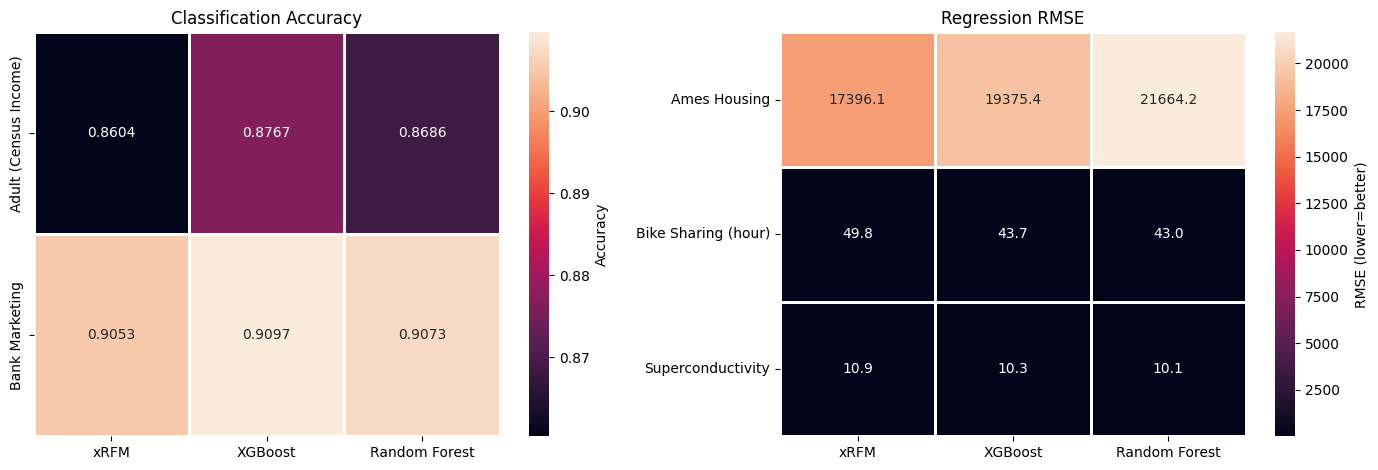

Main performance heatmap save step finished.
Saved path: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/figures/main_test_performance_summary.png


In [ ]:
# I save the main test-set performance heatmap.
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs(FIGURES_DIR, exist_ok=True)

MAIN_PERFORMANCE_FIGURE_PATH = os.path.join(
    FIGURES_DIR,
    "main_test_performance_summary.png"
)

# I keep the model order consistent across the figure.
model_order = ["xrfm", "xgboost", "random_forest"]
model_labels = {
    "xrfm": "xRFM",
    "xgboost": "XGBoost",
    "random_forest": "Random Forest"
}

# I prepare the classification accuracy table.
classification_heatmap_df = (
    RESULTS_CLEAN_DF[RESULTS_CLEAN_DF["task_type"] == "classification"]
    .pivot(index="dataset_name", columns="model_name", values="test_accuracy")
    .reindex(columns=model_order)
    .rename(columns=model_labels)
)

# I prepare the regression RMSE table.
regression_heatmap_df = (
    RESULTS_CLEAN_DF[RESULTS_CLEAN_DF["task_type"] == "regression"]
    .pivot(index="dataset_name", columns="model_name", values="test_rmse")
    .reindex(columns=model_order)
    .rename(columns=model_labels)
)

# I keep a clear dataset order for readability.
classification_order = ["Adult (Census Income)", "Bank Marketing"]
regression_order = ["Ames Housing", "Bike Sharing (hour)", "Superconductivity"]

classification_heatmap_df = classification_heatmap_df.reindex(classification_order)
regression_heatmap_df = regression_heatmap_df.reindex(regression_order)

# I plot the classification and regression summaries side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.heatmap(
    classification_heatmap_df,
    annot=True,
    fmt=".4f",
    linewidths=1,
    ax=axes[0],
    cbar_kws={"label": "Accuracy"}
)
axes[0].set_title("Classification Accuracy")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    regression_heatmap_df,
    annot=True,
    fmt=".1f",
    linewidths=1,
    ax=axes[1],
    cbar_kws={"label": "RMSE (lower=better)"}
)
axes[1].set_title("Regression RMSE")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(MAIN_PERFORMANCE_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Main performance heatmap save step finished.")
print("Saved path:", MAIN_PERFORMANCE_FIGURE_PATH)

### Part 6 Summary: Evaluation and Result Tables

In Part 6, I converted the raw model comparison outputs into clean evaluation tables and saved the main result artifacts.

I completed the main evaluation steps by:

- loading the final result table
- checking the required result columns
- converting metric and timing fields into numeric values
- sorting the results for easier comparison
- building separate regression and classification comparison tables

The evaluation tables compare both predictive quality and runtime cost:

- **Regression tasks**: RMSE, training time, and per-sample inference time
- **Classification tasks**: accuracy, AUC-ROC, training time, and per-sample inference time

I also built dataset-level best-model summaries across the **5 datasets** and counted how often each model produced the strongest test-set result within each task type. This gives me a compact view of the overall model comparison in addition to the detailed result rows.

Finally, I saved the cleaned result tables, task-specific comparison tables, best-model summaries, selected model parameters, and the main performance heatmap for later review and result discussion.

## Part 7. Interpretability Analysis

### Set Up Interpretability Dataset and Model

I set up the interpretability analysis using the validation-selected xRFM model for Ames Housing.

This setup keeps the interpretation workflow aligned with the same processed data and selected model used in the main comparison.

I collect:

- processed train, validation, and test arrays
- processed feature names
- task type
- stored xRFM result
- selected xRFM model
- selected hyperparameters from validation-based tuning

I also display an overview table so I can verify the dataset, task type, split sizes, processed feature count, and selected parameters before extracting feature-importance information.

In [ ]:
# I choose the dataset and model used for the interpretability analysis.
INTERPRETABILITY_DATASET_KEY = "ames_housing"
INTERPRETABILITY_MODEL_NAME = "xrfm"

# I make sure the trained model dictionary exists before inspecting xRFM.
if "FULL_MODEL_OBJECTS" not in globals():
    raise ValueError("FULL_MODEL_OBJECTS is not available. Please run the model training section first.")

# I check that the selected dataset has already been preprocessed.
if INTERPRETABILITY_DATASET_KEY not in PREPROCESSED_DATA:
    raise ValueError(f"{INTERPRETABILITY_DATASET_KEY} is not available in PREPROCESSED_DATA.")

# I check that the selected dataset has trained model results.
if INTERPRETABILITY_DATASET_KEY not in FULL_MODEL_OBJECTS:
    raise ValueError(f"{INTERPRETABILITY_DATASET_KEY} is not available in FULL_MODEL_OBJECTS.")

# I check that the selected xRFM model is available for this dataset.
if INTERPRETABILITY_MODEL_NAME not in FULL_MODEL_OBJECTS[INTERPRETABILITY_DATASET_KEY]:
    raise ValueError(f"{INTERPRETABILITY_MODEL_NAME} was not found for {INTERPRETABILITY_DATASET_KEY}.")

# I retrieve the processed bundle, stored result, and selected model.
INTERP_BUNDLE = PREPROCESSED_DATA[INTERPRETABILITY_DATASET_KEY]
INTERP_RESULT = FULL_MODEL_OBJECTS[INTERPRETABILITY_DATASET_KEY][INTERPRETABILITY_MODEL_NAME]
INTERP_MODEL = INTERP_RESULT["best_model"]

# I unpack the processed train, validation, and test arrays.
X_train_interp = INTERP_BUNDLE["X_train"]
X_val_interp = INTERP_BUNDLE["X_val"]
X_test_interp = INTERP_BUNDLE["X_test"]
y_train_interp = INTERP_BUNDLE["y_train"]
y_val_interp = INTERP_BUNDLE["y_val"]
y_test_interp = INTERP_BUNDLE["y_test"]

# I keep feature names and task type close to the data for later tables and plots.
INTERP_FEATURE_NAMES = INTERP_BUNDLE["metadata"]["feature_names"]
INTERP_TASK_TYPE = INTERP_BUNDLE["metadata"]["task_type"]

# I summarise the interpretability setup before extracting feature-importance scores.
interp_overview_df = pd.DataFrame([
    {"field": "dataset_key", "value": INTERPRETABILITY_DATASET_KEY},
    {"field": "dataset_name", "value": INTERP_BUNDLE["metadata"]["dataset_name"]},
    {"field": "task_type", "value": INTERP_TASK_TYPE},
    {"field": "model_name", "value": INTERPRETABILITY_MODEL_NAME},
    {"field": "processed_n_features", "value": INTERP_BUNDLE["metadata"]["processed_n_features"]},
    {"field": "n_train", "value": INTERP_BUNDLE["metadata"]["n_train"]},
    {"field": "n_val", "value": INTERP_BUNDLE["metadata"]["n_val"]},
    {"field": "n_test", "value": INTERP_BUNDLE["metadata"]["n_test"]},
    {"field": "best_params", "value": str(INTERP_RESULT["best_params"])}
])

# I display the setup table so the selected dataset and model are easy to check.
display(interp_overview_df)
print("Interpretability analysis setup completed.")

,field,value
0,dataset_key,ames_housing
1,dataset_name,Ames Housing
2,task_type,regression
3,model_name,xrfm
4,processed_n_features,280
5,n_train,876
6,n_val,292
7,n_test,292
8,best_params,"{'bandwidth': 20.0, 'exponent': 1.0, 'kernel':..."


Interpretability analysis setup completed.


### Prepare AGOP Matrix Extraction Helpers

I define helper functions to inspect the fitted xRFM object and search for candidate feature-by-feature matrices.

This step helps me:

- convert tensors and arrays into NumPy format
- search nested model attributes safely
- keep only square matrices that match the processed feature dimension
- remove duplicate matrix records
- preview the fitted model’s top-level attributes before deeper inspection

I treat the extracted matrices as AGOP-like candidates at this stage. The later cells decide which matrix is most useful for feature-importance analysis.

In [ ]:
# I convert NumPy arrays and PyTorch tensors into NumPy matrices when possible.
def convert_to_numpy_matrix(obj):
    if isinstance(obj, np.ndarray):
        return obj
    if "torch" in str(type(obj)).lower():
        try:
            return obj.detach().cpu().numpy()
        except Exception:
            return None
    return None


# I recursively search an object for square feature-by-feature matrices.
def recursively_collect_feature_matrices(obj, feature_dim, path="root", visited=None, max_depth=8):
    if visited is None:
        visited = set()

    results = []

    # I avoid revisiting the same object.
    if id(obj) in visited:
        return results
    visited.add(id(obj))

    # I keep the recursive search bounded.
    if max_depth < 0:
        return results

    # I keep finite matrices that match the processed feature dimension.
    arr = convert_to_numpy_matrix(obj)
    if arr is not None:
        if arr.ndim == 2 and arr.shape[0] == feature_dim and arr.shape[1] == feature_dim:
            if np.isfinite(arr).all():
                results.append({
                    "path": path,
                    "matrix": arr
                })

    # I search dictionary values while preserving the access path.
    if isinstance(obj, dict):
        for k, v in obj.items():
            results.extend(
                recursively_collect_feature_matrices(
                    v,
                    feature_dim,
                    path=f"{path}.{k}",
                    visited=visited,
                    max_depth=max_depth - 1
                )
            )

    # I search list and tuple entries while preserving their positions.
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            results.extend(
                recursively_collect_feature_matrices(
                    v,
                    feature_dim,
                    path=f"{path}[{i}]",
                    visited=visited,
                    max_depth=max_depth - 1
                )
            )

    else:
        # I inspect object attributes for fitted models and custom classes.
        if hasattr(obj, "__dict__"):
            for attr_name, attr_value in vars(obj).items():
                results.extend(
                    recursively_collect_feature_matrices(
                        attr_value,
                        feature_dim,
                        path=f"{path}.{attr_name}",
                        visited=visited,
                        max_depth=max_depth - 1
                    )
                )

    return results


# I remove duplicate matrix records.
def deduplicate_feature_matrices(matrix_records):
    unique_records = []
    seen_signatures = set()

    for rec in matrix_records:
        arr = rec["matrix"]

        # I use a compact signature based on matrix shape, trace, and diagonal values.
        signature = (
            arr.shape,
            np.round(np.trace(arr), 8),
            np.round(arr.diagonal()[: min(20, len(arr))], 8).tobytes()
        )

        # I keep the first matrix for each signature.
        if signature not in seen_signatures:
            seen_signatures.add(signature)
            unique_records.append(rec)

    return unique_records


# I list top-level attributes of the fitted xRFM model before deeper inspection.
top_level_attr_df = pd.DataFrame({
    "top_level_attribute": sorted(list(vars(INTERP_MODEL).keys()))
})

# I display a short attribute preview.
display(top_level_attr_df.head(30))
print("AGOP-like matrix extraction helpers are ready.")
print("Top-level attribute count:", len(top_level_attr_df))

,top_level_attribute
0,_base_max_leaf_size
1,callback
2,categorical_info
3,classification_mode
4,data_dim
5,default_rfm_params
6,device
7,extra_rfm_params_
8,fixed_vector
9,keep_weight_frac_in_predict


AGOP-like matrix extraction helpers are ready.
Top-level attribute count: 33


### Extract Leaf AGOP Scores

I extract usable leaf-level feature matrices from the fitted xRFM model.

The extraction flow is:

- check xRFM’s AGOP collector first
- fall back to stored M matrices when usable AGOP matrices are not available
- convert diagonal vectors or square matrices into feature-level scores
- normalise scores within each leaf
- list the strongest processed features for local interpretation

In the current run, the fitted model exposes usable **M diagonal vectors** as the fallback source. I use these leaf-level scores as feature-activity indicators inside the selected xRFM model, while keeping the matrix type visible in the output table.

In [ ]:
# I safely convert tensors or array-like objects into NumPy arrays.
def tensor_to_numpy_safe(x):
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        return x
    try:
        return x.detach().cpu().numpy()
    except Exception:
        try:
            return np.asarray(x)
        except Exception:
            return None


# I use the processed feature count to check matrix shapes.
feature_dim = len(INTERP_FEATURE_NAMES)

# I first try to collect AGOP matrices from the fitted xRFM model.
agop_list = []
if hasattr(INTERP_MODEL, "collect_best_agops"):
    try:
        agop_list = INTERP_MODEL.collect_best_agops()
    except Exception:
        agop_list = []

# I also collect M matrices as a fallback source.
m_list = []
if hasattr(INTERP_MODEL, "collect_Ms"):
    try:
        m_list = INTERP_MODEL.collect_Ms()
    except Exception:
        m_list = []

# I store every usable leaf-level AGOP or fallback M object.
AGOP_MATRIX_RECORDS = []

# I process AGOP outputs first.
for leaf_id, mat in enumerate(agop_list, start=1):
    arr = tensor_to_numpy_safe(mat)
    if arr is None:
        continue
    if arr.ndim == 1 and arr.shape[0] == feature_dim:
        AGOP_MATRIX_RECORDS.append({
            "leaf_id": leaf_id,
            "matrix_type": "agop_diag_vector",
            "matrix": arr
        })
    elif arr.ndim == 2 and arr.shape[0] == feature_dim and arr.shape[1] == feature_dim:
        AGOP_MATRIX_RECORDS.append({
            "leaf_id": leaf_id,
            "matrix_type": "agop_full_matrix",
            "matrix": arr
        })

# I fall back to M outputs only when no usable AGOP matrices are found.
if len(AGOP_MATRIX_RECORDS) == 0:
    for leaf_id, mat in enumerate(m_list, start=1):
        arr = tensor_to_numpy_safe(mat)
        if arr is None:
            continue
        if arr.ndim == 1 and arr.shape[0] == feature_dim:
            AGOP_MATRIX_RECORDS.append({
                "leaf_id": leaf_id,
                "matrix_type": "M_diag_vector",
                "matrix": arr
            })
        elif arr.ndim == 2 and arr.shape[0] == feature_dim and arr.shape[1] == feature_dim:
            AGOP_MATRIX_RECORDS.append({
                "leaf_id": leaf_id,
                "matrix_type": "M_full_matrix",
                "matrix": arr
            })

# I stop if the fitted model does not expose usable feature-level matrices.
if len(AGOP_MATRIX_RECORDS) == 0:
    raise ValueError("No usable leaf AGOP or M matrices were returned by the fitted xRFM model.")

# I prepare matrix-level summaries and feature-level score tables.
agop_matrix_summary_rows = []
agop_leaf_long_rows = []

# I turn each leaf matrix into diagonal-based feature scores.
for rec in AGOP_MATRIX_RECORDS:
    leaf_id = rec["leaf_id"]
    matrix_type = rec["matrix_type"]
    M = rec["matrix"]

    # I handle both diagonal vectors and full square matrices.
    if M.ndim == 1:
        diag_vals = M.astype(float)
        trace_val = float(np.sum(diag_vals))
    else:
        diag_vals = np.diag(M).astype(float)
        trace_val = float(np.trace(M))

    # I normalise absolute diagonal values within each leaf.
    diag_abs_sum = float(np.sum(np.abs(diag_vals)))
    if diag_abs_sum > 0:
        diag_importance = np.abs(diag_vals) / diag_abs_sum
    else:
        diag_importance = np.zeros_like(diag_vals)

    # I record simple matrix-level statistics.
    agop_matrix_summary_rows.append({
        "leaf_id": leaf_id,
        "matrix_type": matrix_type,
        "trace": trace_val,
        "mean_diag": float(np.mean(diag_vals)),
        "max_diag": float(np.max(diag_vals)),
        "min_diag": float(np.min(diag_vals))
    })

    # I store one feature score per leaf.
    for feature_name, raw_diag, importance in zip(INTERP_FEATURE_NAMES, diag_vals, diag_importance):
        agop_leaf_long_rows.append({
            "leaf_id": leaf_id,
            "matrix_type": matrix_type,
            "feature_name": feature_name,
            "agop_diag_raw": float(raw_diag),
            "agop_diag_importance": float(importance)
        })

# I create a leaf-matrix summary table.
AGOP_MATRIX_SUMMARY_DF = pd.DataFrame(agop_matrix_summary_rows).sort_values(
    by=["leaf_id", "trace"],
    ascending=[True, False]
).reset_index(drop=True)

# I create the long feature-importance table for all extracted leaves.
AGOP_LEAF_LONG_DF = pd.DataFrame(agop_leaf_long_rows)

# I keep the top features in each leaf for local interpretation.
AGOP_LEAF_TOP_FEATURES_DF = (
    AGOP_LEAF_LONG_DF
    .sort_values(["leaf_id", "agop_diag_importance"], ascending=[True, False])
    .groupby("leaf_id")
    .head(10)
    .reset_index(drop=True)
)

# I display the matrix checks and strongest leaf-level features.
display(AGOP_MATRIX_SUMMARY_DF)
display(AGOP_LEAF_TOP_FEATURES_DF.head(30))

# I print a short extraction status.
print("Leaf AGOP / M matrix extraction finished.")
print("Number of usable leaf matrices:", len(AGOP_MATRIX_RECORDS))
print("AGOP collectors were checked first, with M matrices used as fallback when needed.")

,leaf_id,matrix_type,trace,mean_diag,max_diag,min_diag
0,1,M_diag_vector,4.669858,0.016678,1.0,3.817958e-33


,leaf_id,matrix_type,feature_name,agop_diag_raw,agop_diag_importance
0,1,M_diag_vector,grlivarea,1.000000,0.214139
1,1,M_diag_vector,yearbuilt,0.525185,0.112463
2,1,M_diag_vector,overallqual,0.444845,0.095259
3,1,M_diag_vector,lotarea,0.301716,0.064609
4,1,M_diag_vector,neighborhood_Crawfor,0.285336,0.061102
5,1,M_diag_vector,bsmtexposure_Gd,0.267645,0.057313
6,1,M_diag_vector,exterior1st_BrkFace,0.245084,0.052482
7,1,M_diag_vector,totalbsmtsf,0.197206,0.042230
8,1,M_diag_vector,neighborhood_StoneBr,0.197052,0.042197
9,1,M_diag_vector,overallcond,0.177961,0.038109


Leaf AGOP / M matrix extraction finished.
Number of usable leaf matrices: 1
AGOP collectors were checked first, with M matrices used as fallback when needed.


### Aggregate xRFM Diagonal Feature Importance

I aggregate the extracted leaf-level xRFM diagonal scores into one global feature ranking for Ames Housing.

The aggregation uses the normalised feature-level diagonal scores from the detected leaves, then averages them across leaves to create a compact global view.

This step produces:

- a global feature-importance table
- standard deviation and maximum importance checks
- the number of detected leaves contributing to each feature score
- a bar chart of the top **15** processed features

Because the current extraction used fallback M diagonal vectors, I treat this ranking as an xRFM diagonal feature-activity summary rather than a standalone causal explanation.

,feature_name,agop_mean_importance,agop_std_importance,agop_max_importance,num_leaves_detected
0,grlivarea,0.214139,NaN,0.214139,1
1,yearbuilt,0.112463,NaN,0.112463,1
2,overallqual,0.095259,NaN,0.095259,1
3,lotarea,0.064609,NaN,0.064609,1
4,neighborhood_Crawfor,0.061102,NaN,0.061102,1
5,bsmtexposure_Gd,0.057313,NaN,0.057313,1
6,exterior1st_BrkFace,0.052482,NaN,0.052482,1
7,totalbsmtsf,0.042230,NaN,0.042230,1
8,neighborhood_StoneBr,0.042197,NaN,0.042197,1
9,overallcond,0.038109,NaN,0.038109,1


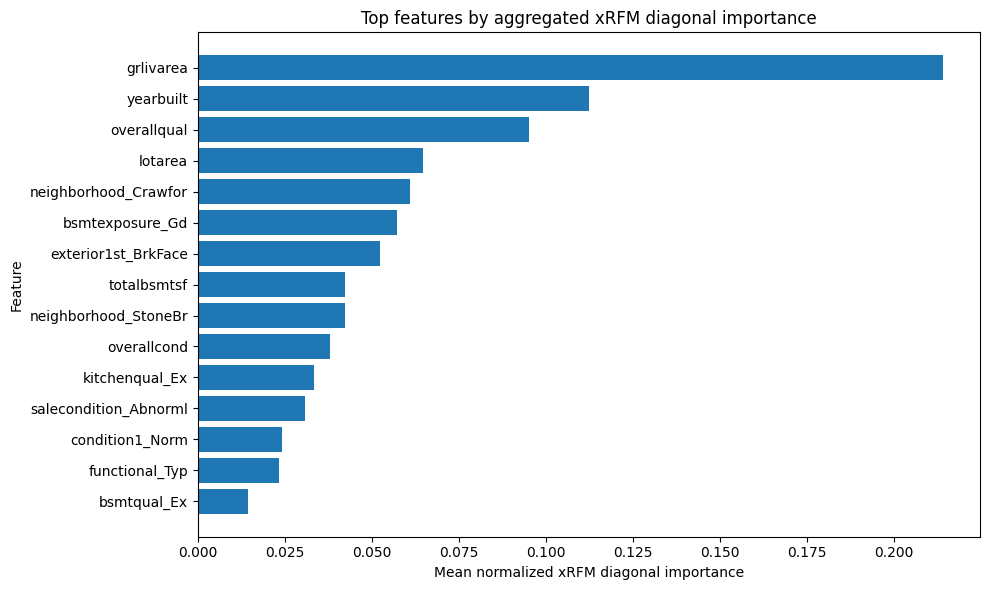

Aggregated xRFM diagonal importance table created.


In [ ]:
# I aggregate the extracted leaf-level diagonal scores into one global feature-importance table.
AGOP_AGG_DF = (
    AGOP_LEAF_LONG_DF
    .groupby("feature_name", as_index=False)
    .agg(
        agop_mean_importance=("agop_diag_importance", "mean"),
        agop_std_importance=("agop_diag_importance", "std"),
        agop_max_importance=("agop_diag_importance", "max"),
        num_leaves_detected=("leaf_id", "nunique")
    )
    .sort_values(by="agop_mean_importance", ascending=False)
    .reset_index(drop=True)
)

# I keep the top-ranked features for a compact table and plot.
AGOP_TOP15_DF = AGOP_AGG_DF.head(15).copy()

# I display the strongest features by averaged diagonal importance.
display(AGOP_TOP15_DF)

# I plot the top-ranked features for easier review.
plt.figure(figsize=(10, 6))
plt.barh(
    AGOP_TOP15_DF["feature_name"][::-1],
    AGOP_TOP15_DF["agop_mean_importance"][::-1]
)
plt.xlabel("Mean normalized xRFM diagonal importance")
plt.ylabel("Feature")
plt.title("Top features by aggregated xRFM diagonal importance")
plt.tight_layout()
plt.show()

# I confirm that the aggregated importance output is ready.
print("Aggregated xRFM diagonal importance table created.")

### Compute Baseline Importance Scores

I compute three baseline feature-importance methods on the same processed Ames Housing data:

- PCA loading-based importance
- mutual information
- permutation importance

These methods provide comparison points for the extracted xRFM diagonal feature-activity ranking.

I fit PCA and mutual information on the training data, then compute permutation importance on the test data using the selected xRFM model. For regression, the wrapper returns negative RMSE as the score, so permutation importance reflects how much the model score changes when each feature is shuffled.

This setup keeps the baseline comparison aligned with the same processed feature space, data split, and validation-selected xRFM model used in the main experiment.

In [ ]:
# I import BaseEstimator so the fitted xRFM model can work with permutation importance.
from sklearn.base import BaseEstimator

# I wrap the fitted xRFM model in a scikit-learn-style interface.
class XRFMInterpretabilityWrapper(BaseEstimator):
    def __init__(self, fitted_model, task_type):
        self.fitted_model = fitted_model
        self.task_type = task_type

    # I only expose the already trained model.
    def fit(self, X, y=None):
        return self

    # I convert xRFM predictions into a flat NumPy vector.
    def predict(self, X):
        preds = self.fitted_model.predict(X)
        return to_numpy_cpu(preds).ravel()

    # I define a score function for permutation importance.
    def score(self, X, y):
        y_pred = self.predict(X)

        # I return negative RMSE for regression because higher scores are better in scikit-learn.
        if self.task_type == "regression":
            rmse = np.sqrt(mean_squared_error(y, y_pred))
            return -rmse
        else:
            return accuracy_score(y, y_pred)


# I keep the PCA comparison compact.
NUM_PCS = min(5, X_train_interp.shape[1])

# I fit PCA on the training features only.
pca = PCA(n_components=NUM_PCS, random_state=SEED)
pca.fit(X_train_interp)

# I weight absolute PCA loadings by explained variance.
pca_weighted_importance = np.sum(
    np.abs(pca.components_) * pca.explained_variance_ratio_[:, None],
    axis=0
)

# I compute mutual information using the matching task type.
if INTERP_TASK_TYPE == "regression":
    mi_scores = mutual_info_regression(
        X_train_interp,
        y_train_interp,
        random_state=SEED
    )
else:
    mi_scores = mutual_info_classif(
        X_train_interp,
        y_train_interp,
        random_state=SEED
    )

# I wrap the selected xRFM model for permutation importance.
interp_wrapper = XRFMInterpretabilityWrapper(
    fitted_model=INTERP_MODEL,
    task_type=INTERP_TASK_TYPE
)

# I compute permutation importance on the test set.
if INTERP_TASK_TYPE == "regression":
    permutation_result = permutation_importance(
        estimator=interp_wrapper,
        X=X_test_interp,
        y=y_test_interp,
        scoring=None,
        n_repeats=5,
        random_state=SEED,
        n_jobs=-1
    )
else:
    permutation_result = permutation_importance(
        estimator=interp_wrapper,
        X=X_test_interp,
        y=y_test_interp,
        scoring="accuracy",
        n_repeats=5,
        random_state=SEED,
        n_jobs=-1
    )

# I combine the baseline importance methods into one feature-level table.
OTHER_IMPORTANCE_DF = pd.DataFrame({
    "feature_name": INTERP_FEATURE_NAMES,
    "pca_importance": pca_weighted_importance,
    "mi_importance": mi_scores,
    "permutation_importance": permutation_result.importances_mean
})

# I sort by permutation importance because it directly measures model-score change.
OTHER_IMPORTANCE_DF = OTHER_IMPORTANCE_DF.sort_values(
    by="permutation_importance",
    ascending=False
).reset_index(drop=True)

# I record a compact method summary.
method_summary_df = pd.DataFrame([
    {"method": "PCA", "status": "done", "detail": f"{NUM_PCS} principal components"},
    {"method": "Mutual Information", "status": "done", "detail": INTERP_TASK_TYPE},
    {"method": "Permutation Importance", "status": "done", "detail": "configured repeats"}
])

# I display the method summary and strongest baseline-importance features.
display(method_summary_df)
display(OTHER_IMPORTANCE_DF.head(20))

# I confirm that the baseline comparison methods are ready.
print("Baseline importance scores computed.")
print("Number of PCA components used:", NUM_PCS)

,method,status,detail
0,PCA,done,5 principal components
1,Mutual Information,done,regression
2,Permutation Importance,done,configured repeats


,feature_name,pca_importance,mi_importance,permutation_importance
0,grlivarea,0.073692,0.443046,23387.977016
1,yearbuilt,0.073963,0.321352,13233.381621
2,overallqual,0.053722,0.518392,11521.606777
3,overallcond,0.038868,0.130675,4116.503712
4,totalbsmtsf,0.075696,0.324605,4084.753583
5,bsmtfinsf1,0.073506,0.108028,1485.415025
6,lotarea,0.036614,0.147619,982.161816
7,neighborhood_Crawfor,0.002678,0.006594,783.083586
8,garagecars,0.047921,0.341451,754.556824
9,bsmtexposure_Gd,0.010048,0.031143,674.892808


Baseline importance scores computed.
Number of PCA components used: 5


### Compare Interpretability Methods

I compare the extracted xRFM diagonal feature ranking with PCA loadings, mutual information, and permutation importance.

The comparison focuses on:

- feature ranks from each method
- top-k feature overlap
- average rank across methods
- rank spread across methods

For the rank-based summaries, a smaller rank means stronger importance. I use the mean rank to identify features that are consistently important across methods, and I use rank spread to identify features whose importance depends more strongly on the interpretation method.

The overlap table, consensus table, and divergence table stay in the notebook output so the method agreement patterns remain tied to the current run.

,comparison,top_k_overlap
0,xRFM diagonal vs PCA,3
1,xRFM diagonal vs MI,4
2,xRFM diagonal vs Permutation,8
3,PCA vs MI,5
4,PCA vs Permutation,4
5,MI vs Permutation,5


,feature_name,mean_rank,rank_spread,rank_agop,rank_pca,rank_mi,rank_permutation
0,grlivarea,2.00,3.0,1.0,4.0,2.0,1.0
1,yearbuilt,3.00,3.0,2.0,3.0,5.0,2.0
7,totalbsmtsf,4.50,7.0,8.0,1.0,4.0,5.0
2,overallqual,5.50,14.0,3.0,15.0,1.0,3.0
16,garagecars,12.00,16.0,17.0,19.0,3.0,9.0
19,yearremodadd,13.25,11.0,20.0,11.0,9.0,13.0
18,2ndflrsf,13.25,13.0,19.0,6.0,14.0,14.0
15,bsmtfinsf1,14.25,25.0,16.0,5.0,30.0,6.0
3,lotarea,14.50,20.0,4.0,24.0,23.0,7.0
9,overallcond,15.25,21.0,10.0,22.0,25.0,4.0


,feature_name,mean_rank,rank_spread,rank_agop,rank_pca,rank_mi,rank_permutation
38,1stflrsf,81.00,274.0,39.0,2.0,7.0,276.0
8,neighborhood_StoneBr,148.00,271.0,9.0,157.0,146.0,280.0
49,garageyrblt,84.50,263.0,50.0,7.0,11.0,270.0
13,functional_Typ,163.00,261.0,14.0,111.0,252.0,275.0
14,bsmtqual_Ex,99.00,259.0,15.0,73.0,34.0,274.0
23,saletype_New,106.50,254.0,24.0,70.0,54.0,278.0
25,salecondition_Partial,103.00,253.0,26.0,69.0,38.0,279.0
64,bsmtqual_TA,93.50,247.0,65.0,30.0,16.0,263.0
50,kitchenqual_TA,93.00,247.0,51.0,40.0,17.0,264.0
24,landcontour_HLS,141.50,246.0,25.0,179.0,91.0,271.0


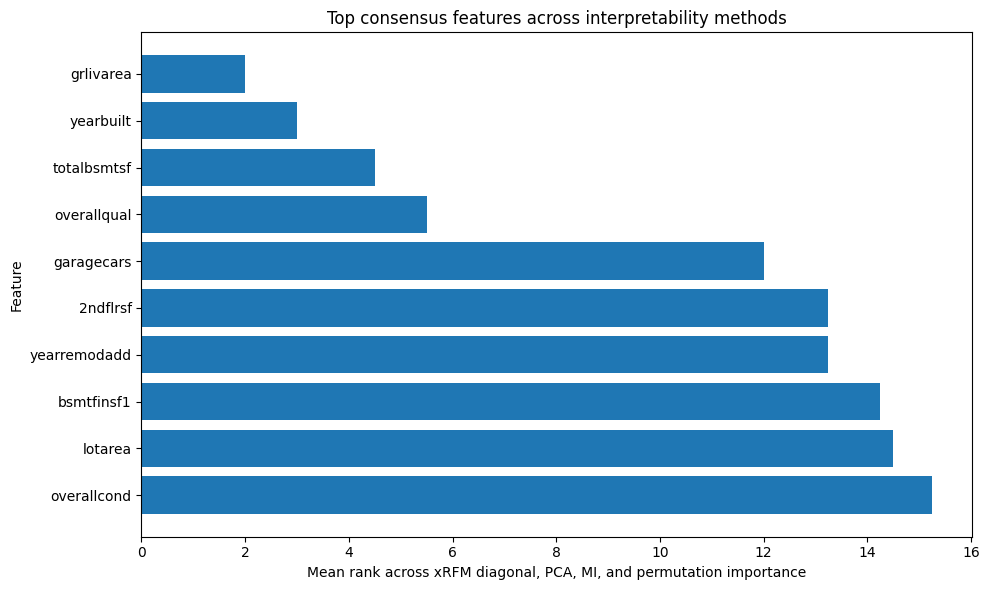

Interpretability agreement and divergence comparison completed.


In [ ]:
# I merge the extracted xRFM diagonal summary with the baseline importance results.
INTERPRETABILITY_COMPARISON_DF = AGOP_AGG_DF.merge(
    OTHER_IMPORTANCE_DF,
    on="feature_name",
    how="inner"
)

# I convert each method into a feature ranking, where smaller rank means higher importance.
INTERPRETABILITY_COMPARISON_DF["rank_agop"] = INTERPRETABILITY_COMPARISON_DF["agop_mean_importance"].rank(
    ascending=False,
    method="average"
)
INTERPRETABILITY_COMPARISON_DF["rank_pca"] = INTERPRETABILITY_COMPARISON_DF["pca_importance"].rank(
    ascending=False,
    method="average"
)
INTERPRETABILITY_COMPARISON_DF["rank_mi"] = INTERPRETABILITY_COMPARISON_DF["mi_importance"].rank(
    ascending=False,
    method="average"
)
INTERPRETABILITY_COMPARISON_DF["rank_permutation"] = INTERPRETABILITY_COMPARISON_DF["permutation_importance"].rank(
    ascending=False,
    method="average"
)

# I compute average rank and rank spread across methods.
INTERPRETABILITY_COMPARISON_DF["mean_rank"] = INTERPRETABILITY_COMPARISON_DF[
    ["rank_agop", "rank_pca", "rank_mi", "rank_permutation"]
].mean(axis=1)

INTERPRETABILITY_COMPARISON_DF["rank_spread"] = INTERPRETABILITY_COMPARISON_DF[
    ["rank_agop", "rank_pca", "rank_mi", "rank_permutation"]
].max(axis=1) - INTERPRETABILITY_COMPARISON_DF[
    ["rank_agop", "rank_pca", "rank_mi", "rank_permutation"]
].min(axis=1)

# I keep consensus features and high-disagreement features as separate summaries.
CONSENSUS_TOP_FEATURES_DF = INTERPRETABILITY_COMPARISON_DF.sort_values(
    by=["mean_rank", "rank_spread"],
    ascending=[True, True]
).head(15)

DIVERGENCE_TOP_FEATURES_DF = INTERPRETABILITY_COMPARISON_DF.sort_values(
    by="rank_spread",
    ascending=False
).head(15)

# I compare overlap between top-k feature sets from different methods.
TOP_K = 10
top_agop = set(INTERPRETABILITY_COMPARISON_DF.sort_values("agop_mean_importance", ascending=False).head(TOP_K)["feature_name"])
top_pca = set(INTERPRETABILITY_COMPARISON_DF.sort_values("pca_importance", ascending=False).head(TOP_K)["feature_name"])
top_mi = set(INTERPRETABILITY_COMPARISON_DF.sort_values("mi_importance", ascending=False).head(TOP_K)["feature_name"])
top_perm = set(INTERPRETABILITY_COMPARISON_DF.sort_values("permutation_importance", ascending=False).head(TOP_K)["feature_name"])

# I summarise pairwise top-k overlap.
overlap_summary_df = pd.DataFrame([
    {"comparison": "xRFM diagonal vs PCA", "top_k_overlap": len(top_agop & top_pca)},
    {"comparison": "xRFM diagonal vs MI", "top_k_overlap": len(top_agop & top_mi)},
    {"comparison": "xRFM diagonal vs Permutation", "top_k_overlap": len(top_agop & top_perm)},
    {"comparison": "PCA vs MI", "top_k_overlap": len(top_pca & top_mi)},
    {"comparison": "PCA vs Permutation", "top_k_overlap": len(top_pca & top_perm)},
    {"comparison": "MI vs Permutation", "top_k_overlap": len(top_mi & top_perm)}
])

# I display overlap, consensus features, and high-disagreement features.
display(overlap_summary_df)
display(CONSENSUS_TOP_FEATURES_DF[[
    "feature_name", "mean_rank", "rank_spread",
    "rank_agop", "rank_pca", "rank_mi", "rank_permutation"
]])
display(DIVERGENCE_TOP_FEATURES_DF[[
    "feature_name", "mean_rank", "rank_spread",
    "rank_agop", "rank_pca", "rank_mi", "rank_permutation"
]])

# I plot the strongest consensus features.
plot_df = CONSENSUS_TOP_FEATURES_DF.head(10).sort_values("mean_rank", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature_name"], plot_df["mean_rank"])
plt.xlabel("Mean rank across xRFM diagonal, PCA, MI, and permutation importance")
plt.ylabel("Feature")
plt.title("Top consensus features across interpretability methods")
plt.tight_layout()
plt.show()

print("Interpretability agreement and divergence comparison completed.")

### Save Interpretability Outputs

I save the interpretability outputs into a separate folder under the results directory.

The saved files include:

- extracted xRFM diagonal matrix summaries
- leaf-level diagonal feature scores
- aggregated xRFM diagonal feature-activity table
- baseline importance scores
- cross-method comparison results
- consensus feature summary
- divergence feature summary
- top-k overlap summary

This produces **8 interpretability CSV files** in total. I keep these outputs separate from the main model comparison tables so the interpretation results are easier to review, reuse, and discuss later.

In [ ]:
# I create a separate folder for interpretability outputs.
INTERP_DIR = os.path.join(RESULTS_DIR, "interpretability")
os.makedirs(INTERP_DIR, exist_ok=True)

# I define CSV paths for xRFM diagonal outputs, comparison tables, and agreement summaries.
AGOP_MATRIX_SUMMARY_PATH = os.path.join(INTERP_DIR, "agop_matrix_summary.csv")
AGOP_LEAF_LONG_PATH = os.path.join(INTERP_DIR, "agop_leaf_long.csv")
AGOP_AGG_PATH = os.path.join(INTERP_DIR, "agop_aggregated_importance.csv")
OTHER_IMPORTANCE_PATH = os.path.join(INTERP_DIR, "other_importance_methods.csv")
INTERPRETABILITY_COMPARISON_PATH = os.path.join(INTERP_DIR, "interpretability_comparison.csv")
CONSENSUS_TOP_FEATURES_PATH = os.path.join(INTERP_DIR, "consensus_top_features.csv")
DIVERGENCE_TOP_FEATURES_PATH = os.path.join(INTERP_DIR, "divergence_top_features.csv")
OVERLAP_SUMMARY_PATH = os.path.join(INTERP_DIR, "overlap_summary.csv")

# I save the extracted matrix summaries and feature-level diagonal scores.
AGOP_MATRIX_SUMMARY_DF.to_csv(AGOP_MATRIX_SUMMARY_PATH, index=False)
AGOP_LEAF_LONG_DF.to_csv(AGOP_LEAF_LONG_PATH, index=False)
AGOP_AGG_DF.to_csv(AGOP_AGG_PATH, index=False)

# I save the baseline importance scores and cross-method comparison table.
OTHER_IMPORTANCE_DF.to_csv(OTHER_IMPORTANCE_PATH, index=False)
INTERPRETABILITY_COMPARISON_DF.to_csv(INTERPRETABILITY_COMPARISON_PATH, index=False)

# I save the agreement, disagreement, and top-k overlap summaries.
CONSENSUS_TOP_FEATURES_DF.to_csv(CONSENSUS_TOP_FEATURES_PATH, index=False)
DIVERGENCE_TOP_FEATURES_DF.to_csv(DIVERGENCE_TOP_FEATURES_PATH, index=False)
overlap_summary_df.to_csv(OVERLAP_SUMMARY_PATH, index=False)

# I build a saved-file checklist for the interpretability outputs.
interp_save_df = pd.DataFrame([
    {"file_name": "agop_matrix_summary.csv", "path": AGOP_MATRIX_SUMMARY_PATH, "exists": os.path.exists(AGOP_MATRIX_SUMMARY_PATH)},
    {"file_name": "agop_leaf_long.csv", "path": AGOP_LEAF_LONG_PATH, "exists": os.path.exists(AGOP_LEAF_LONG_PATH)},
    {"file_name": "agop_aggregated_importance.csv", "path": AGOP_AGG_PATH, "exists": os.path.exists(AGOP_AGG_PATH)},
    {"file_name": "other_importance_methods.csv", "path": OTHER_IMPORTANCE_PATH, "exists": os.path.exists(OTHER_IMPORTANCE_PATH)},
    {"file_name": "interpretability_comparison.csv", "path": INTERPRETABILITY_COMPARISON_PATH, "exists": os.path.exists(INTERPRETABILITY_COMPARISON_PATH)},
    {"file_name": "consensus_top_features.csv", "path": CONSENSUS_TOP_FEATURES_PATH, "exists": os.path.exists(CONSENSUS_TOP_FEATURES_PATH)},
    {"file_name": "divergence_top_features.csv", "path": DIVERGENCE_TOP_FEATURES_PATH, "exists": os.path.exists(DIVERGENCE_TOP_FEATURES_PATH)},
    {"file_name": "overlap_summary.csv", "path": OVERLAP_SUMMARY_PATH, "exists": os.path.exists(OVERLAP_SUMMARY_PATH)}
])

# I display the checklist so missing files are visible.
display(interp_save_df)
print("Interpretability output save step finished.")

,file_name,path,exists
0,agop_matrix_summary.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
1,agop_leaf_long.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
2,agop_aggregated_importance.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
3,other_importance_methods.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
4,interpretability_comparison.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
5,consensus_top_features.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
6,divergence_top_features.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
7,overlap_summary.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True


Interpretability output save step finished.


### Part 7 Summary: Interpretability Analysis

In Part 7, I ran the interpretability analysis on **Ames Housing** using the validation-selected xRFM model from the full model comparison.

I first checked that the required objects were available:

- processed dataset bundle
- trained xRFM model result
- selected xRFM model
- processed feature names
- train, validation, and test arrays

I then inspected the fitted xRFM model for usable leaf-level feature matrices. I checked AGOP-related outputs first and used fallback M diagonal vectors when direct AGOP matrices were not available in the current run. From these extracted matrices, I converted diagonal values into normalised feature-level activity scores.

I kept two xRFM interpretation views:

- **Local view**: leaf-level diagonal feature scores
- **Global view**: averaged diagonal feature-activity scores across detected leaves

For comparison, I computed **3 baseline importance methods** on the same processed Ames Housing data:

- PCA loading-based importance
- mutual information
- permutation importance

Together with the extracted xRFM diagonal ranking, this gives **4 interpretability views** for cross-method comparison. I compared them using feature ranks, top-k overlap counts, consensus features, and high-disagreement features.

Finally, I saved the interpretability outputs into a separate results folder, including extracted xRFM diagonal tables, baseline importance scores, cross-method comparison tables, consensus summaries, divergence summaries, and overlap summaries.

## Part 8. Scaling Analysis

### Set Up Scaling Analysis

I set up the scaling analysis using Adult Income as the large-sample classification dataset.

This setup defines:

- dataset used for scaling
- model families included in the comparison
- training-size grid
- checks against the available training split

The scaling grid uses practical subsample sizes and keeps only sizes that fit the available training data. This gives me a controlled way to compare how model performance and runtime change as the training size increases across xRFM, XGBoost, and Random Forest.

In [ ]:
# I use Adult Income as the large-sample dataset for the scaling analysis.
SCALING_DATASET_KEY = "adult_income"
SCALING_MODELS = ["xrfm", "xgboost", "random_forest"]

# I check that the selected scaling dataset has already been preprocessed.
if SCALING_DATASET_KEY not in PREPROCESSED_DATA:
    raise ValueError(f"{SCALING_DATASET_KEY} is not available in PREPROCESSED_DATA.")

# I retrieve the processed bundle and metadata for the scaling dataset.
SCALING_BASE_BUNDLE = PREPROCESSED_DATA[SCALING_DATASET_KEY]
SCALING_BASE_META = SCALING_BASE_BUNDLE["metadata"]

# I use the training split size to decide which subsample sizes are possible.
FULL_TRAIN_SIZE = len(SCALING_BASE_BUNDLE["X_train_raw"])

# I start with a practical grid and keep only sizes that fit the available training split.
candidate_grid = [500, 1000, 2000, 5000, 10000, 20000]
SCALING_TRAIN_SIZE_GRID = [n for n in candidate_grid if n < FULL_TRAIN_SIZE]

# I include a smaller reference size when the dataset is large enough.
if 1000 not in SCALING_TRAIN_SIZE_GRID and FULL_TRAIN_SIZE > 1000:
    SCALING_TRAIN_SIZE_GRID = [1000] + SCALING_TRAIN_SIZE_GRID

# I remove duplicates and keep the training sizes in increasing order.
SCALING_TRAIN_SIZE_GRID = sorted(list(set(SCALING_TRAIN_SIZE_GRID)))

# I summarise the scaling setup before creating subsampled datasets.
scaling_config_df = pd.DataFrame([
    {"field": "dataset_key", "value": SCALING_DATASET_KEY},
    {"field": "dataset_name", "value": SCALING_BASE_META["dataset_name"]},
    {"field": "task_type", "value": SCALING_BASE_META["task_type"]},
    {"field": "full_train_size", "value": FULL_TRAIN_SIZE},
    {"field": "train_size_grid", "value": str(SCALING_TRAIN_SIZE_GRID)},
    {"field": "models", "value": str(SCALING_MODELS)}
])

# I display the setup table before the scaling runs start.
display(scaling_config_df)
print("Scaling analysis configuration created.")

,field,value
0,dataset_key,adult_income
1,dataset_name,Adult (Census Income)
2,task_type,classification
3,full_train_size,29305
4,train_size_grid,"[500, 1000, 2000, 5000, 10000, 20000]"
5,models,"['xrfm', 'xgboost', 'random_forest']"


Scaling analysis configuration created.


### Build Subsampled Training Bundles

I create smaller training bundles for the scaling analysis while keeping the same raw validation and test splits.

For each training size, I:

- sample from the original training split
- use stratified sampling for classification tasks
- fit a fresh preprocessor only on the sampled training subset
- apply the fitted transformation to the validation and test splits
- package the subset in the same structure used by the main training functions

This lets me compare how each model changes as the training size increases, while keeping the evaluation split consistent. I also run a small demo using the first scaling size to check the generated bundle before using the helper in the full scaling loop.

In [ ]:
# I create a processed dataset bundle using a fixed-size subset of the original training data.
def make_subset_processed_bundle(base_processed_bundle, train_size, random_seed=SEED):
    # I copy the raw train, validation, and test splits.
    X_train_raw = base_processed_bundle["X_train_raw"].copy()
    y_train_raw = pd.Series(base_processed_bundle["y_train_raw"]).copy()
    X_val_raw = base_processed_bundle["X_val_raw"].copy()
    y_val_raw = pd.Series(base_processed_bundle["y_val_raw"]).copy()
    X_test_raw = base_processed_bundle["X_test_raw"].copy()
    y_test_raw = pd.Series(base_processed_bundle["y_test_raw"]).copy()

    # I read the task type for task-specific sampling and target handling.
    base_meta = base_processed_bundle["metadata"]
    task_type = base_meta["task_type"]

    # I stop early if the requested subset is larger than the available training data.
    if train_size > len(X_train_raw):
        raise ValueError(
            f"Requested train_size={train_size}, but only {len(X_train_raw)} training samples are available."
        )

    # I use stratified sampling for classification subsets.
    if task_type == "classification":
        X_sub, _, y_sub, _ = train_test_split(
            X_train_raw,
            y_train_raw,
            train_size=train_size,
            random_state=random_seed,
            stratify=y_train_raw
        )
    else:
        # I randomly sample regression rows from the original training split.
        sampled_indices = X_train_raw.sample(n=train_size, random_state=random_seed).index
        X_sub = X_train_raw.loc[sampled_indices].copy()
        y_sub = y_train_raw.loc[sampled_indices].copy()

    # I reset indices before preprocessing and model fitting.
    X_sub = X_sub.reset_index(drop=True)
    y_sub = pd.Series(y_sub).reset_index(drop=True)
    X_val_raw = X_val_raw.reset_index(drop=True)
    y_val_raw = pd.Series(y_val_raw).reset_index(drop=True)
    X_test_raw = X_test_raw.reset_index(drop=True)
    y_test_raw = pd.Series(y_test_raw).reset_index(drop=True)

    # I infer raw numerical and categorical columns from the current subset.
    raw_numerical_cols = X_sub.select_dtypes(include=["number"]).columns.tolist()
    raw_categorical_cols = [c for c in X_sub.columns if c not in raw_numerical_cols]

    # I build a fresh preprocessor for this subset.
    preprocessor = build_feature_preprocessor(
        numerical_cols=raw_numerical_cols,
        categorical_cols=raw_categorical_cols
    )

    # I fit on the sampled training subset and transform validation and test data.
    X_sub_processed = preprocessor.fit_transform(X_sub)
    X_val_processed = preprocessor.transform(X_val_raw)
    X_test_processed = preprocessor.transform(X_test_raw)

    # I recover processed feature names for later checks.
    feature_names = get_feature_names_from_preprocessor(preprocessor)

    # I encode classification targets with a stable label mapping.
    if task_type == "classification":
        target_encoder = LabelEncoder()
        target_encoder.fit(base_processed_bundle["y_train_raw"])
        y_sub_processed = target_encoder.transform(y_sub)
        y_val_processed = target_encoder.transform(y_val_raw)
        y_test_processed = target_encoder.transform(y_test_raw)
        class_names = target_encoder.classes_.tolist()
    else:
        # I keep regression targets as numeric arrays.
        target_encoder = None
        y_sub_processed = y_sub.to_numpy(dtype=float)
        y_val_processed = y_val_raw.to_numpy(dtype=float)
        y_test_processed = y_test_raw.to_numpy(dtype=float)
        class_names = None

    # I package the subset in the same structure used by the main training functions.
    subset_bundle = {
        "X_train_raw": X_sub,
        "X_val_raw": X_val_raw,
        "X_test_raw": X_test_raw,
        "y_train_raw": y_sub,
        "y_val_raw": y_val_raw,
        "y_test_raw": y_test_raw,
        "X_train": np.asarray(X_sub_processed),
        "X_val": np.asarray(X_val_processed),
        "X_test": np.asarray(X_test_processed),
        "y_train": np.asarray(y_sub_processed),
        "y_val": np.asarray(y_val_processed),
        "y_test": np.asarray(y_test_processed),
        "preprocessor": preprocessor,
        "target_encoder": target_encoder,
        "metadata": {
            "dataset_key": base_meta["dataset_key"],
            "dataset_name": base_meta["dataset_name"],
            "task_type": task_type,
            "target_name": base_meta["target_name"],
            "original_n_features": base_meta["original_n_features"],
            "processed_n_features": int(X_sub_processed.shape[1]),
            "n_train": int(X_sub_processed.shape[0]),
            "n_val": int(X_val_processed.shape[0]),
            "n_test": int(X_test_processed.shape[0]),
            "feature_names": feature_names,
            "class_names": class_names,
            "n_numerical_raw": len(raw_numerical_cols),
            "n_categorical_raw": len(raw_categorical_cols)
        }
    }

    return subset_bundle


# I run a quick check using the smallest scaling train size.
subset_helper_demo = make_subset_processed_bundle(
    base_processed_bundle=SCALING_BASE_BUNDLE,
    train_size=SCALING_TRAIN_SIZE_GRID[0]
)

# I summarise the subset bundle for a quick shape check.
subset_helper_df = pd.DataFrame([
    {"field": "dataset_name", "value": subset_helper_demo["metadata"]["dataset_name"]},
    {"field": "train_size", "value": subset_helper_demo["metadata"]["n_train"]},
    {"field": "val_size", "value": subset_helper_demo["metadata"]["n_val"]},
    {"field": "test_size", "value": subset_helper_demo["metadata"]["n_test"]},
    {"field": "processed_n_features", "value": subset_helper_demo["metadata"]["processed_n_features"]},
    {"field": "n_numerical_raw", "value": subset_helper_demo["metadata"]["n_numerical_raw"]},
    {"field": "n_categorical_raw", "value": subset_helper_demo["metadata"]["n_categorical_raw"]}
])

# I display the demo summary before using this helper in the scaling loop.
display(subset_helper_df)
print("Subset preprocessing helper created.")

,field,value
0,dataset_name,Adult (Census Income)
1,train_size,500
2,val_size,9768
3,test_size,9769
4,processed_n_features,83
5,n_numerical_raw,6
6,n_categorical_raw,8


Subset preprocessing helper created.


### Inspect Scaling Check Bundle

I build one small training subset before running the full scaling analysis.

This check verifies:

- processed train, validation, and test shapes
- target array format
- task type
- a small preview of transformed feature values

I use the first training size in the scaling grid and the same bundle-building helper that will be used in the full scaling loop. This makes it easier to catch preprocessing or shape issues before model training starts.

In [ ]:
# I use the smallest scaling size for a quick check.
SMOKE_TRAIN_SIZE = SCALING_TRAIN_SIZE_GRID[0]

# I create one subsampled bundle with the same helper used in the scaling analysis.
SCALING_SMOKE_BUNDLE = make_subset_processed_bundle(
    base_processed_bundle=SCALING_BASE_BUNDLE,
    train_size=SMOKE_TRAIN_SIZE
)

# I collect the main processed array shapes.
smoke_scaling_df = pd.DataFrame([
    {"field": "X_train_shape", "value": str(SCALING_SMOKE_BUNDLE["X_train"].shape)},
    {"field": "X_val_shape", "value": str(SCALING_SMOKE_BUNDLE["X_val"].shape)},
    {"field": "X_test_shape", "value": str(SCALING_SMOKE_BUNDLE["X_test"].shape)},
    {"field": "y_train_shape", "value": str(SCALING_SMOKE_BUNDLE["y_train"].shape)},
    {"field": "task_type", "value": SCALING_SMOKE_BUNDLE["metadata"]["task_type"]}
])

# I display the shape check so any mismatch is visible.
display(smoke_scaling_df)

# I preview a few processed feature values from the sampled training set.
sample_feature_df = pd.DataFrame(
    SCALING_SMOKE_BUNDLE["X_train"][:3, :min(8, SCALING_SMOKE_BUNDLE["X_train"].shape[1])],
    columns=SCALING_SMOKE_BUNDLE["metadata"]["feature_names"][:min(8, len(SCALING_SMOKE_BUNDLE["metadata"]["feature_names"]))]
)

# I display the preview of transformed features.
display(sample_feature_df)
print("Scaling check bundle is ready.")

,field,value
0,X_train_shape,"(500, 83)"
1,X_val_shape,"(9768, 83)"
2,X_test_shape,"(9769, 83)"
3,y_train_shape,"(500,)"
4,task_type,classification


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov
0,-0.055223,1.298063,-0.459131,-0.164222,-0.220596,-0.098118,0.0,0.0
1,-0.127504,-1.522412,-0.459131,-0.164222,-0.220596,0.707448,0.0,0.0
2,-0.561190,-0.283058,1.091986,-0.164222,-0.220596,0.304665,1.0,0.0


Scaling check bundle is ready.


### Run Scaling Analysis with Fixed Best Parameters

I run the scaling analysis by reusing the validation-selected best parameters from the main model comparison.

For each training size, I:

- rebuild a subsampled training bundle
- train each model with its fixed selected parameters
- record validation and test performance
- record training time
- record test inference time
- save live results after each completed model run

This design measures how each model behaves as the training size increases without retuning hyperparameters for every subset. At the end, I also append the full-training rows from the main comparison so the scaling table includes both subsample results and the largest available training size.

In [ ]:
import ast

# I save scaling results live because larger subset runs can take time.
SCALING_RESULTS_PATH = os.path.join(RESULTS_DIR, "scaling_results_live.csv")


# I parse saved parameter strings back into dictionaries for reuse.
def parse_best_params_for_scaling(params_value):
    if isinstance(params_value, dict):
        return params_value

    if pd.isna(params_value):
        raise ValueError("Best parameters are missing for the scaling analysis.")

    return ast.literal_eval(params_value)


# I retrieve the validation-selected best parameters from the main model comparison.
def get_best_params_from_main_experiment(dataset_key, model_name):
    if "RESULTS_CLEAN_DF" not in globals():
        raise ValueError("RESULTS_CLEAN_DF is not available. Please prepare the cleaned results first.")

    matched = RESULTS_CLEAN_DF[
        (RESULTS_CLEAN_DF["dataset_key"] == dataset_key) &
        (RESULTS_CLEAN_DF["model_name"] == model_name)
    ].copy()

    if len(matched) == 0:
        raise ValueError(
            f"No selected parameter row found for dataset={dataset_key}, model={model_name}."
        )

    best_params = parse_best_params_for_scaling(matched.iloc[0]["best_params"])
    return best_params


# I reuse the full-training result row so the scaling curve includes the largest available train size.
def extract_full_run_row_for_scaling(dataset_key, model_name):
    if "RESULTS_CLEAN_DF" not in globals():
        raise ValueError("RESULTS_CLEAN_DF is not available. Please prepare the cleaned results first.")

    matched = RESULTS_CLEAN_DF[
        (RESULTS_CLEAN_DF["dataset_key"] == dataset_key) &
        (RESULTS_CLEAN_DF["model_name"] == model_name)
    ].copy()

    if len(matched) == 0:
        return None

    row = matched.iloc[0].to_dict()
    row["train_size"] = FULL_TRAIN_SIZE
    row["source"] = "full_run_reused"
    return row


# I train xRFM once using fixed parameters instead of tuning again for each subset size.
def train_xrfm_with_fixed_params(processed_bundle, fixed_params, verbose=True):
    dataset_name = processed_bundle["metadata"]["dataset_name"]
    task_type = processed_bundle["metadata"]["task_type"]

    # I convert the processed bundle into xRFM-ready tensors and metadata.
    inputs = prepare_xrfm_inputs(processed_bundle, device=DEVICE)
    rfm_params = make_xrfm_rfm_params(fixed_params)

    # I keep the same task-specific xRFM settings used in the main comparison.
    if task_type == "regression":
        tuning_metric = TRAINING_POLICY["xrfm_regression_tuning_metric"]
        clf_mode = False
    else:
        tuning_metric = TRAINING_POLICY["xrfm_classification_tuning_metric"]
        clf_mode = "zero_one"

    # I build the xRFM model with fixed selected parameters.
    model = xRFM(
        rfm_params=rfm_params,
        device=DEVICE,
        max_leaf_size=fixed_params["max_leaf_size"],
        n_trees=fixed_params["n_trees"],
        n_tree_iters=0,
        random_state=SEED,
        tuning_metric=tuning_metric,
        categorical_info=inputs["categorical_info"],
        n_threads=TRAINING_POLICY["n_threads_xrfm"],
        classification_mode=clf_mode
    )

    if verbose:
        print(f"[xRFM-scaling] {dataset_name} | fixed params={fixed_params}", flush=True)

    # I time the fitting step for this training size.
    train_start = time.time()
    model.fit(
        inputs["X_train"],
        inputs["y_train"],
        inputs["X_val"],
        inputs["y_val"]
    )
    training_time_sec = time.time() - train_start

    # I time validation and test predictions.
    val_pred, _, _ = predict_with_timing(model.predict, inputs["X_val"])
    test_pred, test_inference_time_sec, test_inference_per_sample_sec = predict_with_timing(
        model.predict,
        inputs["X_test"]
    )

    # I compute task-specific validation and test metrics.
    if task_type == "regression":
        val_metrics = compute_regression_metrics(inputs["y_val"], val_pred)
        test_metrics = compute_regression_metrics(inputs["y_test"], test_pred)
        val_objective = val_metrics["rmse"]
    else:
        try:
            val_proba = model.predict_proba(inputs["X_val"])
            test_proba = model.predict_proba(inputs["X_test"])
        except Exception:
            val_proba = None
            test_proba = None

        val_metrics = compute_classification_metrics(inputs["y_val"], val_pred, val_proba)
        test_metrics = compute_classification_metrics(inputs["y_test"], test_pred, test_proba)
        val_objective = val_metrics["accuracy"]

    # I return results in the same structure as the main training functions.
    return {
        "model_name": "xrfm",
        "best_params": fixed_params,
        "best_val_objective": val_objective,
        "best_test_metrics": test_metrics,
        "best_training_time_sec": training_time_sec,
        "test_inference_time_sec": test_inference_time_sec,
        "test_inference_time_per_sample_sec": test_inference_per_sample_sec,
        "history": pd.DataFrame()
    }


# I train XGBoost once with fixed parameters for a given training size.
def train_xgboost_with_fixed_params(processed_bundle, fixed_params, verbose=True):
    dataset_name = processed_bundle["metadata"]["dataset_name"]
    task_type = processed_bundle["metadata"]["task_type"]

    # I unpack the processed arrays from the subset bundle.
    X_train = processed_bundle["X_train"]
    X_val = processed_bundle["X_val"]
    X_test = processed_bundle["X_test"]
    y_train = processed_bundle["y_train"]
    y_val = processed_bundle["y_val"]
    y_test = processed_bundle["y_test"]

    if verbose:
        print(f"[XGBoost-scaling] {dataset_name} | fixed params={fixed_params}", flush=True)

    # I build the regression or classification version of XGBoost.
    if task_type == "regression":
        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1,
            tree_method="hist",
            **fixed_params
        )
    else:
        n_classes = len(np.unique(y_train))

        if n_classes == 2:
            model = xgb.XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=SEED,
                n_jobs=-1,
                tree_method="hist",
                **fixed_params
            )
        else:
            model = xgb.XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                num_class=n_classes,
                random_state=SEED,
                n_jobs=-1,
                tree_method="hist",
                **fixed_params
            )

    # I time the fitting step.
    train_start = time.time()
    model.fit(X_train, y_train)
    training_time_sec = time.time() - train_start

    # I time prediction on validation and test splits.
    val_pred, _, _ = predict_with_timing(model.predict, X_val)
    test_pred, test_inference_time_sec, test_inference_per_sample_sec = predict_with_timing(
        model.predict,
        X_test
    )

    # I compute task-specific metrics.
    if task_type == "regression":
        val_metrics = compute_regression_metrics(y_val, val_pred)
        test_metrics = compute_regression_metrics(y_test, test_pred)
        val_objective = val_metrics["rmse"]
    else:
        val_proba = model.predict_proba(X_val)
        test_proba = model.predict_proba(X_test)
        val_metrics = compute_classification_metrics(y_val, val_pred, val_proba)
        test_metrics = compute_classification_metrics(y_test, test_pred, test_proba)
        val_objective = val_metrics["accuracy"]

    # I return a result dictionary that fits the shared formatter.
    return {
        "model_name": "xgboost",
        "best_params": fixed_params,
        "best_val_objective": val_objective,
        "best_test_metrics": test_metrics,
        "best_training_time_sec": training_time_sec,
        "test_inference_time_sec": test_inference_time_sec,
        "test_inference_time_per_sample_sec": test_inference_per_sample_sec,
        "history": pd.DataFrame()
    }


# I train Random Forest once with fixed parameters for a given training size.
def train_random_forest_with_fixed_params(processed_bundle, fixed_params, verbose=True):
    dataset_name = processed_bundle["metadata"]["dataset_name"]
    task_type = processed_bundle["metadata"]["task_type"]

    # I unpack the processed arrays from the subset bundle.
    X_train = processed_bundle["X_train"]
    X_val = processed_bundle["X_val"]
    X_test = processed_bundle["X_test"]
    y_train = processed_bundle["y_train"]
    y_val = processed_bundle["y_val"]
    y_test = processed_bundle["y_test"]

    if verbose:
        print(f"[RandomForest-scaling] {dataset_name} | fixed params={fixed_params}", flush=True)

    # I build the regression or classification version of Random Forest.
    if task_type == "regression":
        model = RandomForestRegressor(
            random_state=SEED,
            n_jobs=-1,
            **fixed_params
        )
    else:
        model = RandomForestClassifier(
            random_state=SEED,
            n_jobs=-1,
            **fixed_params
        )

    # I time the fitting step.
    train_start = time.time()
    model.fit(X_train, y_train)
    training_time_sec = time.time() - train_start

    # I time validation and test predictions.
    val_pred, _, _ = predict_with_timing(model.predict, X_val)
    test_pred, test_inference_time_sec, test_inference_per_sample_sec = predict_with_timing(
        model.predict,
        X_test
    )

    # I compute task-specific metrics.
    if task_type == "regression":
        val_metrics = compute_regression_metrics(y_val, val_pred)
        test_metrics = compute_regression_metrics(y_test, test_pred)
        val_objective = val_metrics["rmse"]
    else:
        val_proba = model.predict_proba(X_val)
        test_proba = model.predict_proba(X_test)
        val_metrics = compute_classification_metrics(y_val, val_pred, val_proba)
        test_metrics = compute_classification_metrics(y_test, test_pred, test_proba)
        val_objective = val_metrics["accuracy"]

    # I return the result in the same shape as the other scaling trainers.
    return {
        "model_name": "random_forest",
        "best_params": fixed_params,
        "best_val_objective": val_objective,
        "best_test_metrics": test_metrics,
        "best_training_time_sec": training_time_sec,
        "test_inference_time_sec": test_inference_time_sec,
        "test_inference_time_per_sample_sec": test_inference_per_sample_sec,
        "history": pd.DataFrame()
    }


# I dispatch each model name to its fixed-parameter training function.
def train_model_with_main_best_params(processed_bundle, model_name, fixed_params, verbose=True):
    if model_name == "xrfm":
        return train_xrfm_with_fixed_params(processed_bundle, fixed_params, verbose=verbose)

    if model_name == "xgboost":
        return train_xgboost_with_fixed_params(processed_bundle, fixed_params, verbose=verbose)

    if model_name == "random_forest":
        return train_random_forest_with_fixed_params(processed_bundle, fixed_params, verbose=verbose)

    raise ValueError(f"Unknown model_name: {model_name}")


# I run the scaling analysis over all selected training sizes and models.
def run_scaling_experiment(base_processed_bundle, train_size_grid, model_names):
    scaling_rows = []

    dataset_key = base_processed_bundle["metadata"]["dataset_key"]

    # I reuse selected parameters from the main model comparison instead of retuning each subset.
    fixed_params_by_model = {
        model_name: get_best_params_from_main_experiment(dataset_key, model_name)
        for model_name in model_names
    }

    print("Scaling analysis will reuse validation-selected parameters from the main model comparison:")
    display(pd.DataFrame([
        {
            "dataset_key": dataset_key,
            "model_name": model_name,
            "fixed_params": str(fixed_params)
        }
        for model_name, fixed_params in fixed_params_by_model.items()
    ]))

    # I track completed model-subset jobs.
    total_jobs = len(train_size_grid) * len(model_names)
    completed_jobs = 0

    # I train each model on each subsampled training size.
    for train_size in train_size_grid:
        subset_bundle = make_subset_processed_bundle(
            base_processed_bundle=base_processed_bundle,
            train_size=train_size,
            random_seed=SEED
        )

        for model_name in model_names:
            completed_jobs += 1

            print(
                f"Scaling run {completed_jobs}/{total_jobs} | "
                f"train_size={train_size} | model={model_name}",
                flush=True
            )

            # I train the current model with fixed selected parameters.
            result = train_model_with_main_best_params(
                processed_bundle=subset_bundle,
                model_name=model_name,
                fixed_params=fixed_params_by_model[model_name],
                verbose=True
            )

            # I convert the result into the shared result-row format.
            row = format_result_row(
                dataset_key=dataset_key,
                processed_bundle=subset_bundle,
                result=result
            )

            # I add scaling-specific fields and save progress after each completed run.
            row["train_size"] = train_size
            row["source"] = "scaling_subsample_main_best_params"
            scaling_rows.append(row)

            pd.DataFrame(scaling_rows).to_csv(SCALING_RESULTS_PATH, index=False)

    # I add full-training rows from the main comparison to complete the scaling table.
    for model_name in model_names:
        full_row = extract_full_run_row_for_scaling(
            dataset_key=dataset_key,
            model_name=model_name
        )

        if full_row is not None:
            scaling_rows.append(full_row)

    # I sort the final scaling table by model and training size.
    scaling_df = pd.DataFrame(scaling_rows)
    scaling_df = scaling_df.sort_values(
        by=["model_name", "train_size"]
    ).reset_index(drop=True)

    # I save the final scaling result table.
    scaling_df.to_csv(SCALING_RESULTS_PATH, index=False)
    return scaling_df


# I run the scaling analysis and display the final result table.
SCALING_RESULTS_DF = run_scaling_experiment(
    base_processed_bundle=SCALING_BASE_BUNDLE,
    train_size_grid=SCALING_TRAIN_SIZE_GRID,
    model_names=SCALING_MODELS
)

display(SCALING_RESULTS_DF)
print("Scaling analysis finished.")
print("Saved live scaling results to:", SCALING_RESULTS_PATH)

Scaling analysis will reuse validation-selected parameters from the main model comparison:


,dataset_key,model_name,fixed_params
0,adult_income,xrfm,"{'bandwidth': 50.0, 'exponent': 1.0, 'kernel':..."
1,adult_income,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin..."
2,adult_income,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa..."


Scaling run 1/18 | train_size=500 | model=xrfm
[xRFM-scaling] Adult (Census Income) | fixed params={'bandwidth': 50.0, 'exponent': 1.0, 'kernel': 'l1', 'diag': False, 'reg': 0.01, 'iters': 5, 'max_leaf_size': 5000, 'n_trees': 1}
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Tree has no split, stopping training
Scaling run 2/18 | train_size=500 | model=xgboost
[XGBoost-scaling] Adult (Census Income) | fixed params={'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


...

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([19000, 104]) y_train torch.Size([19000, 1]) X_val torch.Size([1000, 104]) y_val torch.Size([1000, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([9500, 104]) y_train torch.Size([9500, 1]) X_val torch.Size([500, 104]) y_val torch.Size([500, 1])
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([4750, 104]) y_train torch.Size([4750, 1]) X_val torch.Size([250, 104]) y_val torch.Size([250, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one split has been made.
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([4750, 104]) y_train torch.Size([4750, 1]) X_val torch.Size([250, 104]) y_val torch.Size([250, 1])
Refilling validation set, because at least one split has been made.
Refilling validation set, because at least one s

Tuning split temperature: 100%|██████████| 21/21 [00:04<00:00,  4.79it/s]


Selected split_temperature=2.6050460688818733 based on validation accuracy=0.858825
Scaling run 17/18 | train_size=20000 | model=xgboost
[XGBoost-scaling] Adult (Census Income) | fixed params={'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Scaling run 18/18 | train_size=20000 | model=random_forest
[RandomForest-scaling] Adult (Census Income) | fixed params={'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 2}


,dataset_key,dataset_name,task_type,model_name,best_params,best_val_objective,best_training_time_sec,test_inference_time_sec,test_inference_time_per_sample_sec,test_rmse,test_accuracy,test_auc_roc,train_size,source
0,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.834050,0.487377,0.098333,1.006583e-05,NaN,0.835193,0.887137,500,scaling_subsample_main_best_params
1,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.837940,0.572502,0.097740,1.000509e-05,NaN,0.844508,0.894608,1000,scaling_subsample_main_best_params
2,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.851863,0.615113,0.097509,9.981463e-06,NaN,0.857816,0.905543,2000,scaling_subsample_main_best_params
3,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.859029,0.641124,0.097749,1.000609e-05,NaN,0.863753,0.909752,5000,scaling_subsample_main_best_params
4,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.860463,0.763388,0.108134,1.106907e-05,NaN,0.866619,0.913492,10000,scaling_subsample_main_best_params
5,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.862203,1.061379,0.109470,1.120587e-05,NaN,0.867643,0.916201,20000,scaling_subsample_main_best_params
6,adult_income,Adult (Census Income),classification,random_forest,"{'n_estimators': 300, 'max_depth': 20, 'min_sa...",0.863534,1.375758,0.108685,1.112555e-05,NaN,0.868564,0.917887,29305,full_run_reused
7,adult_income,Adult (Census Income),classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.824631,0.123831,0.009490,9.713928e-07,NaN,0.827720,0.873055,500,scaling_subsample_main_best_params
8,adult_income,Adult (Census Income),classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.832821,0.145339,0.009713,9.942853e-07,NaN,0.841949,0.889968,1000,scaling_subsample_main_best_params
9,adult_income,Adult (Census Income),classification,xgboost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.847768,1.707931,0.021083,2.158116e-06,NaN,0.851981,0.901409,2000,scaling_subsample_main_best_params


Scaling analysis finished.
Saved live scaling results to: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/results/scaling_results_live.csv


### Build Scaling Summary Tables

I clean and format the scaling results before plotting and saving them.

This step covers:

- numeric conversion for metric, timing, and training-size columns
- sorting by model and training size
- a compact long-format summary table
- a side-by-side pivot table for Accuracy, AUC-ROC, and training time

The long table is useful for saving and plotting, while the pivot table makes it easier to compare the three model families at each training size.

In [ ]:
# I copy the scaling results before formatting.
SCALING_RESULTS_DISPLAY_DF = SCALING_RESULTS_DF.copy()

# I convert metric, timing, and train-size columns into numeric values.
for col in [
    "best_val_objective",
    "best_training_time_sec",
    "test_inference_time_sec",
    "test_inference_time_per_sample_sec",
    "test_rmse",
    "test_accuracy",
    "test_auc_roc",
    "train_size"
]:
    if col in SCALING_RESULTS_DISPLAY_DF.columns:
        SCALING_RESULTS_DISPLAY_DF[col] = pd.to_numeric(SCALING_RESULTS_DISPLAY_DF[col], errors="coerce")

# I sort by model and training size so each scaling pattern is easier to follow.
SCALING_RESULTS_DISPLAY_DF = SCALING_RESULTS_DISPLAY_DF.sort_values(
    by=["model_name", "train_size"]
).reset_index(drop=True)

# I keep the main columns used in the scaling analysis.
SCALING_SUMMARY_TABLE = SCALING_RESULTS_DISPLAY_DF[
    [
        "dataset_name",
        "model_name",
        "train_size",
        "test_accuracy",
        "test_auc_roc",
        "best_training_time_sec",
        "test_inference_time_per_sample_sec",
        "source"
    ]
].copy()

# I pivot the results so models can be compared side by side at each training size.
SCALING_PIVOT_TABLE = SCALING_RESULTS_DISPLAY_DF.pivot(
    index="train_size",
    columns="model_name",
    values=["test_accuracy", "test_auc_roc", "best_training_time_sec"]
).sort_index(axis=1, level=[0, 1])

# I display the long summary and side-by-side pivot table.
display(SCALING_SUMMARY_TABLE)
display(SCALING_PIVOT_TABLE.round(6))

# I confirm that the scaling tables are ready.
print("Scaling summary tables created.")

,dataset_name,model_name,train_size,test_accuracy,test_auc_roc,best_training_time_sec,test_inference_time_per_sample_sec,source
0,Adult (Census Income),random_forest,500,0.835193,0.887137,0.487377,1.006583e-05,scaling_subsample_main_best_params
1,Adult (Census Income),random_forest,1000,0.844508,0.894608,0.572502,1.000509e-05,scaling_subsample_main_best_params
2,Adult (Census Income),random_forest,2000,0.857816,0.905543,0.615113,9.981463e-06,scaling_subsample_main_best_params
3,Adult (Census Income),random_forest,5000,0.863753,0.909752,0.641124,1.000609e-05,scaling_subsample_main_best_params
4,Adult (Census Income),random_forest,10000,0.866619,0.913492,0.763388,1.106907e-05,scaling_subsample_main_best_params
5,Adult (Census Income),random_forest,20000,0.867643,0.916201,1.061379,1.120587e-05,scaling_subsample_main_best_params
6,Adult (Census Income),random_forest,29305,0.868564,0.917887,1.375758,1.112555e-05,full_run_reused
7,Adult (Census Income),xgboost,500,0.827720,0.873055,0.123831,9.713928e-07,scaling_subsample_main_best_params
8,Adult (Census Income),xgboost,1000,0.841949,0.889968,0.145339,9.942853e-07,scaling_subsample_main_best_params
9,Adult (Census Income),xgboost,2000,0.851981,0.901409,1.707931,2.158116e-06,scaling_subsample_main_best_params


best_training_time_sec                      test_accuracy  \
model_name          random_forest   xgboost       xrfm random_forest   
train_size                                                             
500                      0.487377  0.123831   0.132958      0.835193   
1000                     0.572502  0.145339   0.192880      0.844508   
2000                     0.615113  1.707931   0.424123      0.857816   
5000                     0.641124  0.263783   2.746586      0.863753   
10000                    0.763388  2.523470   4.650207      0.866619   
20000                    1.061379  3.459050   7.371657      0.867643   
29305                    1.375758  0.582448  12.661059      0.868564   

                                test_auc_roc                      
model_name   xgboost      xrfm random_forest   xgboost      xrfm  
train_size                                                        
500         0.827720  0.828539      0.887137  0.873055  0.841518  
1000        0.841949  0.834374      0.894608  0.889968  0.855562  
2000        0.851981  0.839492      0.905543  0.901409  0.856849  
5000        0.866209  0.849115      0.909752  0.915536  0.884590  
10000       0.872556  0.860989      0.913492  0.923848  0.905257  
20000       0.874910  0.862422      0.916201  0.927663  0.906861  
29305       0.876651  0.860375      0.917887  0.929081  0.906727

Scaling summary tables created.


### Plot Scaling Curves

I plot the scaling curves for test Accuracy, test AUC-ROC, and training time as the training size increases.

These plots help me compare how xRFM, XGBoost, and Random Forest respond to more training data:

- **Accuracy curve**: predictive performance
- **AUC-ROC curve**: ranking quality for the classification task
- **Training-time curve**: runtime cost as the training size grows

The plots use the cleaned scaling summary table, so the visual comparison stays aligned with the saved scaling results.

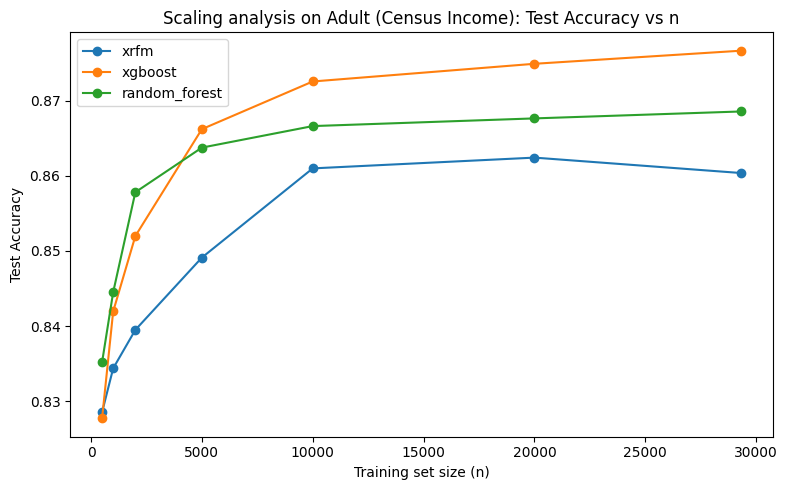

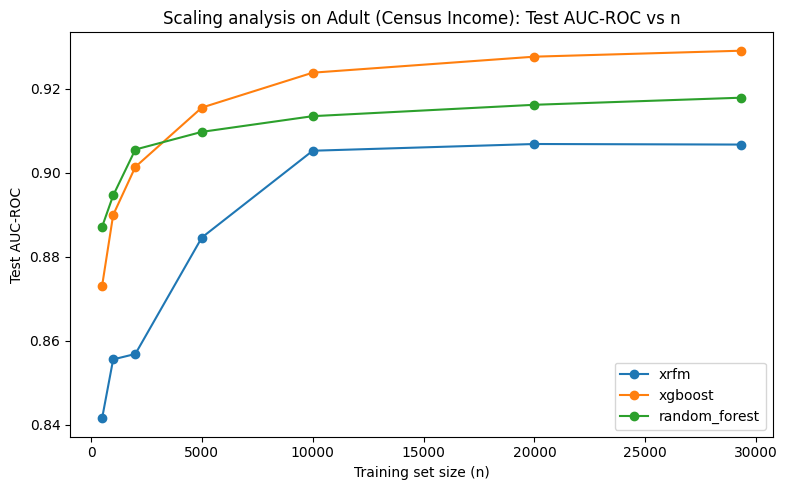

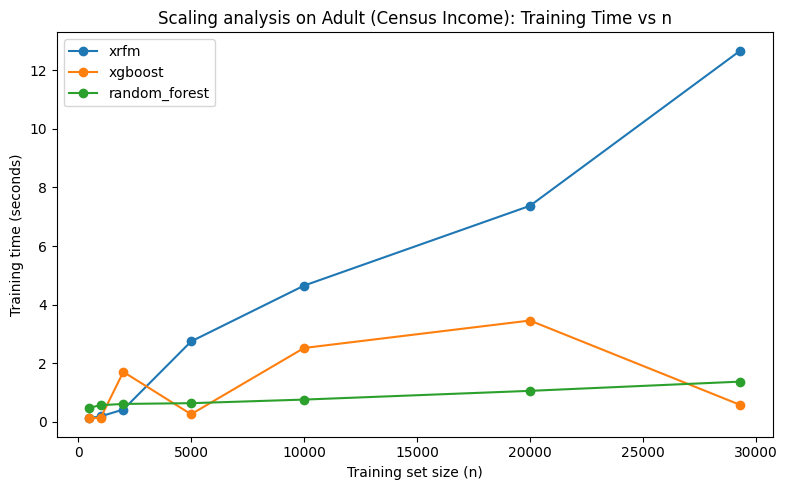

Scaling plots generated.


In [ ]:
# I copy the cleaned scaling results for plotting.
plot_df = SCALING_RESULTS_DISPLAY_DF.copy()

# I plot test Accuracy against training size for each model.
plt.figure(figsize=(8, 5))
for model_name in SCALING_MODELS:
    sub_df = plot_df[plot_df["model_name"] == model_name].sort_values("train_size")
    plt.plot(sub_df["train_size"], sub_df["test_accuracy"], marker="o", label=model_name)
plt.xlabel("Training set size (n)")
plt.ylabel("Test Accuracy")
plt.title(f"Scaling analysis on {SCALING_BASE_META['dataset_name']}: Test Accuracy vs n")
plt.legend()
plt.tight_layout()
plt.show()

# I plot test AUC-ROC against training size for each model.
plt.figure(figsize=(8, 5))
for model_name in SCALING_MODELS:
    sub_df = plot_df[plot_df["model_name"] == model_name].sort_values("train_size")
    plt.plot(sub_df["train_size"], sub_df["test_auc_roc"], marker="o", label=model_name)
plt.xlabel("Training set size (n)")
plt.ylabel("Test AUC-ROC")
plt.title(f"Scaling analysis on {SCALING_BASE_META['dataset_name']}: Test AUC-ROC vs n")
plt.legend()
plt.tight_layout()
plt.show()

# I plot training time against training size for each model.
plt.figure(figsize=(8, 5))
for model_name in SCALING_MODELS:
    sub_df = plot_df[plot_df["model_name"] == model_name].sort_values("train_size")
    plt.plot(sub_df["train_size"], sub_df["best_training_time_sec"], marker="o", label=model_name)
plt.xlabel("Training set size (n)")
plt.ylabel("Training time (seconds)")
plt.title(f"Scaling analysis on {SCALING_BASE_META['dataset_name']}: Training Time vs n")
plt.legend()
plt.tight_layout()
plt.show()

# I confirm that all scaling plots have been generated.
print("Scaling plots generated.")

### Save Scaling Outputs

I save the scaling analysis outputs into a separate folder under the results directory.

The saved files include:

- long-format scaling summary table
- side-by-side pivot table
- cleaned final scaling result table

This produces **3 scaling CSV files** in total. I keep these outputs separate from the main model comparison results so the scaling tables are easier to review, reuse, and reference later.

In [ ]:
# I create a separate folder for scaling outputs.
SCALING_DIR = os.path.join(RESULTS_DIR, "scaling")
os.makedirs(SCALING_DIR, exist_ok=True)

# I define output paths for the scaling summary, pivot table, and final cleaned results.
SCALING_SUMMARY_PATH = os.path.join(SCALING_DIR, "scaling_summary_table.csv")
SCALING_PIVOT_PATH = os.path.join(SCALING_DIR, "scaling_pivot_table.csv")
SCALING_RESULTS_FINAL_PATH = os.path.join(SCALING_DIR, "scaling_results_final.csv")

# I save the long summary table, pivot table, and full scaling result table.
SCALING_SUMMARY_TABLE.to_csv(SCALING_SUMMARY_PATH, index=False)
SCALING_PIVOT_TABLE.to_csv(SCALING_PIVOT_PATH)
SCALING_RESULTS_DISPLAY_DF.to_csv(SCALING_RESULTS_FINAL_PATH, index=False)

# I build a saved-file checklist for the scaling outputs.
save_scaling_df = pd.DataFrame([
    {"file_name": "scaling_summary_table.csv", "path": SCALING_SUMMARY_PATH, "exists": os.path.exists(SCALING_SUMMARY_PATH)},
    {"file_name": "scaling_pivot_table.csv", "path": SCALING_PIVOT_PATH, "exists": os.path.exists(SCALING_PIVOT_PATH)},
    {"file_name": "scaling_results_final.csv", "path": SCALING_RESULTS_FINAL_PATH, "exists": os.path.exists(SCALING_RESULTS_FINAL_PATH)}
])

# I display the checklist so missing files are visible.
display(save_scaling_df)
print("Scaling output save step finished.")

,file_name,path,exists
0,scaling_summary_table.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
1,scaling_pivot_table.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
2,scaling_results_final.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True


Scaling output save step finished.


### Save Key Figures

I save the main scaling and interpretability figures to the project figures folder.

The saved figures include:

- scaling Accuracy curve
- scaling AUC-ROC curve
- scaling training-time curve
- xRFM diagonal feature-importance plot
- cross-method consensus feature plot

This step produces **5 figure files** in total. I keep these visual outputs together so they are easier to review, reuse, and reference later.

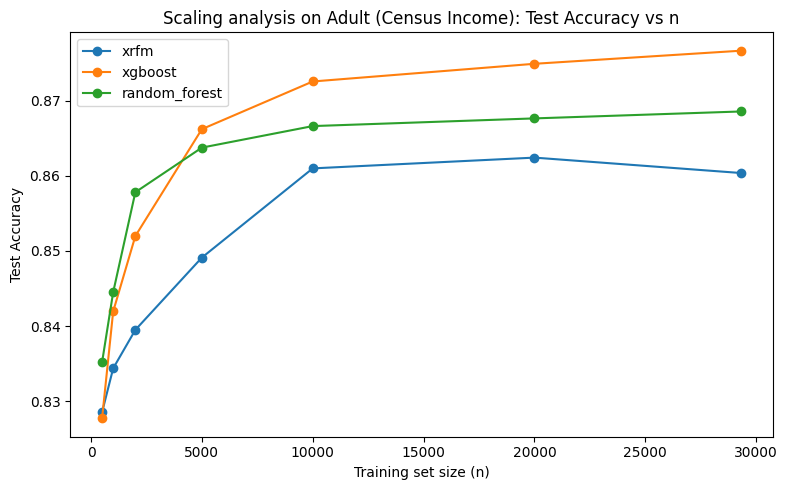

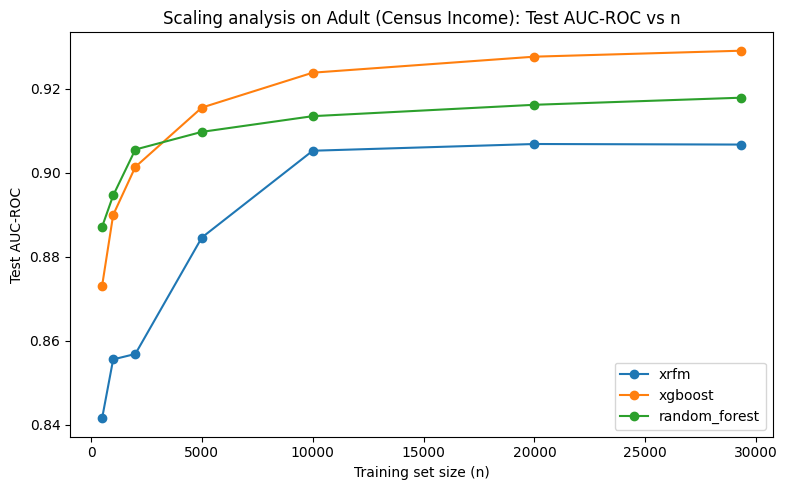

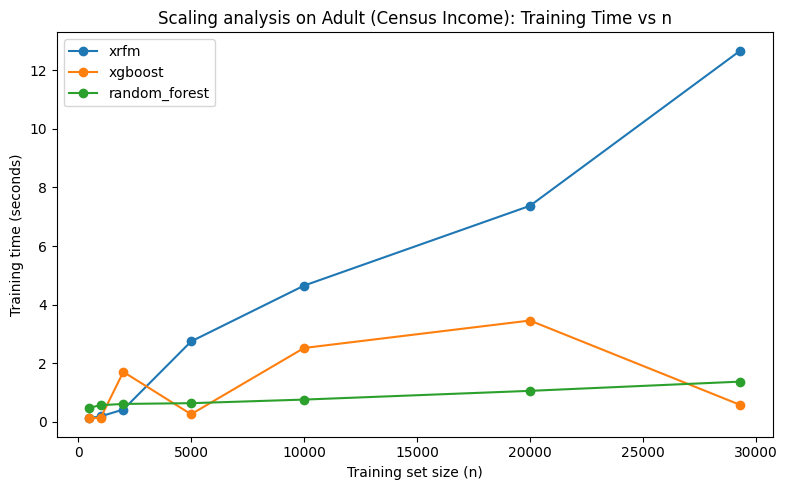

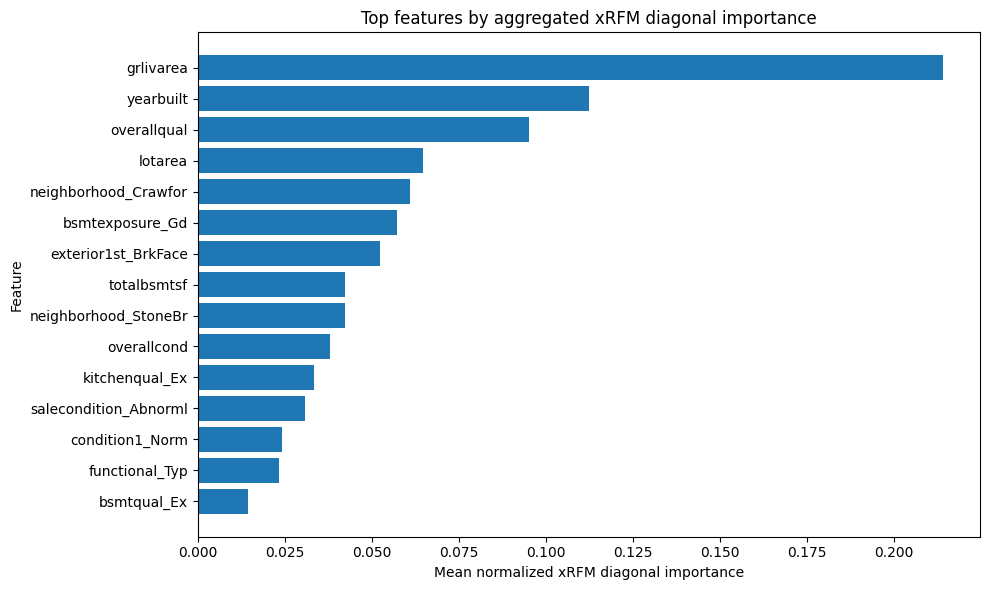

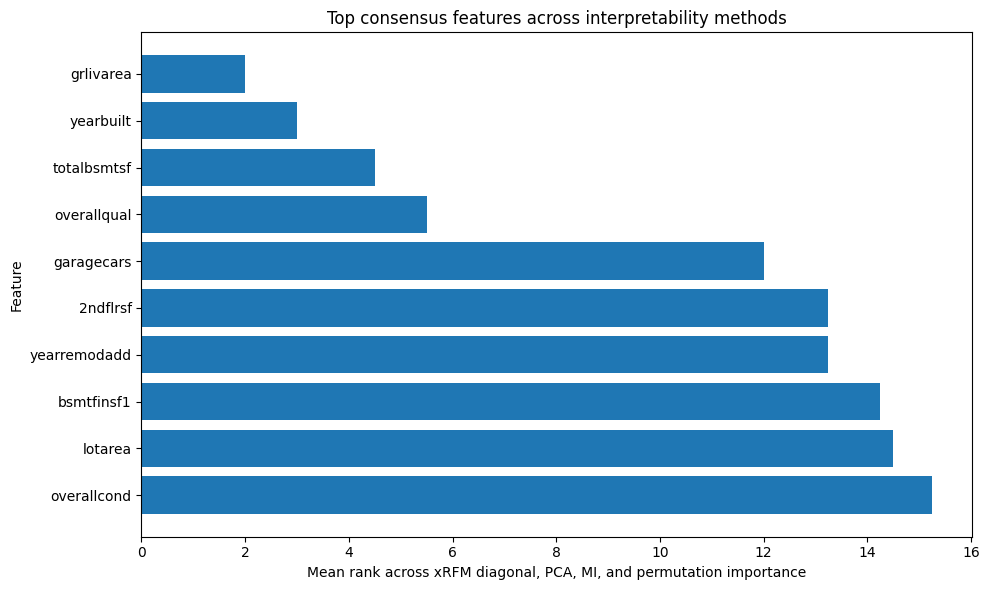

,figure_name,path,exists
0,scaling_accuracy_vs_n.png,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
1,scaling_auc_vs_n.png,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
2,scaling_training_time_vs_n.png,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
3,agop_top15_features.png,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
4,interpretability_consensus_features.png,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True


Key figure save step finished.
Figures folder: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data/figures


In [ ]:
# I save key figures to the project figures folder.
os.makedirs(FIGURES_DIR, exist_ok=True)

figure_save_rows = []

# Figure 1: I save the scaling Accuracy curve.
scaling_accuracy_path = os.path.join(FIGURES_DIR, "scaling_accuracy_vs_n.png")

plt.figure(figsize=(8, 5))
for model_name in SCALING_MODELS:
    sub_df = SCALING_RESULTS_DISPLAY_DF[
        SCALING_RESULTS_DISPLAY_DF["model_name"] == model_name
    ].sort_values("train_size")
    plt.plot(sub_df["train_size"], sub_df["test_accuracy"], marker="o", label=model_name)

plt.xlabel("Training set size (n)")
plt.ylabel("Test Accuracy")
plt.title(f"Scaling analysis on {SCALING_BASE_META['dataset_name']}: Test Accuracy vs n")
plt.legend()
plt.tight_layout()
plt.savefig(scaling_accuracy_path, dpi=300, bbox_inches="tight")
plt.show()

figure_save_rows.append({
    "figure_name": "scaling_accuracy_vs_n.png",
    "path": scaling_accuracy_path,
    "exists": os.path.exists(scaling_accuracy_path)
})


# Figure 2: I save the scaling AUC-ROC curve.
scaling_auc_path = os.path.join(FIGURES_DIR, "scaling_auc_vs_n.png")

plt.figure(figsize=(8, 5))
for model_name in SCALING_MODELS:
    sub_df = SCALING_RESULTS_DISPLAY_DF[
        SCALING_RESULTS_DISPLAY_DF["model_name"] == model_name
    ].sort_values("train_size")
    plt.plot(sub_df["train_size"], sub_df["test_auc_roc"], marker="o", label=model_name)

plt.xlabel("Training set size (n)")
plt.ylabel("Test AUC-ROC")
plt.title(f"Scaling analysis on {SCALING_BASE_META['dataset_name']}: Test AUC-ROC vs n")
plt.legend()
plt.tight_layout()
plt.savefig(scaling_auc_path, dpi=300, bbox_inches="tight")
plt.show()

figure_save_rows.append({
    "figure_name": "scaling_auc_vs_n.png",
    "path": scaling_auc_path,
    "exists": os.path.exists(scaling_auc_path)
})


# Figure 3: I save the scaling training-time curve.
scaling_time_path = os.path.join(FIGURES_DIR, "scaling_training_time_vs_n.png")

plt.figure(figsize=(8, 5))
for model_name in SCALING_MODELS:
    sub_df = SCALING_RESULTS_DISPLAY_DF[
        SCALING_RESULTS_DISPLAY_DF["model_name"] == model_name
    ].sort_values("train_size")
    plt.plot(sub_df["train_size"], sub_df["best_training_time_sec"], marker="o", label=model_name)

plt.xlabel("Training set size (n)")
plt.ylabel("Training time (seconds)")
plt.title(f"Scaling analysis on {SCALING_BASE_META['dataset_name']}: Training Time vs n")
plt.legend()
plt.tight_layout()
plt.savefig(scaling_time_path, dpi=300, bbox_inches="tight")
plt.show()

figure_save_rows.append({
    "figure_name": "scaling_training_time_vs_n.png",
    "path": scaling_time_path,
    "exists": os.path.exists(scaling_time_path)
})


# Figure 4: I save the xRFM diagonal feature-importance figure.
agop_top15_path = os.path.join(FIGURES_DIR, "agop_top15_features.png")

plt.figure(figsize=(10, 6))
plt.barh(
    AGOP_TOP15_DF["feature_name"][::-1],
    AGOP_TOP15_DF["agop_mean_importance"][::-1]
)
plt.xlabel("Mean normalized xRFM diagonal importance")
plt.ylabel("Feature")
plt.title("Top features by aggregated xRFM diagonal importance")
plt.tight_layout()
plt.savefig(agop_top15_path, dpi=300, bbox_inches="tight")
plt.show()

figure_save_rows.append({
    "figure_name": "agop_top15_features.png",
    "path": agop_top15_path,
    "exists": os.path.exists(agop_top15_path)
})


# Figure 5: I save the cross-method consensus feature figure.
consensus_features_path = os.path.join(FIGURES_DIR, "interpretability_consensus_features.png")

plot_df = CONSENSUS_TOP_FEATURES_DF.head(10).sort_values("mean_rank", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature_name"], plot_df["mean_rank"])
plt.xlabel("Mean rank across xRFM diagonal, PCA, MI, and permutation importance")
plt.ylabel("Feature")
plt.title("Top consensus features across interpretability methods")
plt.tight_layout()
plt.savefig(consensus_features_path, dpi=300, bbox_inches="tight")
plt.show()

figure_save_rows.append({
    "figure_name": "interpretability_consensus_features.png",
    "path": consensus_features_path,
    "exists": os.path.exists(consensus_features_path)
})


# I display a saved-file checklist so the exported figures are easy to verify.
figure_save_df = pd.DataFrame(figure_save_rows)

display(figure_save_df)
print("Key figure save step finished.")
print("Figures folder:", FIGURES_DIR)

### Part 8 Summary: Scaling Analysis

In Part 8, I analysed how model behaviour changes as the training size increases.

I used **Adult Income** as the large classification dataset and compared **3 model families**:

- **xRFM**
- **XGBoost**
- **Random Forest**

I created subsampled training bundles from a predefined training-size grid while keeping the same raw validation and test splits. For each subset, I fitted a fresh preprocessor on the sampled training data and applied the fitted transformation to the validation and test splits. This keeps the evaluation data consistent while allowing the processed feature space to reflect each training subset.

For each model, I reused the validation-selected best parameters from the main model comparison instead of tuning again at every training size. This made the scaling analysis more controlled and practical to run.

The scaling outputs quantify model behaviour using:

- **Accuracy** at each training size
- **AUC-ROC** at each training size
- **Training time** at each training size
- **Per-sample inference time** for runtime comparison

I also appended the full-training rows from the main model comparison so the scaling table includes both subsample results and the largest available training size.

I then cleaned the scaling results, built long-format and pivot summary tables, and plotted **3 scaling curves**:

- Accuracy vs training size
- AUC-ROC vs training size
- Training time vs training size

Finally, I saved the scaling tables in a separate results folder and saved the key visual outputs into the figures folder for later review and reference.

## Part 9. Verification Checks

### Check Dataset Coverage

I verify that the final dataset catalog matches the model comparison setup.

This check confirms that the selected datasets cover:

- regression and classification tasks
- large-sample settings
- high-dimensional feature settings
- mixed-feature structures
- the expected final dataset keys

This gives me a final dataset-level sanity check before packaging the project outputs.

In [ ]:
# I copy the dataset catalog so the verification output keeps the dataset details visible.
catalog_check_df = DATASET_CATALOG.copy()

# I list the dataset keys expected in the final model comparison.
expected_dataset_keys = {
    "adult_income",
    "bank_marketing",
    "ames_housing",
    "superconductivity",
    "bike_sharing_hour"
}

# I collect the actual dataset keys from the catalog.
actual_dataset_keys = set(DATASET_CATALOG["dataset_key"].tolist())

# I check the main dataset coverage conditions.
coverage_check_df = pd.DataFrame([
    {"check": "exactly_5_datasets", "value": len(DATASET_CATALOG) == 5},
    {"check": "dataset_keys_match_expected", "value": actual_dataset_keys == expected_dataset_keys},
    {"check": "at_least_2_regression", "value": int((DATASET_CATALOG["task_type"] == "regression").sum()) >= 2},
    {"check": "at_least_2_classification", "value": int((DATASET_CATALOG["task_type"] == "classification").sum()) >= 2},
    {"check": "has_large_n_dataset", "value": bool(DATASET_CATALOG["large_n"].any())},
    {"check": "has_high_d_dataset", "value": bool(DATASET_CATALOG["high_d"].any())},
    {"check": "has_mixed_type_dataset", "value": bool(DATASET_CATALOG["mixed_feature_types"].any())}
])

# I display the catalog and coverage checks.
display(catalog_check_df)
display(coverage_check_df)

# I print the actual keys so any naming mismatch is easy to catch.
print("Actual dataset keys:", sorted(actual_dataset_keys))

,dataset_key,dataset_name,source,task_type,target_name,large_n,high_d,mixed_feature_types,why_selected
0,adult_income,Adult (Census Income),UCI,classification,income_class,True,False,True,"Largest mixed-type classification dataset, use..."
1,bank_marketing,Bank Marketing,UCI,classification,term_deposit_subscription,True,False,True,"Imbalanced binary classification dataset, usef..."
2,ames_housing,Ames Housing,Github,regression,sale_price,False,True,True,Main dataset for interpretability comparison b...
3,superconductivity,Superconductivity,UCI,regression,critical_temperature,True,True,False,"Large, high-dimensional, pure numerical regres..."
4,bike_sharing_hour,Bike Sharing (hour),UCI,regression,bike_count,True,False,True,Medium-large regression dataset with clear sem...


,check,value
0,exactly_5_datasets,True
1,dataset_keys_match_expected,True
2,at_least_2_regression,True
3,at_least_2_classification,True
4,has_large_n_dataset,True
5,has_high_d_dataset,True
6,has_mixed_type_dataset,True


Actual dataset keys: ['adult_income', 'ames_housing', 'bank_marketing', 'bike_sharing_hour', 'superconductivity']


### Check Dataset Loaders

I reload each dataset through the shared loader and check that every loader returns a valid dataset bundle.

The check records:

- dataset name
- task type
- sample count
- feature count
- numerical and categorical feature counts
- loading status

This helps me confirm that the data-loading layer still works consistently across all selected datasets before packaging the project outputs.

In [ ]:
# I store one loader-check record for each dataset.
loader_check_rows = []

# I load every dataset from the catalog through the shared loader.
for dataset_key in DATASET_CATALOG["dataset_key"]:
    try:
        # I load the dataset and read its standard metadata fields.
        bundle = load_dataset(dataset_key)
        loader_check_rows.append({
            "dataset_key": dataset_key,
            "dataset_name": bundle["metadata"]["dataset_name"],
            "task_type": bundle["metadata"]["task_type"],
            "n_samples": bundle["metadata"]["n_samples"],
            "n_features": bundle["metadata"]["n_features"],
            "n_numerical": bundle["metadata"]["n_numerical"],
            "n_categorical": bundle["metadata"]["n_categorical"],
            "status": "success"
        })
    except Exception as e:
        # I keep failed loads visible in the output table.
        loader_check_rows.append({
            "dataset_key": dataset_key,
            "dataset_name": None,
            "task_type": None,
            "n_samples": None,
            "n_features": None,
            "n_numerical": None,
            "n_categorical": None,
            "status": f"failed: {str(e)}"
        })

# I convert the loader checks into a table.
loader_check_df = pd.DataFrame(loader_check_rows)

# I display the loader status table.
display(loader_check_df)

# I print the number of successful loads.
print("Successful loads:", int((loader_check_df["status"] == "success").sum()))

,dataset_key,dataset_name,task_type,n_samples,n_features,n_numerical,n_categorical,status
0,adult_income,Adult (Census Income),classification,48842,14,6,8,success
1,bank_marketing,Bank Marketing,classification,45211,16,7,9,success
2,ames_housing,Ames Housing,regression,1460,79,36,43,success
3,superconductivity,Superconductivity,regression,21263,81,81,0,success
4,bike_sharing_hour,Bike Sharing (hour),regression,17379,13,12,1,success


Successful loads: 5


### Check Preprocessed Data

I verify that all catalog datasets have been preprocessed and stored in the shared preprocessed-data dictionary.

This check records:

- dataset key and name
- task type
- train, validation, and test sizes
- processed feature count
- whether the preprocessed dataset keys match the expected catalog keys

This confirms that the prepared dataset bundles are available for later modelling, evaluation, interpretability analysis, and scaling analysis.

In [ ]:
# I stop early if the preprocessed dataset dictionary is not available.
if "PREPROCESSED_DATA" not in globals():
    raise ValueError("PREPROCESSED_DATA is not available. Please prepare the preprocessing outputs first.")

# I collect the dataset keys that were successfully preprocessed.
preprocessed_keys = set(PREPROCESSED_DATA.keys())

# I build a compact summary of split sizes and processed feature counts.
preprocess_check_rows = []
for dataset_key, bundle in PREPROCESSED_DATA.items():
    meta = bundle["metadata"]
    preprocess_check_rows.append({
        "dataset_key": dataset_key,
        "dataset_name": meta["dataset_name"],
        "task_type": meta["task_type"],
        "n_train": meta["n_train"],
        "n_val": meta["n_val"],
        "n_test": meta["n_test"],
        "processed_n_features": meta["processed_n_features"]
    })

# I sort the preprocessing summary so it is easier to compare with the dataset catalog.
preprocess_check_df = pd.DataFrame(preprocess_check_rows).sort_values("dataset_key").reset_index(drop=True)

# I check whether the preprocessed datasets match the expected dataset list.
preprocess_match_df = pd.DataFrame([
    {"check": "preprocessed_keys_match_catalog", "value": preprocessed_keys == expected_dataset_keys},
    {"check": "num_preprocessed_datasets", "value": len(preprocessed_keys)}
])

# I display the key-match check and preprocessing summary.
display(preprocess_match_df)
display(preprocess_check_df)

# I print the preprocessed keys so missing or extra datasets are easy to notice.
print("Preprocessed dataset keys:", sorted(preprocessed_keys))

,check,value
0,preprocessed_keys_match_catalog,True
1,num_preprocessed_datasets,5


,dataset_key,dataset_name,task_type,n_train,n_val,n_test,processed_n_features
0,adult_income,Adult (Census Income),classification,29305,9768,9769,105
1,ames_housing,Ames Housing,regression,876,292,292,280
2,bank_marketing,Bank Marketing,classification,27126,9042,9043,47
3,bike_sharing_hour,Bike Sharing (hour),regression,10427,3476,3476,743
4,superconductivity,Superconductivity,regression,12757,4253,4253,81


Preprocessed dataset keys: ['adult_income', 'ames_housing', 'bank_marketing', 'bike_sharing_hour', 'superconductivity']


### Check Final Result Sources

I check both the in-memory result table and the saved live CSV result table.

This verification confirms that:

- the final dataset keys are present
- the dataset-model coverage is complete
- earlier draft dataset keys are not mixed into the final outputs
- in-memory and saved CSV result sources are consistent enough for packaging

This helps prevent stale result files from being reused by mistake before I save and package the final project outputs.

In [ ]:
# I collect available result sources from memory and disk.
result_sources = {}

# I add the in-memory result table when it is available.
if "FULL_RESULTS_DF" in globals():
    result_sources["FULL_RESULTS_DF"] = FULL_RESULTS_DF.copy()

# I also add the saved live result CSV when it exists.
if os.path.exists(LIVE_RESULTS_PATH):
    result_sources["LIVE_RESULTS_CSV"] = pd.read_csv(LIVE_RESULTS_PATH)

# I stop early if no result table is available for verification.
if len(result_sources) == 0:
    raise ValueError("No final results were found. Please rerun the model comparison and evaluation sections.")

# I check each result source separately because memory and saved files can get out of sync.
for source_name, df in result_sources.items():
    dataset_keys_in_results = set(df["dataset_key"].astype(str).tolist())

    # I verify the final dataset keys and check that earlier draft keys are absent.
    result_check_df = pd.DataFrame([
        {"check": "dataset_keys_match_expected", "value": dataset_keys_in_results == expected_dataset_keys},
        {"check": "num_result_rows", "value": len(df)},
        {"check": "unique_datasets_in_results", "value": len(dataset_keys_in_results)},
        {"check": "contains_old_concrete_strength", "value": "concrete_strength" in dataset_keys_in_results},
        {"check": "contains_old_energy_efficiency", "value": "energy_efficiency" in dataset_keys_in_results},
        {"check": "contains_old_dry_bean", "value": "dry_bean" in dataset_keys_in_results},
        {"check": "contains_old_isolet", "value": "isolet" in dataset_keys_in_results}
    ])

    # I print a divider so each source check is easy to read.
    print("\n" + "=" * 80)
    print("Checking result source:", source_name)

    # I display the verification checks and included dataset-model rows.
    display(result_check_df)
    display(df[["dataset_key", "dataset_name", "task_type", "model_name"]].sort_values(
        ["dataset_key", "model_name"]
    ).reset_index(drop=True))


Checking result source: FULL_RESULTS_DF


,check,value
0,dataset_keys_match_expected,True
1,num_result_rows,15
2,unique_datasets_in_results,5
3,contains_old_concrete_strength,False
4,contains_old_energy_efficiency,False
5,contains_old_dry_bean,False
6,contains_old_isolet,False


,dataset_key,dataset_name,task_type,model_name
0,adult_income,Adult (Census Income),classification,random_forest
1,adult_income,Adult (Census Income),classification,xgboost
2,adult_income,Adult (Census Income),classification,xrfm
3,ames_housing,Ames Housing,regression,random_forest
4,ames_housing,Ames Housing,regression,xgboost
5,ames_housing,Ames Housing,regression,xrfm
6,bank_marketing,Bank Marketing,classification,random_forest
7,bank_marketing,Bank Marketing,classification,xgboost
8,bank_marketing,Bank Marketing,classification,xrfm
9,bike_sharing_hour,Bike Sharing (hour),regression,random_forest



Checking result source: LIVE_RESULTS_CSV


,check,value
0,dataset_keys_match_expected,True
1,num_result_rows,15
2,unique_datasets_in_results,5
3,contains_old_concrete_strength,False
4,contains_old_energy_efficiency,False
5,contains_old_dry_bean,False
6,contains_old_isolet,False


,dataset_key,dataset_name,task_type,model_name
0,adult_income,Adult (Census Income),classification,random_forest
1,adult_income,Adult (Census Income),classification,xgboost
2,adult_income,Adult (Census Income),classification,xrfm
3,ames_housing,Ames Housing,regression,random_forest
4,ames_housing,Ames Housing,regression,xgboost
5,ames_housing,Ames Housing,regression,xrfm
6,bank_marketing,Bank Marketing,classification,random_forest
7,bank_marketing,Bank Marketing,classification,xgboost
8,bank_marketing,Bank Marketing,classification,xrfm
9,bike_sharing_hour,Bike Sharing (hour),regression,random_forest


### Check Special Analysis Choices

I verify that the special analysis sections use the intended datasets.

This check confirms that:

- interpretability analysis uses **Ames Housing**
- scaling analysis uses **Adult Income**

This keeps the later analysis aligned with the project setup and helps catch accidental configuration changes before final packaging.

In [ ]:
# I record the datasets used for the two special analysis sections.
special_experiment_check_df = pd.DataFrame([
    {"item": "INTERPRETABILITY_DATASET_KEY", "value": INTERPRETABILITY_DATASET_KEY},
    {"item": "SCALING_DATASET_KEY", "value": SCALING_DATASET_KEY}
])

# I display the selected dataset keys for a quick check.
display(special_experiment_check_df)

# I print the expected dataset choices.
print("Interpretability analysis dataset should be: ames_housing")
print("Scaling analysis dataset should be: adult_income")

,item,value
0,INTERPRETABILITY_DATASET_KEY,ames_housing
1,SCALING_DATASET_KEY,adult_income


Interpretability analysis dataset should be: ames_housing
Scaling analysis dataset should be: adult_income


### Part 9 Summary: Verification Checks

In Part 9, I added verification checks to confirm that the notebook still matches the final model comparison setup.

I checked that the dataset catalog contains the **5 selected datasets** and covers:

- regression tasks
- classification tasks
- large-sample data
- high-dimensional features
- mixed feature types

I then rechecked the dataset loaders and preprocessed bundles, including split sizes and processed feature counts. This confirms that the data-loading and preprocessing layers remain aligned with the final dataset catalog.

After that, I verified **2 result sources**:

- the in-memory result table
- the saved live CSV result table

This helps confirm that the final outputs contain only the selected dataset keys and do not include stale keys from earlier draft runs.

Finally, I confirmed the **2 special analysis choices**:

- **Ames Housing** for interpretability analysis
- **Adult Income** for scaling analysis

Together, these checks provide a final consistency layer before packaging the notebook, result tables, and figures.

## Part 10. Residual-Weighted AGOP Extension

### Implement and Validate Residual-Weighted AGOP

I build a small synthetic regression example to compare standard AGOP with a residual-weighted AGOP variant.

In this setup, the two synthetic features play different roles:

- **X0** captures the broader global trend
- **X1** becomes more relevant in a harder local region with larger residuals

I fit a compact xRFM model on the synthetic data, estimate prediction gradients, and construct both AGOP variants from those gradients.

I then compare the two methods from two angles:

- **feature importance shift**: whether residual weighting changes which feature receives more attention
- **proxy error reduction**: whether the feature selected by the residual-weighted variant helps reduce RMSE more effectively on high-residual samples

This gives me a simple extension check before deciding whether the residual-weighted idea is worth keeping as an additional interpretability result.

Tuning split temperature:   0%|          | 0/21 [00:00<?, ?it/s]

Method extension: Residual-weighted AGOP


Tuning split temperature: 100%|██████████| 21/21 [00:00<00:00, 276.49it/s]

Standard AGOP raw diagonals: X0 = 2783.75, X1 = 2707.19
Residual-weighted AGOP raw diagonals: X0 = 2727.91, X1 = 3180.38

Standard AGOP top feature: X0 (Global Trend)
Residual-weighted AGOP top feature: X1 (Local Feature)

--------------------------------------------------
Proxy performance check on high-residual samples
Subset: 400 high-residual samples. Initial RMSE: 4.1186
Split via X0 (Global Trend) (standard) -> RMSE reduction: 0.0135
Split via X1 (Local Feature) (residual-weighted) -> RMSE reduction: 0.0279

Residual-weighted AGOP gives lower RMSE in this check by selecting X1 (Local Feature).


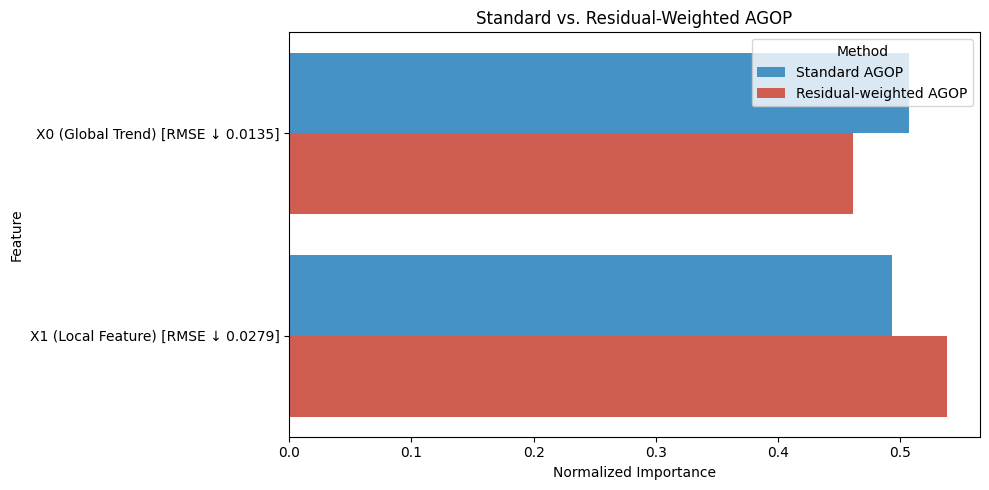

In [ ]:
# I import the libraries used for the method extension, plotting, and model fitting.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from contextlib import redirect_stdout
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from xrfm import xRFM

# I suppress warnings so the output stays focused on the AGOP comparison.
warnings.filterwarnings("ignore")

print("=" * 50)
print("Method extension: Residual-weighted AGOP")


# I create a reproducible synthetic regression dataset with two features.
np.random.seed(42)
N_samples = 2000
X_syn = np.random.uniform(-1, 1, size=(N_samples, 2))

# I design the target so X0 drives the global pattern, while X1 matters more in a harder local region.
base_noise = np.random.normal(0, 1.0, N_samples)
y_syn = 4.0 * X_syn[:, 0] + 10.0 * X_syn[:, 1] * (X_syn[:, 0] > 0.6) + (base_noise * 5.0) * (X_syn[:, 0] > 0.6)

# I keep the synthetic features and target in floating-point format for xRFM.
X_train = X_syn.astype(np.float64)
y_train = y_syn.astype(np.float64)

# I define a compact xRFM model for this synthetic regression check.
xrfm_params = {
    "max_leaf_size": 1000, "n_trees": 1, "n_tree_iters": 0, "random_state": 42,
    "classification_mode": False,
    "rfm_params": {
        "model": {"kernel": "l2", "bandwidth": 1.0, "exponent": 1.0, "diag": True},
        "fit": {"reg": 0.1, "iters": 1, "verbose": False}
    }
}

# I fit xRFM while suppressing its internal training messages.
model = xRFM(**xrfm_params)
with open(os.devnull, "w") as f, redirect_stdout(f):
    model.fit(X_train, y_train, X_train, y_train)

# I calculate predictions and residuals on the same synthetic sample.
with open(os.devnull, "w") as f, redirect_stdout(f):
    y_pred = model.predict(X_train)

if y_pred.ndim > 1:
    y_pred = y_pred[:, 0]

residuals = y_train - y_pred

# I approximate prediction gradients with central finite differences.
eps = 1e-3
gradients = np.zeros_like(X_train)

# I perturb one feature at a time and estimate the resulting prediction change.
for j in range(2):
    X_plus, X_minus = X_train.copy(), X_train.copy()
    X_plus[:, j] += eps
    X_minus[:, j] -= eps

    with open(os.devnull, "w") as f, redirect_stdout(f):
        pred_plus = model.predict(X_plus)
        pred_minus = model.predict(X_minus)

    if pred_plus.ndim > 1:
        pred_plus, pred_minus = pred_plus[:, 0], pred_minus[:, 0]

    gradients[:, j] = (pred_plus - pred_minus) / (2 * eps)

# I prepare both the standard AGOP matrix and the residual-weighted variant.
AGOP_std = np.zeros((2, 2))
AGOP_res = np.zeros((2, 2))
weights = residuals ** 2
sum_weights = np.sum(weights)

# I accumulate one gradient outer product per sample for each AGOP variant.
for i in range(N_samples):
    g = gradients[i].reshape(-1, 1)
    AGOP_std += g @ g.T
    AGOP_res += weights[i] * (g @ g.T)

# I normalise the two AGOP matrices so they stay comparable.
AGOP_std /= N_samples
AGOP_res /= sum_weights

# I use the diagonal entries as coordinate-wise feature-importance scores.
diag_std = np.diag(AGOP_std)
diag_res = np.diag(AGOP_res)

# I normalise each diagonal vector so the feature scores sum to one within each method.
importance_std = diag_std / np.sum(diag_std)
importance_res = diag_res / np.sum(diag_res)

# I name the two features by their roles in this synthetic example.
features = ["X0 (Global Trend)", "X1 (Local Feature)"]
top_std_feat = features[np.argmax(importance_std)]
top_res_feat = features[np.argmax(importance_res)]

# I print the raw diagonal scores before normalisation.
print(f"Standard AGOP raw diagonals: X0 = {diag_std[0]:.2f}, X1 = {diag_std[1]:.2f}")
print(f"Residual-weighted AGOP raw diagonals: X0 = {diag_res[0]:.2f}, X1 = {diag_res[1]:.2f}")

# I print the top-ranked feature under each AGOP method.
print(f"\nStandard AGOP top feature: {top_std_feat}")
print(f"Residual-weighted AGOP top feature: {top_res_feat}")

print("\n" + "-" * 50)
print("Proxy performance check on high-residual samples")

# I focus on the samples with the largest absolute residuals.
threshold = np.percentile(np.abs(residuals), 80)
hard_idx = np.abs(residuals) >= threshold
X_hard, target_residuals = X_train[hard_idx], residuals[hard_idx]
initial_rmse = np.sqrt(np.mean(target_residuals ** 2))

print(f"Subset: {np.sum(hard_idx)} high-residual samples. Initial RMSE: {initial_rmse:.4f}")

# I test a one-level tree split using the top feature selected by standard AGOP.
tree_std = DecisionTreeRegressor(max_depth=1, random_state=42)
tree_std.fit(X_hard[:, np.argmax(importance_std)].reshape(-1, 1), target_residuals)
rmse_std = root_mean_squared_error(
    target_residuals,
    tree_std.predict(X_hard[:, np.argmax(importance_std)].reshape(-1, 1))
)

# I test a one-level tree split using the top feature selected by residual-weighted AGOP.
tree_res = DecisionTreeRegressor(max_depth=1, random_state=42)
tree_res.fit(X_hard[:, np.argmax(importance_res)].reshape(-1, 1), target_residuals)
rmse_res = root_mean_squared_error(
    target_residuals,
    tree_res.predict(X_hard[:, np.argmax(importance_res)].reshape(-1, 1))
)

# I compare the RMSE reduction achieved on the high-residual subset.
print(f"Split via {top_std_feat} (standard) -> RMSE reduction: {initial_rmse - rmse_std:.4f}")
print(f"Split via {top_res_feat} (residual-weighted) -> RMSE reduction: {initial_rmse - rmse_res:.4f}")

# I print a short note when the residual-weighted choice gives the larger RMSE reduction.
if rmse_res < rmse_std:
    print(f"\nResidual-weighted AGOP gives lower RMSE in this check by selecting {top_res_feat}.")

# I attach the observed RMSE reduction values to the feature labels for the final plot.
features_with_rmse = [
    f"X0 (Global Trend) [RMSE ↓ {initial_rmse - rmse_std:.4f}]",
    f"X1 (Local Feature) [RMSE ↓ {initial_rmse - rmse_res:.4f}]"
]

# I reshape the two importance vectors into long format for grouped plotting.
df_compare = pd.DataFrame({
    "Feature": features_with_rmse,
    "Standard AGOP": importance_std,
    "Residual-weighted AGOP": importance_res
})
df_melted = df_compare.melt(
    id_vars="Feature",
    var_name="Method",
    value_name="Normalized Importance"
)

# I plot the standard and residual-weighted AGOP importance scores side by side.
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_melted,
    x="Normalized Importance",
    y="Feature",
    hue="Method",
    palette=["#3196d9", "#e44c3b"]
)
plt.title("Standard vs. Residual-Weighted AGOP")
plt.tight_layout()
plt.show()

### Save Residual-Weighted AGOP Outputs

I save the residual-weighted AGOP extension outputs with the rest of the project results.

The saved files include:

- feature-importance comparison table
- RMSE validation summary
- visual comparison between standard AGOP and residual-weighted AGOP

This produces **3 method-extension outputs** in total: **2 CSV files** and **1 figure file**. I keep these outputs separate from the main model comparison results so the extension check is easy to review and reference later.

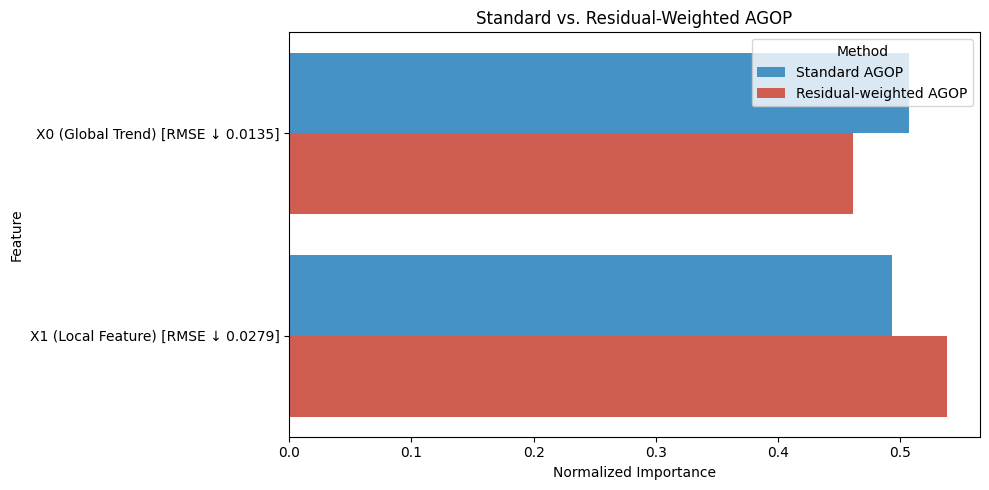

,file_name,path,exists
0,residual_weighted_agop.png,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
1,residual_weighted_agop_comparison.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True
2,residual_weighted_agop_summary.csv,/content/drive/MyDrive/Adaptive_Kernel_Feature...,True


Residual-weighted AGOP output save step finished.


In [ ]:
# I create separate folders for method extension outputs and figures.
EXTENSION_DIR = os.path.join(RESULTS_DIR, "residual_weighted_agop_extension")
os.makedirs(EXTENSION_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# I define output paths for the residual-weighted AGOP figure and tables.
EXTENSION_FIGURE_PATH = os.path.join(FIGURES_DIR, "residual_weighted_agop.png")
EXTENSION_COMPARE_PATH = os.path.join(EXTENSION_DIR, "residual_weighted_agop_comparison.csv")
EXTENSION_SUMMARY_PATH = os.path.join(EXTENSION_DIR, "residual_weighted_agop_summary.csv")

# I check that the method extension variables exist before saving outputs.
required_extension_objects = [
    "df_compare",
    "df_melted",
    "importance_std",
    "importance_res",
    "top_std_feat",
    "top_res_feat",
    "initial_rmse",
    "rmse_std",
    "rmse_res"
]

missing_extension_objects = [name for name in required_extension_objects if name not in globals()]

if len(missing_extension_objects) > 0:
    raise ValueError(
        f"Missing method extension objects: {missing_extension_objects}. "
        "Please run the residual-weighted AGOP cell first."
    )

# I save the feature-importance comparison table used in the plot.
df_compare.to_csv(EXTENSION_COMPARE_PATH, index=False)

# I save a compact RMSE validation summary.
extension_summary_df = pd.DataFrame([
    {"item": "standard_agop_top_feature", "value": top_std_feat},
    {"item": "residual_weighted_agop_top_feature", "value": top_res_feat},
    {"item": "initial_rmse_on_hard_samples", "value": initial_rmse},
    {"item": "rmse_after_standard_agop_split", "value": rmse_std},
    {"item": "rmse_after_residual_weighted_agop_split", "value": rmse_res},
    {"item": "standard_agop_rmse_reduction", "value": initial_rmse - rmse_std},
    {"item": "residual_weighted_agop_rmse_reduction", "value": initial_rmse - rmse_res}
])

extension_summary_df.to_csv(EXTENSION_SUMMARY_PATH, index=False)

# I recreate and save the residual-weighted AGOP comparison figure.
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_melted,
    x="Normalized Importance",
    y="Feature",
    hue="Method",
    palette=["#3196d9", "#e44c3b"]
)
plt.title("Standard vs. Residual-Weighted AGOP")
plt.tight_layout()
plt.savefig(EXTENSION_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

# I build a saved-file checklist for the method extension outputs.
extension_save_df = pd.DataFrame([
    {"file_name": "residual_weighted_agop.png", "path": EXTENSION_FIGURE_PATH, "exists": os.path.exists(EXTENSION_FIGURE_PATH)},
    {"file_name": "residual_weighted_agop_comparison.csv", "path": EXTENSION_COMPARE_PATH, "exists": os.path.exists(EXTENSION_COMPARE_PATH)},
    {"file_name": "residual_weighted_agop_summary.csv", "path": EXTENSION_SUMMARY_PATH, "exists": os.path.exists(EXTENSION_SUMMARY_PATH)}
])

# I display the checklist so missing extension outputs are easy to catch.
display(extension_save_df)
print("Residual-weighted AGOP output save step finished.")

### Part 10 Summary: Residual-Weighted AGOP Extension

In Part 10, I implemented a residual-weighted AGOP method extension.

I built a synthetic regression dataset with **2 feature roles**:

- `X0` captures the main global trend
- `X1` becomes important mainly in a local high-error region

This setup lets me check whether residual weighting can shift attention toward features that explain the model’s remaining errors.

I trained a compact xRFM model, estimated prediction gradients with central finite differences, and computed **2 AGOP variants**:

- **Standard AGOP**: treats all samples equally
- **Residual-weighted AGOP**: gives more influence to high-error samples

For a practical validation check, I focused on the **top 20% high-residual samples** and fitted a simple one-split regression tree using the top feature selected by each AGOP method. I then compared the RMSE reduction from each split and visualised the standard and residual-weighted feature-importance scores side by side.

Finally, I saved the method-extension outputs, including the feature-importance comparison table, RMSE summary, and residual-weighted AGOP figure. This keeps the extension result available as a separate exploratory check rather than mixing it into the main model comparison.

## Part 11. Project Packaging

### Package Project Files

I package the current project folder into a ZIP archive.

The archive keeps the main project files together, including:

- notebook files
- processed data
- saved result tables
- figures
- model settings
- interpretability outputs
- scaling outputs
- method-extension outputs

This step makes the project folder easier to export, review, and store as a complete project snapshot.

In [ ]:
# I import the tools needed to create and download a ZIP archive from Colab.
import shutil
from google.colab import files
import os

# I define the ZIP output path under /content for easier export.
zip_base = "/content/adaptive_kernel_feature_learning_tabular_data"
zip_path = f"{zip_base}.zip"

# I remove any older ZIP with the same name before creating a fresh archive.
if os.path.exists(zip_path):
    os.remove(zip_path)

# I compress the current project folder, including results, figures, and saved outputs.
shutil.make_archive(zip_base, "zip", project_root)

# I print the archive path and source folder for a final check.
print("ZIP file created.")
print("ZIP path:", zip_path)
print("Source folder:", project_root)

# I download the ZIP archive from the Colab runtime.
files.download(zip_path)

ZIP file created.
ZIP path: /content/adaptive_kernel_feature_learning_tabular_data.zip
Source folder: /content/drive/MyDrive/Adaptive_Kernel_Feature_Learning_for_Tabular_Data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Part 11 Summary: Project Packaging

In Part 11, I packaged the current project folder into a ZIP archive.

This packaging step collects the main project files into one exportable snapshot, including:

- notebook files
- processed data files
- saved result tables
- figures
- model settings
- interpretability outputs
- scaling outputs
- residual-weighted AGOP extension outputs

I created the archive from the project root folder, removed any older ZIP with the same output name, and generated a fresh ZIP file for download from the Colab runtime.

This final step does not change the modelling results. It only packages the current saved project state so the notebook, outputs, and generated artefacts can be stored, transferred, or reviewed together.

## Overall Summary

> **Project focus:** Adaptive kernel feature learning for tabular data  
> **Main goal:** compare prediction quality, runtime cost, interpretability behaviour, and scaling patterns across multiple tabular datasets.

---

In this notebook, I built a complete tabular machine learning workflow around **xRFM** and compared it with strong tree-based baselines.

The project covers four main evaluation angles:

- **Prediction performance**
- **Runtime efficiency**
- **Feature interpretability**
- **Scaling behaviour**

I also implemented a small **residual-weighted AGOP method extension** to explore how AGOP-style feature importance can be adjusted toward high-error regions.

---

### 1. Project Setup and Data Preparation

I first prepared the notebook environment, mounted Google Drive, installed the required packages, fixed the random seed, and created a clear folder structure for:

- `data`
- `results`
- `figures`
- `saved_models`

I also recorded key environment information and package checks so the runtime setup can be inspected later.

#### Selected Datasets

I used **5 tabular datasets** in the main model comparison:

| Dataset | Task Type | Main Role |
|---|---:|---|
| **Adult Income** | Classification | Large-sample mixed-feature dataset |
| **Bank Marketing** | Classification | Binary classification dataset with class imbalance |
| **Ames Housing** | Regression | High-dimensional mixed-feature dataset for interpretability |
| **Superconductivity** | Regression | Large high-dimensional numerical regression dataset |
| **Bike Sharing** | Regression | Medium-large mixed-feature regression dataset |

Together, these datasets provide:

- **2 classification datasets**
- **3 regression datasets**
- large-sample settings
- high-dimensional feature settings
- mixed numerical-categorical feature types

#### Preprocessing Workflow

For each dataset, I built a consistent loading and preprocessing pipeline:

- numerical features: median imputation and standardisation
- categorical features: most-frequent imputation and one-hot encoding
- classification targets: label encoding
- data split: train, validation, and test sets

I fitted preprocessing only on the training set, then applied the same fitted transformations to the validation and test sets. This keeps the workflow consistent and helps avoid data leakage.

---

### 2. Model Training and Evaluation

I trained and tuned **3 model families**:

- **xRFM**
- **XGBoost**
- **Random Forest**

The main comparison covers **5 datasets × 3 model families**, producing **15 selected-model result rows**.

The model-selection rule was:

> **Validation set → model selection**  
> **Test set → final reporting only**

For regression tasks, I reported:

- **RMSE**
- **Training time**
- **Inference time per sample**

For classification tasks, I reported:

- **Accuracy**
- **AUC-ROC**
- **Training time**
- **Inference time per sample**

After training, I cleaned the raw outputs into structured evaluation tables and saved:

- full model comparison results
- regression result tables
- classification result tables
- selected model parameters
- dataset-level best-model summaries
- model win-count summaries
- main performance heatmap

These outputs make the project results easier to inspect and reuse later.

---

### 3. Interpretability Analysis

I used **Ames Housing** for the interpretability analysis because it has rich and meaningful tabular features.

The workflow was:

1. Retrieve the validation-selected xRFM model.
2. Inspect the fitted model for usable leaf-level feature matrices.
3. Use fallback M diagonal vectors when direct AGOP matrices are not available.
4. Convert diagonal values into feature-level activity scores.
5. Keep local leaf-level rankings for closer inspection.
6. Average scores across detected leaves to form a global xRFM diagonal feature-activity ranking.

I compared the xRFM diagonal ranking with **3 baseline importance methods**:

- **PCA loading-based importance**
- **Mutual information**
- **Permutation importance**

Together, this gives **4 interpretability views** for comparison.

I measured cross-method agreement using:

- feature ranks
- top-k overlap counts
- consensus feature summaries
- high-disagreement feature summaries

This helped me examine where the xRFM diagonal ranking agrees with standard importance tools and where it captures more model-specific feature patterns.

---

### 4. Scaling Analysis

I used **Adult Income** as the large classification dataset for the scaling analysis.

The scaling setup used:

- the same raw validation split
- the same raw test split
- a predefined training-size grid
- the same **3 model families**
- fixed validation-selected parameters from the main model comparison

For each training subset, I fitted a fresh preprocessor on the sampled training data and applied the fitted transformation to the validation and test splits. This keeps the evaluation data consistent while allowing the processed feature space to reflect each sampled training subset.

I measured:

- **Test Accuracy vs training size**
- **Test AUC-ROC vs training size**
- **Training time vs training size**
- **Inference time per sample**

I then saved:

- scaling summary table
- scaling pivot table
- final scaling result table
- scaling figures

These outputs show how model quality and runtime cost change as more training data becomes available.

---

### 5. Residual-Weighted AGOP Method Extension

I implemented a **residual-weighted AGOP method extension** on synthetic regression data.

The synthetic setup used **2 feature roles**:

- `X0` captures the main global trend
- `X1` becomes important mainly in a local high-error region

The extension workflow was:

1. Train a compact xRFM model.
2. Estimate prediction gradients with central finite differences.
3. Compute **standard AGOP**.
4. Compute **residual-weighted AGOP**.
5. Compare diagonal feature-importance scores.
6. Validate the selected feature with a one-split regression tree on high-residual samples.

The validation check focused on the **top 20% high-residual samples** and compared the **RMSE reduction** from the top feature selected by each AGOP variant.

This gave me a small exploratory check of whether residual weighting can shift feature importance toward regions where the model still makes larger errors.

---

### 6. Verification and Packaging

I added verification checks to make sure the final notebook still matches the intended project setup.

The checks covered:

- dataset catalog
- dataset loaders
- preprocessed bundles
- in-memory result table
- saved live CSV result table
- earlier draft dataset key removal
- interpretability dataset choice
- scaling dataset choice

The two special analysis choices were:

| Analysis | Dataset |
|---|---|
| Interpretability analysis | **Ames Housing** |
| Scaling analysis | **Adult Income** |

At the end, I saved the key outputs and packaged the project folder into a ZIP archive so the notebook, data files, result tables, figures, selected model parameters, interpretability outputs, scaling outputs, and method-extension outputs can be kept together.

---

### Key Takeaway

This notebook provides a structured workflow for evaluating adaptive kernel feature learning on tabular data.

The main project outputs include:

- **5-dataset tabular model comparison**
- **3 model families**
- **15 selected-model result rows**
- consistent preprocessing and evaluation pipeline
- validation-based model selection
- test-only final reporting
- runtime comparison across model families
- xRFM interpretability analysis
- scaling analysis on a large classification dataset
- residual-weighted AGOP method extension

Overall, I compared prediction performance, runtime cost, interpretability behaviour, and scaling patterns across multiple tabular settings. I also organised the main outputs into reusable tables, figures, and saved files so the workflow and results are easier to inspect later.

---

### Limitations and Future Work

The current workflow has several limitations:

- compact hyperparameter search spaces
- Colab runtime constraints
- single-run scaling results
- fixed parameters reused across scaling subsets
- synthetic-only validation for the residual-weighted AGOP extension

With more time and compute, I could:

- expand the hyperparameter search
- repeat the scaling analysis with multiple random subsamples
- test residual-weighted AGOP on real datasets
- explore AGOP eigenvectors in more detail
- compare xRFM with more tabular methods, such as **LightGBM** or **TabPFN**